# Projeto Aprendizagem Automática - Rate Beer
#### Pedro Azevedo 47094

LEIM - 21/01/2024

In [23]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import re #expressoes regulares
from sklearn.feature_extraction.text import TfidfVectorizer
from tabulate import tabulate
import pandas as pd

### 1- Dados: Análise dos dados fornecidos

Foram fornecidos 2 ficheiros pickel, um com 75k dados de treino e outro com 25k dados de teste ambos com criticas de cerveja.
Nestes ficheiros, cada um contêm um dicionário, onde cada dicionário tem como valores outros dicionários com informação referente a 1 critica de uma dada cerveja.

Vamos então analisar os dados fornecidos, começando por carregar os dados de treino e teste dos ficheiros pickel.

In [24]:
import random

beerDictTrain = pickle.load(open("ficheirosPickel/rateBeer75Ktrain.p", "rb"))
beerDictTest = pickle.load(open("ficheirosPickel/rateBeer25Ktest.p", "rb"))
dictKeys = list(beerDictTrain.keys())
print("Primeiras 5 chaves das criticas:\n\n", dictKeys[:5])
print("\n----------\n")
#ir busca um dicionario de uma critica aleatorio
key = random.choice(dictKeys)
print("Primeiro value do dicionário, ou seja, a primeira critica:\n\n", beerDictTrain[key])
criticasKeys = list(beerDictTrain[key].keys())
print("Chaves das criticas:\n\n", criticasKeys)

Primeiras 5 chaves das criticas:

 ['000000', '000001', '000002', '000003', '000004']

----------

Primeiro value do dicionário, ou seja, a primeira critica:

 {'name': 'Palm Speciale', 'style': 'Belgian Ale', 'who': 'Kristall-Knig', 'feel': '3/5', 'look': '3/5', 'smell': '2/5', 'taste': '2/5', 'overall': '4/10', 'review': 'Das Palm Speciale ist optisch ok. Das starke Brabanter Pferd auf dem Etikett bezieht sich wohl auf das Aroma. Intensiv slich-fruchtig, an einen Blumenstrau erinnernd, mit herben Unterton. Angenehm prickelnd. Im Abgang ist es berraschend suerlich. \tEin Bier mit leichten Schwchen. Dafr sehr direkt. Knnte ich wieder kaufen.Test vom 16.3.2007, Gebinde: Glasflasche'}
Chaves das criticas:

 ['name', 'style', 'who', 'feel', 'look', 'smell', 'taste', 'overall', 'review']


Como se pode ver ver, os ficheiros pickel fonecidos contêm um dicionário, onde as Keys são como ids de cada critica e os values são um outro dicionário com informação referente a essa critica. Neste dicionário de cada critica tem as seguintes keys:

- 'name': nome da cerveja;
- 'style': tipo da cerveja;
- 'who': nome do critico;
- 'feel': pomtuação "tátil" (sobre a sensação) de 1 a 5;
- 'look': pontuação "visual"  de 1 a 5;
- 'smell': pontuação "olfativa" de 1 a 5;
- 'taste': pontuação "gustativa" de 1 a 5;
- 'overall': pontuação geral de 1 a 10;
- 'review': texto da critica.


Agora abaixo analisa-se os dados estatisticamente.

NOTA: os dados estão em Strings, por isso tem que se converter para inteiros ou floats para poder fazer as análises estatísticas.

In [25]:
dict_keys_stats = {
    'feel': [int(beerDictTrain[idx]['feel'][0]) for idx in beerDictTrain],
    'look': [int(beerDictTrain[idx]['look'][0]) for idx in beerDictTrain],
    'smell': [int(beerDictTrain[idx]['smell'][0]) for idx in beerDictTrain],
    'taste': [int(beerDictTrain[idx]['taste'][0]) for idx in beerDictTrain],
    'overall': [int(beerDictTrain[idx]['overall'][0]) for idx in beerDictTrain]
}

Docs = [beerDictTrain[idx]['review'] for idx in beerDictTrain]

for key in dict_keys_stats:
    print("Média de", key, ":", np.mean(dict_keys_stats[key]))
    print("Desvio padrão de", key, ":", np.std(dict_keys_stats[key]))
    print("Mediana de", key, ":", np.median(dict_keys_stats[key]))
    print("Moda de", key, ":", np.argmax(np.bincount(dict_keys_stats[key])))
    print("----------")

Média de feel : 3.4794
Desvio padrão de feel : 0.7429326842543229
Mediana de feel : 3.0
Moda de feel : 4
----------
Média de look : 3.63488
Desvio padrão de look : 0.7049685942886629
Mediana de look : 4.0
Moda de look : 4
----------
Média de smell : 3.0184
Desvio padrão de smell : 1.0983903859739488
Mediana de smell : 3.0
Moda de smell : 3
----------
Média de taste : 3.03116
Desvio padrão de taste : 1.1039334465446728
Mediana de taste : 3.0
Moda de taste : 3
----------
Média de overall : 5.51812
Desvio padrão de overall : 1.9123227583927003
Mediana de overall : 6.0
Moda de overall : 6
----------


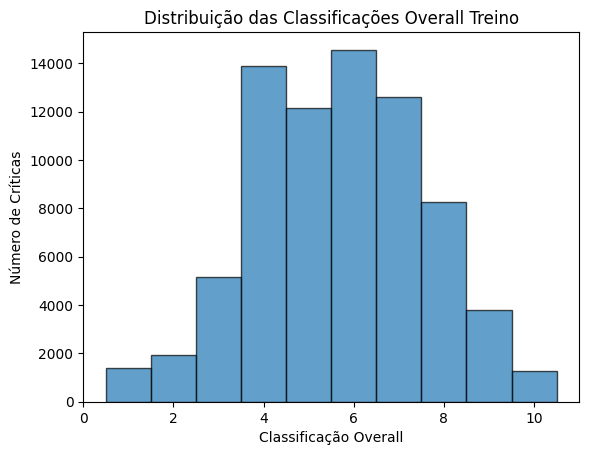

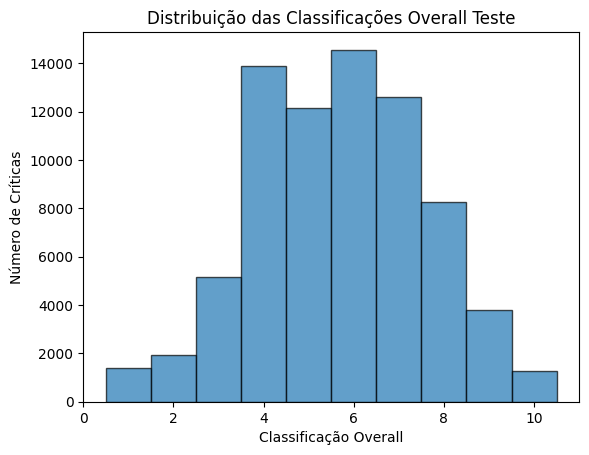

In [26]:
overall_ratings = [int(beerDictTrain[key]['overall'].split('/')[0]) for key in beerDictTrain]
overall_ratings.sort()
plt.hist(overall_ratings, bins=np.arange(1, 12) - 0.5, edgecolor='black', alpha=0.7)
plt.xlabel('Classificação Overall')
plt.ylabel('Número de Críticas')
plt.title('Distribuição das Classificações Overall Treino')
plt.show()

overall_ratings =[int(beerDictTrain[key]['overall'].split('/')[0] )for key in beerDictTrain]
overall_ratings.sort()
plt.hist(overall_ratings, bins=np.arange(1, 12) - 0.5, edgecolor='black', alpha=0.7)
plt.xlabel('Classificação Overall')
plt.ylabel('Número de Críticas')
plt.title('Distribuição das Classificações Overall Teste')
plt.show()




### 2- Limpeza dos Documentos e Construção do Vocabulário.

Cada review, ou seja cada documento, consiste num conjuto de palavras, onde é possivel aplicar técnicas de aprendizagem automática, e para tal, é nececssário representar cada documento por um vetor numérico. Uma abordagem é o Bag of Words, onde se descarta a ordem, a estrutura e a ordem do texto, e se dá ênfase no número de ocurrencias de cada palavra em cada documento do conjunto de dados (corpus), ficando com uma matriz "documento-termo", Nxd, onde N é o número de documentos no corpus, e d é o número de palavras do vocabulário. Este modelo, é uma técnica não supervisionada eficaz de representar texto numericamente, permitindo assim aplicar os métodos de aprendizagem automática. É não supervisionada pois não é necessário aplicar rótulos aos dados, pois no seu processo verificasse a contagem de ocorrencias de cada palavra em cada documento, independnetemente da sua categoria. Esta matriz será esparsa sendo que cada documento contem apenas algumas palavras do vocabulário, os valores das palavras que não estão presentes vai ser 0.
  
Para utilizar este modelo, segue-se os seguintes passos:
 - Tokenization, onde se divide cada documento em palavras, designando-os de tokens;
  - Construção do vocabulário, este constituido por todas, ou por um sub-conjunto de palavras presentes no corpus;
-  Coodificação, onde se conta o número de aparencias de cada token do vocabulário em cada documento, seguindo para a representação de cada documento por um vetor de d dimensões, por cada palavra no vocabulário, com valores proporcionais  ao número de ocurrências dessa palvara no documento. Finalizando com a construção da matriz, documento-termo. 

É de ter em conta que cada documento é representado por um vetor com dimensão igual ao vocabulário, mesmo que o documento não contenha todas as palavras presentes no vocabulario, estas vão ter o valor de 0, o que pode resultar em milhares de palavras, sendo apropriado realizar um pré-processamento nos documentos para reduzir a dimensão do vocabulário. Vamos então utilizar as seguintes técnicas de limpeza de cada documento:

- Eliminar tags HTML, utilizando a função *replace()*, onde vai substituir a tag por um espaço em branco;
- Eliminar todos os caracteres que não sejam alfabéticos, utilizando a função *re.sub()*, onde, utilizando expressões regulares, vai substituir todos os caracteres que não sejam alfabéticos por um espaço em branco;

A função *limpar_caracteres_tags()* vai aplicar estas duas técnicas de limpeza a cada documento.


In [27]:
def limpar_caracteres_tags(documentos):
    documentos = [doc.replace('<br />', ' ') for doc in documentos]
    documentos = [re.sub(r'[^a-zA-Z\u00C0-\u00FF]+' , ' ', doc) for doc in documentos]
    return documentos

Ao longo dos documentos, podemos encontrar palavras que são parecidas e que têm o mesmo significado, mas que são escritas de maneira diferente, por exemplo, "beer" e "beers", ou "drink" e "drinking". Para evitar que estas palavras sejam consideradas diferentes, podemos aplicar a técnica de stemming, que consiste em reduzir as palavras à sua forma base ou radical.

Aplicar o stemming, tem a vantagem de reduzir a dimensão do vocabulário, mas tem a desvantagem de reduzir a informação, pois palavras diferentes podem ter o mesmo radical, mas significados diferentes, Principalmente no caso de criticas onde pode existir palavras parecidas mas com sentimentos opostos.

Para aplicar esta técnica, existem 3 stemmers que podemos utilizar:

- PorterStemmer, que é um stemmer que remove sufixos comuns, mas que não é muito agressivo;
- SnowballStemmer, que é um stemmer que corrige alguns erros do PorterStemmer;
- LancasterStemmer, que é um stemmer mais agressivo que o PorterSteamer, deixando os sufixos mais curtos.

Pode-se experimentar os 3 stemmers e ver qual o que dá melhores resultados.

Para aplicar o stemming, primeiro tem que se dividir cada documento em palavras, e depois aplicar o stemmer a cada palavra. Para dividir cada documento em palavras, pode-se utilizar a função *split()*, que divide uma string em substrings, utilizando um separador, neste caso, o separador é um espaço em branco. E depois de aplicar o stemmer a cada palavra, pode-se juntar as palavras novamente, utilizando a função *join()*, onde vai juntar as palavras, separando-as por um espaço em branco.

Na função *stemming()*, aplica-se o stemmer a cada palavra de cada documento, sendo que recebe as palavras já separadas, e depois juntar as palavras novamente.
Devido ao facto de o processo despender de muito tempo, no final guardar os documentos com o stemming aplicado num ficheiro pickel.

In [28]:
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer

'''
Função para aplicar o stemmer a cada palavra de cada documento.
Atributos: 
    - documentos: lista de documentos;
    - stemmer: stemmer a utilizar.
Return:
    - documentos: lista de documentos com o stemming aplicado.
'''
def stemming(documentos, stemmer):
    # Dividir cada documento em palavras, aplicar o stemmer a cada palavra e juntar as palavras novamente
    documentos = [' '.join([stemmer.stem(word) for word in doc.split()]) for doc in documentos]
    return documentos

'''
Função para aplicar os 3 stemmers e guardar os documentos com o stemming aplicado num ficheiro pickel.
Atributos: 
    - documentos: lista de documentos.
Return:
    - documentos_porter: lista de documentos com o stemming aplicado com o PorterStemmer;
    - documentos_snowball: lista de documentos com o stemming aplicado com o SnowballStemmer;
    - documentos_lancaster: lista de documentos com o stemming aplicado com o LancasterStemmer.
'''

def aplicar_e_guardar_steaming(documentos):
    
    #criar os 3 stemmers
    porter = PorterStemmer()
    snowball = SnowballStemmer('english')
    lancaster = LancasterStemmer()
    
    #aplicar o stemming a cada documento com cada stemmer
    documentos_porter = stemming(documentos, porter)
    documentos_snowball = stemming(documentos, snowball)
    documentos_lancaster = stemming(documentos, lancaster)
    
    #guardar os documentos com o stemming aplicado num ficheiro pickel
    pickle.dump(documentos_porter, open("ficheirosPickel/documentos_porter.p", "wb"))
    pickle.dump(documentos_snowball, open("ficheirosPickel/documentos_snowball.p", "wb"))
    pickle.dump(documentos_lancaster, open("ficheirosPickel/documentos_lancaster.p", "wb"))
    
    return documentos_porter, documentos_snowball, documentos_lancaster
    




No código abaixo, aplica-se as funções de limpeza e de stemming aos documentos, e guarda-se os documentos limpos num ficheiro pickel. Comentar para que não seja necessário correr o código novamente.

NOTA: Ao longo do projeto vai se falar de documentos limpos, sendo que estes são os documentos onde não se aplicou nenhum stemmer.

In [29]:
# Docs = limpar_caracteres_tags(Docs)
# pickle.dump(Docs, open("ficheirosPickel/documentos_limpos.p", "wb"))
# Docs_porter, Docs_snowball, Docs_lancaster = aplicar_e_guardar_steaming(Docs)

Agora, pode-se aplicar Tf-idf, que é uma técnica de ponderação de termos, que permite dar mais importância a palavras que aparecem com mais frequência num documento, mas que aparecem com menos frequência no corpus, ou seja, palavras que são mais importantes para um documento, mas que não são tão comuns no corpus. Esta técnica é uma combinação de duas outras técnicas, Tf (Term Frequency) e Idf (Inverse Document Frequency), onde Tf é a frequência de uma palavra num documento, e Idf é a frequência inversa de um documento num corpus. Aplicando esta função, obtem-se a matriz, documento-termo, onde cada documento é representado por um vetor de d dimensões, onde d é o número de palavras no vocabulário, e cada valor do vetor é o valor Tf-idf de cada palavra no documento, sendo que quanto maior o valor, mais importante é a palavra para o documento, ou seja, se uma palavra aparece muitas vezes num documento, mas nao aparece em muitos mais documentos, então essa palavra irá ser uma boa caracterização desse documento. Por outro lado, palvaras que aparecem na maioria dos documentos então ai não caracterização bem esse documento e terão um peso menor, valor de tf-idf baixo. Caso a uma palavra não estiver presente no documento, então o valor de tf-idf é 0, o que será a maioria das palavras, tendo portanto uma matriz esparsa.

*TfidfVectorizer*, esta classe tem a capacidade de extrair as palavras, e converter todos os caracteres alfabéticos para minúsculas.
- Nesta função, é possivel aplicar um parâmetro *min_df*, que vai ignorar as palavras que aparecem em menos de um determinado número de documentos;
- Nesta função, é possivel aplicar também o parametro *token_pattern*, onde, especificando uma expressão regular, vai extraír palavras com um determinado número de sequencia de caracteres;
- Nesta função, é possivel aplicar o parâmetro *stop-words*, onde vai retirar as palvaras mais frequentes de uma lingua, sendo estas as que não dão nenhum significado.
- Nesta função, é possivel aplicar o parâmetro *ngram_range*, onde vai extrair palavras com um determinado número de palavras, por exemplo, se for (1,2), vai extrair palavras com 1 ou 2 palavras.

Desenvolve-se então uma função para aplicar a vectorização e a criação de vocabulários.

In [30]:
'''
Função que aplica a vectorização e a criação de vocabulários.
Atributos: 
    - documentos: lista de documentos, limpos com ou sem stemming;
    - min_df: número mínimo de documentos em que uma palavra tem de aparecer;
    - token_pattern: expressão regular para extrair palavras com um certo número de caracteres;
    - stop_words: stop-words a utilizar.
Return:
    - X: matriz documento-termo;
    - vocabulario: vocabulário com todas as palavras consideranas para a vectorização.
'''
def vectorizar_e_criar_vocabulario(documentos, min_df, token_pattern, stop_words):
    vectorizer = TfidfVectorizer(min_df=min_df, token_pattern=token_pattern, stop_words=stop_words).fit(documentos)
    X = vectorizer.transform(documentos)
    vocabulario = vectorizer.get_feature_names_out()
    return X, vocabulario 

Faz-se agora uma análise de como o tamanho do vocabulário varia com os parâmetros *min_df*, *token_pattern* e *stop_words*.

In [31]:
'''
Função que aplica a vectorização e a criação de vocabulários para diferentes valores de min_df, token_pattern e stop_words, a cada conjunto de documentos onde foram aplicados os diferentes stemmers.
Guarda-se os resultados num dicionário desta forma:
    - key: configuração utilizada para a vectorização e criação do vocabulário;
    - value: {'matriz': matriz documento-termo, 'vocabulario': vocabulário}.
É guardado num ficheiro pickel. os dicionários de cada configuração para cada conjunto de documentos.
'''
def teste_vectorizar_e_criar_vocabulario():
    min_df = np.arange(1, 5, 1) #número mínimo de documentos em que uma palavra tem de aparecer, testar com 1, 2, 3 e 4
    token_pattern = [r'\b\w\w+\b', r'\b\w\w\w+\b', r'\b\w\w\w\w+\b'] #expressão regular para extrair palavras com um 2, 3 ou 4 número de caracteres
    stop_words = ['english', None] #stop-words a utilizar
    
    # Carregar os documentos limpos e com stemming
    docs_limpos = pickle.load(open("ficheirosPickel/documentos_limpos.p", "rb"))
    docs_porter =  pickle.load(open("ficheirosPickel/documentos_porter.p", "rb"))
    docs_snowball =  pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    docs_lancaster =  pickle.load(open("ficheirosPickel/documentos_lancaster.p", "rb"))
    
    dicionario_limpos = {}
    dicionario_porter = {}
    dicionario_snowball = {}
    dicionario_lancaster = {}
    
    # Para cada conjunto de documentos, aplicar a vectorização e criar o vocabulário para cada configuração
    for mdf in min_df:
        t_index = 0
        for token in token_pattern:
            t_index += 1
            for stop in stop_words:
                # Construir o nome do arquivo para salvar o vocabulário
                configuracao = f"min_df_{mdf}_pattern_{t_index}_stop_{stop}"
    
                # Aplicar vetorização e criar vocabulário para cada conjunto de documentos
                dicionario_limpos[configuracao] = {'matriz': None, 'vocabulario': None}
                dicionario_limpos[configuracao]['matriz'], dicionario_limpos[configuracao]['vocabulario'] = vectorizar_e_criar_vocabulario(docs_limpos, mdf, token, stop)
    
                dicionario_porter[configuracao] = {'matriz': None, 'vocabulario': None}
                dicionario_porter[configuracao]['matriz'], dicionario_porter[configuracao]['vocabulario'] = vectorizar_e_criar_vocabulario(docs_porter, mdf, token, stop)
    
                dicionario_snowball[configuracao] = {'matriz': None, 'vocabulario': None}
                dicionario_snowball[configuracao]['matriz'], dicionario_snowball[configuracao]['vocabulario'] = vectorizar_e_criar_vocabulario(docs_snowball, mdf, token, stop)
    
                dicionario_lancaster[configuracao] = {'matriz': None, 'vocabulario': None}
                dicionario_lancaster[configuracao]['matriz'], dicionario_lancaster[configuracao]['vocabulario'] = vectorizar_e_criar_vocabulario(docs_lancaster, mdf, token, stop)
    
    # Guardar os dicionários num ficheiro pickel
    pickle.dump(dicionario_limpos, open("ficheirosPickel/dicionario_limpos.p", "wb"))
    pickle.dump(dicionario_porter, open("ficheirosPickel/dicionario_porter.p", "wb"))
    pickle.dump(dicionario_snowball, open("ficheirosPickel/dicionario_snowball.p", "wb"))
    pickle.dump(dicionario_lancaster, open("ficheirosPickel/dicionario_lancaster.p", "wb"))

# correr uma vez a função para guardar os dicionários num ficheiro pickel
# teste_vectorizar_e_criar_vocabulario()

Ver os tamanhos dos vocabularios, e as primeiras 10 palavras de cada vocabulario e as ultimas 10 palavras de cada vocabulario

In [32]:
#Limpos
dicionario_limpos = pickle.load(open("ficheirosPickel/dicionario_limpos.p", "rb"))
for configuracao, info in dicionario_limpos.items():
    print(f"Tamanho do Vocabulário - Limpos - {configuracao}: {len(info['vocabulario'])}")
    print(f"Primeiras 10 palavras do vocabulário - Limpos - {configuracao}: {info['vocabulario'][:10]}")
    print(f"Últimas 10 palavras do vocabulário - Limpos - {configuracao}: {info['vocabulario'][-10:]}")
    print("----------")

# Porter
dicionario_porter = pickle.load(open("ficheirosPickel/dicionario_porter.p", "rb"))
for configuracao, info in dicionario_porter.items():
    print(f"Tamanho do Vocabulário - Porter - {configuracao}: {len(info['vocabulario'])}")
    print(f"Primeiras 10 palavras do vocabulário - Porter - {configuracao}: {info['vocabulario'][:10]}")
    print(f"Últimas 10 palavras do vocabulário - Porter - {configuracao}: {info['vocabulario'][-10:]}")
    print("----------")

# Snowball
dicionario_snowball = pickle.load(open("ficheirosPickel/dicionario_snowball.p", "rb"))
for configuracao, info in dicionario_snowball.items():
    print(f"Tamanho do Vocabulário - Snowball - {configuracao}: {len(info['vocabulario'])}")
    print(f"Primeiras 10 palavras do vocabulário - Snowball - {configuracao}: {info['vocabulario'][:10]}")
    print(f"Últimas 10 palavras do vocabulário - Snowball - {configuracao}: {info['vocabulario'][-10:]}")
    print("----------")

# Lancaster
dicionario_lancaster = pickle.load(open("ficheirosPickel/dicionario_lancaster.p", "rb"))
for configuracao, info in dicionario_lancaster.items():
    print(f"Tamanho do Vocabulário - Lancaster - {configuracao}: {len(info['vocabulario'])}")
    print(f"Primeiras 10 palavras do vocabulário - Lancaster - {configuracao}: {info['vocabulario'][:10]}")
    print(f"Últimas 10 palavras do vocabulário - Lancaster - {configuracao}: {info['vocabulario'][-10:]}")
    print("----------")

Tamanho do Vocabulário - Limpos - min_df_1_pattern_1_stop_english: 54701
Primeiras 10 palavras do vocabulário - Limpos - min_df_1_pattern_1_stop_english: ['aa' 'aaaaa' 'aaaaaaahhhh' 'aaaaaaight' 'aaaaaeeeeieee' 'aaaaah' 'aaaah'
 'aaaahhahahahahhaaaaaaaa' 'aaaahhhhh' 'aaaanyway']
Últimas 10 palavras do vocabulário - Limpos - min_df_1_pattern_1_stop_english: ['zweifel' 'zwickel' 'zwischen' 'zymugistic' 'zythos' 'zywiec' 'zzel'
 'zzzzz' 'zzzzzzz' 'zzzzzzzzzz']
----------
Tamanho do Vocabulário - Limpos - min_df_1_pattern_1_stop_None: 55006
Primeiras 10 palavras do vocabulário - Limpos - min_df_1_pattern_1_stop_None: ['aa' 'aaaaa' 'aaaaaaahhhh' 'aaaaaaight' 'aaaaaeeeeieee' 'aaaaah' 'aaaah'
 'aaaahhahahahahhaaaaaaaa' 'aaaahhhhh' 'aaaanyway']
Últimas 10 palavras do vocabulário - Limpos - min_df_1_pattern_1_stop_None: ['zweifel' 'zwickel' 'zwischen' 'zymugistic' 'zythos' 'zywiec' 'zzel'
 'zzzzz' 'zzzzzzz' 'zzzzzzzzzz']
----------
Tamanho do Vocabulário - Limpos - min_df_1_pattern_2_stop_engli

Pode-se verificar a variação das palavras do vocabulário.

Bloco que corre rapido

Tabela de Vocabulário - Limpos
+------------------------------+--------------------------+
| Configuração                 |   Tamanho do Vocabulário |
|------------------------------+--------------------------|
| min_df=1, pattern=1, english |                    54701 |
| min_df=1, pattern=1, S/ Stop |                    55006 |
| min_df=1, pattern=2, english |                    54278 |
| min_df=1, pattern=2, S/ Stop |                    54553 |
| min_df=1, pattern=3, english |                    52472 |
| min_df=1, pattern=3, S/ Stop |                    52700 |
| min_df=2, pattern=1, english |                    27930 |
| min_df=2, pattern=1, S/ Stop |                    28231 |
| min_df=2, pattern=2, english |                    27592 |
| min_df=2, pattern=2, S/ Stop |                    27863 |
| min_df=2, pattern=3, english |                    26412 |
| min_df=2, pattern=3, S/ Stop |                    26636 |
| min_df=3, pattern=1, english |                    20981 |
| min_df=

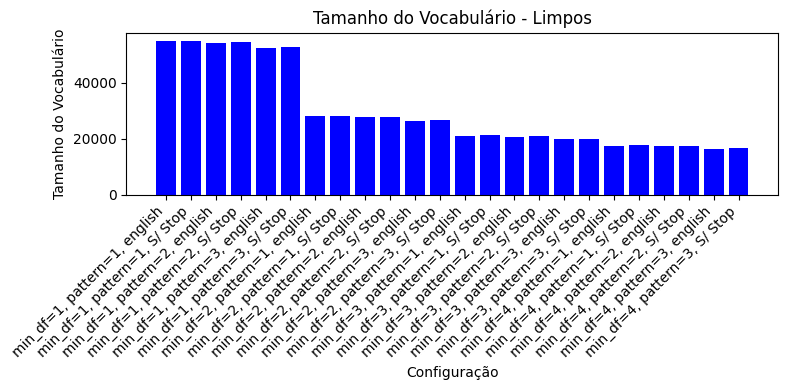

Tabela de Vocabulário - Porter
+------------------------------+--------------------------+
| Configuração                 |   Tamanho do Vocabulário |
|------------------------------+--------------------------|
| min_df=1, pattern=1, english |                    40167 |
| min_df=1, pattern=1, S/ Stop |                    40386 |
| min_df=1, pattern=2, english |                    39734 |
| min_df=1, pattern=2, S/ Stop |                    39923 |
| min_df=1, pattern=3, english |                    37885 |
| min_df=1, pattern=3, S/ Stop |                    38034 |
| min_df=2, pattern=1, english |                    20370 |
| min_df=2, pattern=1, S/ Stop |                    20586 |
| min_df=2, pattern=2, english |                    20016 |
| min_df=2, pattern=2, S/ Stop |                    20202 |
| min_df=2, pattern=3, english |                    18792 |
| min_df=2, pattern=3, S/ Stop |                    18938 |
| min_df=3, pattern=1, english |                    15472 |
| min_df=

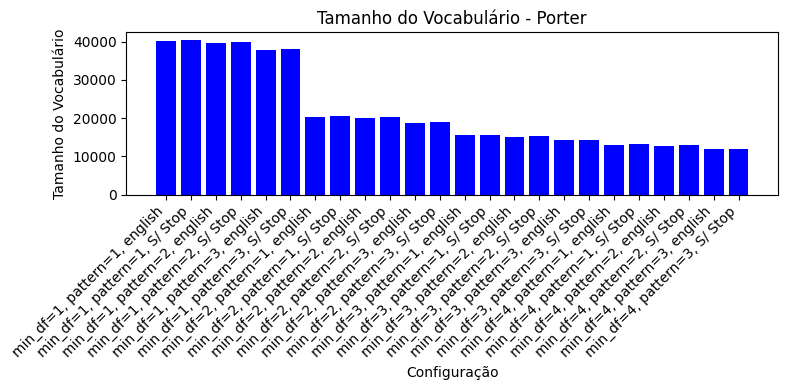

Tabela de Vocabulário - Snowball
+------------------------------+--------------------------+
| Configuração                 |   Tamanho do Vocabulário |
|------------------------------+--------------------------|
| min_df=1, pattern=1, english |                    39721 |
| min_df=1, pattern=1, S/ Stop |                    39945 |
| min_df=1, pattern=2, english |                    39295 |
| min_df=1, pattern=2, S/ Stop |                    39489 |
| min_df=1, pattern=3, english |                    37377 |
| min_df=1, pattern=3, S/ Stop |                    37528 |
| min_df=2, pattern=1, english |                    20115 |
| min_df=2, pattern=1, S/ Stop |                    20336 |
| min_df=2, pattern=2, english |                    19769 |
| min_df=2, pattern=2, S/ Stop |                    19960 |
| min_df=2, pattern=3, english |                    18497 |
| min_df=2, pattern=3, S/ Stop |                    18645 |
| min_df=3, pattern=1, english |                    15284 |
| min_d

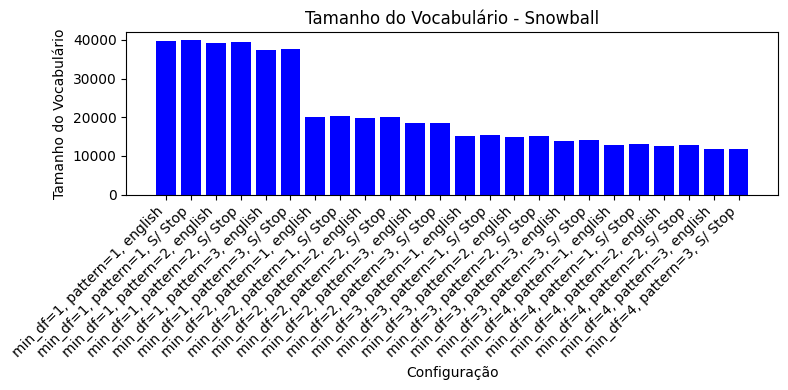

Tabela de Vocabulário - Lancaster
+------------------------------+--------------------------+
| Configuração                 |   Tamanho do Vocabulário |
|------------------------------+--------------------------|
| min_df=1, pattern=1, english |                    33296 |
| min_df=1, pattern=1, S/ Stop |                    33492 |
| min_df=1, pattern=2, english |                    32864 |
| min_df=1, pattern=2, S/ Stop |                    33030 |
| min_df=1, pattern=3, english |                    30371 |
| min_df=1, pattern=3, S/ Stop |                    30491 |
| min_df=2, pattern=1, english |                    17044 |
| min_df=2, pattern=1, S/ Stop |                    17229 |
| min_df=2, pattern=2, english |                    16687 |
| min_df=2, pattern=2, S/ Stop |                    16842 |
| min_df=2, pattern=3, english |                    14933 |
| min_df=2, pattern=3, S/ Stop |                    15043 |
| min_df=3, pattern=1, english |                    13041 |
| min_

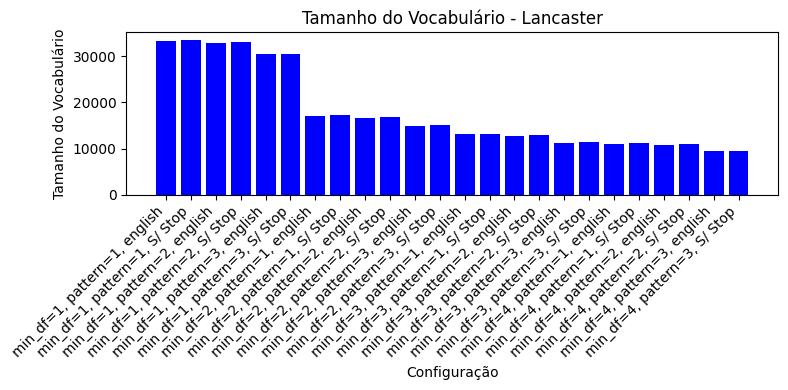

In [33]:
'''
Função para visualizar o tamanho de cada vocabulario com as diferentes configurações.
É criada uma tabela com a biblioteca pandas e é criado um gráfico de barras com a biblioteca matplotlib.
Atributos: 
    - dicionario: dicionário com as informações de cada vocabulário;
    - tipo_stemmer: tipo de stemmer utilizado.
'''
def criar_tabela_vocabulario(dicionario, tipo_stemmer):
    dados = []
    #é adicionado ao array dados o nome da configuração e o tamanho do vocabulário
    for configuracao, informacoes in dicionario.items():
        #utiliza-se a função extrair_parametros para extrair a configuração do nome da configuração, que está na key
        min_df, pattern, stop = extrair_parametros(configuracao)
        tamanho_vocabulario = len(informacoes['vocabulario'])
        dados.append([f"min_df={min_df}, pattern={pattern}, {stop}", tamanho_vocabulario])
    
    #criar a tabela com a biblioteca pandas
    df = pd.DataFrame(dados, columns=['Configuração', 'Tamanho do Vocabulário'])
    
    print(f"Tabela de Vocabulário - {tipo_stemmer}")
    #imprimir a tabela com a biblioteca tabulate
    print(tabulate(df, headers='keys', tablefmt='psql', showindex=False))
    
    # Gráfico de barras
    plt.figure(figsize=(8, 4))
    plt.bar(df['Configuração'], df['Tamanho do Vocabulário'], color='blue')
    plt.title(f'Tamanho do Vocabulário - {tipo_stemmer}')
    plt.xlabel('Configuração')
    plt.ylabel('Tamanho do Vocabulário')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
'''
Função para extrair a configuração do nome da configuração, que está na key.
'''
def extrair_parametros(configuracao):
    parametros = configuracao.split('_')
    min_df = parametros[2]
    pattern = parametros[4]
    stop_words = parametros[6] if parametros[6] != 'None' else 'S/ Stop'
    return min_df, pattern, stop_words

# Carregar os dicionários
dicionario_limpos = pickle.load(open("ficheirosPickel/dicionario_limpos.p", "rb"))
dicionario_porter = pickle.load(open("ficheirosPickel/dicionario_porter.p", "rb"))
dicionario_snowball = pickle.load(open("ficheirosPickel/dicionario_snowball.p", "rb"))
dicionario_lancaster = pickle.load(open("ficheirosPickel/dicionario_lancaster.p", "rb"))

# Criar tabela e gráfico para cada stemmer
criar_tabela_vocabulario(dicionario_limpos, "Limpos")
criar_tabela_vocabulario(dicionario_porter, "Porter")
criar_tabela_vocabulario(dicionario_snowball, "Snowball")
criar_tabela_vocabulario(dicionario_lancaster, "Lancaster")


Analisando os resultados verifica-se que:

- Ao utilizar o *stop words* vai sempre reduzir em centenas as palavras do vocabulário;
- Ao aumentar o minimo de vezes que cada palavra aparece no corpus de 1 para 2 o vocabulário tem uma diminuição bastante grande. Para além disso, se uma palavra só aparece uma vez no corpus, não interessa muito para a classificação pois nao diz muito sobre o documento.
- O tamanho de cada palavra não faz com que o tamanho do vocabulário varie muito, contudo existe uma maior variação de palavras de 3 caracteres para 4 caracteres.

- Em termos de stemmers, verificamos uma redução de quase 8000 palavras (olhando para quando se vectoriza com o min_df = 2 e o pattern = 1), com a exceção do Lancaster que é de mais ou menos de 10000 palavras.



### Metodologia de teste e de treino e métricas de desempenho

Um dos requisitos mais importantes para desenvolver um modelo de classificação é a existência de um conjunto de treino e um conjunto de teste. O conjunto de treino são os dados usados para treinar o modelo, ou seja, vão ser a base da classificação, sendo que o modelo aprende padrões nos dados e ajusta os seus parâmetros. Este conjunto convém ser representativo do domínio geral do problema, ser diversificado e abrangente para uma melhor generalização dos novos dados. O conjunto de teste são os dados para avaliar o desempenho do modelo após o treino. São dados que o modelo não conhece na fase de treino e, por isso, vai estimar a eficácia do modelo. Porém, ao fazer uma divisão dos dados de treino e de teste tem a sua desvantagem, sendo esta que os dados do conjunto de teste podem ser só exemplos faceis ou só exemplos dificeis.

Para avaliar o modelo de uma forma mais estável e sistemática, utiliza-se a Validação Cruzada, onde, em vez de se depender de uma única validação dos dados de treino e teste, esta vai dividir os dados em vários sub-conjunotos, e são treinados  vários modelos. Um dos métodos é o *K-fold Cross Validation*, onde os dados são divididos em K sub-conjunots, cada um contendo aproximadamente o mesmo número de dados, um dos sub-conjuntos é usado para teste e os restantes para treino, e repete-se o processo até que todos os *folds* tenham sido para teste. Assim, não há risco de apanhar apenhas exemplos fáceis ou dificies no teste, e pode ser utilizado mais dados para treino. Por outro lado, tem um custo computacional bastante grande, pois é necessário treinar K modelos sendo K vezes mais lento do que dividir em um conjunto de teste e um de treino. Adicionalmente, esta validação, não projeta um modelo, apenas estima o desempenho de um classificador. 

Um passo a fazer nos modelos é o ajuste dos hiper-parâmetros durante a fase de treino, pois ajustar os parametros com o conjunto de teste não é uma boa maneira de verificar o desempenho, pois assim o modelo já conhece os dados. Assim sendo, existe mais um conjunto de dados, o conjunto de validação, onde após construir o modelo com o conjunto de treino, é usado o conjunto de validação para selecionar e ajustar dos hiper-paramtros, deixando o conjunto de teste para avaliação apenas. Após encontrar os melhores hiper-parametros, deve-se voltar a treinar o modelo com o conjunto de treino mais o de validação.

Após o treino do modelo, é preciso avaliar, utilizando os dados de teste, utilizando métricas de desempenho para avaliar a efeciencia do modelo e a eficácia na classificação. Tendo as seguintes:

- Matriz de confusão, onde é possivel ver o desempenho do modelo de classificação, através dos acertos e erros. Aqui compara-se as classes previstas com as reais conseguindo visualizar o numero de acertos e de erros, vendo onde foi classificado em vez da classe real. Através da Matriz de confusão, é possivel calcular outras métricas que ajudam a avaliar o desempenho do modelo tais como:
    - Precisão: Verdadeiros Positivos / ( Verdadeiros Positivos + Falsos Positivos) - isto na classificação binária, sendo que quanto maior o valor, significa um menor numero de falsos positivos;
    - *Recall*: Verdadeiros Positivos / ( Verdadeiros Positivos + Falsos Negativos) - isto na classificação binária, sendo que quanto maior o valor, significa um menor numero de falsos negativos;
    - F1-score: 2 * ((Preciãos x *Recall*)/(Precisão + *Recall*)) - é possivel ver se existe um equilibrio entre a precisão e o recall.

Para obter diferentes resultados de classificação, varia-se limiares de decisão das funções, e com isto é possivel consultar curvas de desempenho para ajudar no processo de calibração dos modelos de classificação. Tem se então as Curvas *precision/recall* e Curvas ROC, onde, através da visualização das curvas, é possivél ver os resultados para todos os limiares possíveis, tendo um ponto otico, podendo calcular a distancia ao ponto optimo, e quanto menor esse valor melhor.



## Classificação Binária

A primeira classificação a desenvolver é a binária, cujo o objetivo é classificar a cerveja como:

- **Muito Boa** - se obteve *overall* de 9 ou mais valores;
- **Muito Má** - se obteve *overall* de 2 ou menos valores;

Através das reviews.

Uma classificação binária é o caso onde se tem apenas duas classes, neste caso de ser uma cerveja **Muito Boa** ou **Muito Ma**. Para tal, existem varios modelos possiveis de classificação binária, tais como:

 - Discriminantes Lineares;
 - Discriminante Logistico;
 - Máquina de Vetores de Suport e (SVM);
 - K-Vizinhos Mais Próximos (KNN).


Os Classificadores que vao ser desenvolvidos são o Discriminante Logistico e a Máquina de Vetores de Suporte (SVM).

Para a clssificação binária, teve-se duas abordagens:
- 1ª Abordagem: Classificar as cervejas como **Muito Boa** ou **Muito Má** com base no *overall* onde se desenvolve dois classificadores, um para classifcar se a cerveja é Muito Boa, atribuindo a classe 1 a cervejas com *overall* de 9 ou mais, e -1 para as restantes, e outro para classificar se a cerveja é Muito Má, atribuindo a classe 1 a cervejas com *overall* de 2 ou menos e -1 para as restantes;
- 2ª Abordagem: Classificar as cervejas como **Muito Boa** ou **Muito Má** com base no *overall* onde se ignorou as cervejas com os valores de 3 a 8, atribuindo a classe 1 a cervejas Muito Boas, e -1 para cervejas Muito Má.


### Classificador Binário 1 - Discriminante Logistico - 1ª Abordagem

O primeiro classificador é o Discriminante Logistico, que tem o objetivo de estimar a matriz de peso W, que vai ser utilizada para classificar os dados de teste. O modelo é uma transformação linear seguida de uma não linearidade, ou seja, a função de ativação. A transformação linear é a multiplicação dos dados de entrada X pela matriz de pesos W, sendo que se multiplica pela matriz transposta de W. A função de ativação, utiliza o resultado da transformação anterior utilizando depois uma função sigmoide ( 1 / (1 + e^(-u)) ), onde u é o resultado da transformação linear, ou a tangente hiperbólica (tanh(u)), onde u é o resultado da transformação linear, resultando no y_previsto.

A utilização deste modelotem a vantagem de ter como saida probabilidades, facilitando a interpretação dos resultados, é fácild e implementear, tem baixo risco de overfitting, podendo utilizar métodos de regularização, como o Lasso e o Ridge. Por outro lado, tem a desvantagem de ser um modelo linear, sendo que não dificilmente consegue aprender relações não lineares, e não é muito flexivel, pois não consegue aprender relações complexas.


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

Para o discriminante logistico, utiliza-se a função *LogisticRegression()*, desenvolve-se então uma função para treinar e testar um modelo.
O modelo vai gerar a matriz W, a matriz de pesos, que vai ser utilizada para classificar os dados de teste. Sendo que estes pesos vao estar relacionados com a importância de cada palavra para a classificação.

In [35]:
'''
Função para treinar e testar um modelo de classificação.
Atributos: 
    - X_train: matriz documento-termo de treino;
    - X_test: matriz documento-termo de teste;
    - y_train: classes de treino;
    - y_test: classes de teste.
    - vocabulario: vocabulário.
Return:
    - vocabulario: vocabulário;
    - matriz_confusao: matriz de confusão;
    - precisao: precisão;
    - recall: recall;
    - f1_score: f1-score;
    - dl_score_treino: score do modelo de treino;
    - dl_score_teste: score do modelo de teste.
'''

def logistic_Regression(X_train, X_test, y_train, y_test, vocabulario):
    
    
    modelo = LogisticRegression()
    
    #treinar o modelo
    modelo.fit(X_train, y_train)
    
    #testar o modelo
    y_e = modelo.predict(X_test)
    
    #calcular as métricas de desempenho
    matriz_confusao = confusion_matrix(y_test, y_e)
    
    print("Matriz de Confusão:")
    print(matriz_confusao)
    print("----------")
    
    #evitar erros de divisão por 0
    if (matriz_confusao[1][1] + matriz_confusao[0][1]) != 0:
        precisao = matriz_confusao[1][1] / (matriz_confusao[1][1] + matriz_confusao[0][1])
        recall = matriz_confusao[1][1] / (matriz_confusao[1][1] + matriz_confusao[1][0])
    else:
        precisao = 0.0
        recall = 0.0
        
    if (precisao + recall) != 0:
        f1_score = 2 * ((precisao * recall) / (precisao + recall))
    else:
        f1_score = 0.0
  
    
    print("Precisão:", precisao)
    print("Recall:", recall)
    print("F1-score:", f1_score)
    
    print("dl_Score_Treino:", modelo.score(X_train, y_train))
    print("dl_Score_Teste:", modelo.score(X_test, y_test))
    
    print("----------")
    
    # verificar os pesos resultantes do modelo treinado
    w=modelo.coef_
    # fazer o squeeze para retirar os eixos com tamanho 1
    w=w.squeeze()
    
    # ordenar os pesos
    idx = np.argsort(w).squeeze() 
    # ordenar o vocabulario de acordo com os pesos
    voc2 = [vocabulario[i] for i in idx] 
    
    #ver as palavras com os pesos mais baixos
    for i in idx[:100]:
        print('(%.2f) %s'%(w[i],voc2[i]))


    print('\n','-'*100,'\n')
    
    #ver as palavras com os pesos mais altos
    for i in idx[-100:]:
        print('(%.2f) %s'%(w[i],voc2[i]))

    return vocabulario, matriz_confusao, precisao, recall, f1_score, modelo.score(X_train, y_train), modelo.score(X_test, y_test)

Ainda a construir o vocabulário e procurar os melhores parametros para a vetorização.
Divide-se os dados de treino em treino e validação, para se poder fazer a validação cruzada, através da função *train_test_split()*, onde se divide os dados de treino em 2/3 para treino e 1/3 para validação. Aqui já não se vai testar a vetorização quando o min_df = 1. 
Vai se então testar para os diferentes stemmers, e treinar e testar o modelo para cada conjunto de documentos e verificar os valores das metricas, para analisar qual tem os melhores valores e definir a mehor configuração para depois começar-se a testar o s parametros para o discriminante logistico.

In [36]:
'''
Função  que vai testar, para um stemmer, várias combinações de parametros para a vetorização mostrando os resultados das métricas de desempenho do modelo de classificação.
Atributos: 
    - stemmer: tipo de stemmer utilizado;
    - docs: conjunto de documentos;
    - y: classes.
Return:
    - dicionario_valores: dicionário com os valores das métricas de desempenho para cada configuração.
'''

def teste_logistic_Regression(stemmer, docs, y):
    
    #dividir os dados de treino em treino e teste
    X_train, X_test, y_train, y_test = train_test_split(docs, y, test_size=1/3, random_state=42)
    #dividir os dados de treino em treino e validação
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=1/3, random_state=42)
    
    #conjuntos de parametros para testar
    ngrams      = [(1,1), (1,2), (1,3)]
    mdfs         = [2,3,4,5]
    tps         = [r'\b\w\w+\b', r'\b\w\w\w+\b', r'\b\w\w\w\w+\b']

    print(f"Stemmer: {stemmer}")
    
    dicionario_valores = {}
    
    
    for mdf in mdfs:
            t_index = 0
            for token in tps:
                t_index += 1
                for ngram in ngrams:
                    
                    # Construir o nome do arquivo para salvar o vocabulário
                    configuracao = f"min_df_{mdf}_pattern_{t_index}_ngram_{ngram}"
        
                    # Aplicar vetorização e criar vocabulário para cada conjunto de documentos
                    stop = 'english'
                    vectorizer = TfidfVectorizer(min_df=mdf, token_pattern=token, stop_words=stop, ngram_range=ngram).fit(X_train)
                    X_train_t = vectorizer.transform(X_train)
                    X_val_t = vectorizer.transform(X_val)
                    
                    vocabulario = vectorizer.get_feature_names_out()
                    
                    #aplicar a função para treinar e testar o modelo
                    vocabulario, matriz_confusao, precisao, recall, f1_score, dl_score_treino, dl_score_val = logistic_Regression(X_train_t, X_val_t, y_train, y_val, vocabulario)
                    dicionario_valores[configuracao] = {'vocabulario': vocabulario, 'matriz_confusao': matriz_confusao, 'precisao': precisao, 'recall': recall, 'f1_score': f1_score, 'dl_score_treino': dl_score_treino, 'dl_score_val': dl_score_val}
                    
                    print(f"Configuração: {configuracao}")
                    print(f"Vocabulário: {len(vocabulario)}")
                    print(f"Matriz de Confusão: {matriz_confusao}")
                    print(f"Precisão: {precisao}")
                    print(f"Recall: {recall}")
                    print(f"F1-score: {f1_score}")
                    print("----------")
                    print("----------")
                    print("----------")
                    print("----------")
                    print("----------")
                    print("----------")
                    print("----------")
    return dicionario_valores


In [37]:
'''
Função para treinar e testar os varios stemmers com diferentes configurações, e guardar em ficheiros pickel.

Atributos: 
    - y: classes.
    - maior_que_9: booleano para saber se se está a classificar as cervejas como muito boas ou muito más.

'''

def executar_teste_de_stemmers_e_vetorizacao(y, maior_que_9):
   
    
    #documentoa limpoa sem stemming
    docs = pickle.load(open("ficheirosPickel/documentos_limpos.p", "rb"))
    docs = np.array(docs)
    dicionario_limpos = teste_logistic_Regression("Limpos", docs, y)
    #armazenar os valores
    if maior_que_9:
        pickle.dump(dicionario_limpos, open("ficheirosPickel/dicionario_limpos_pos_dl.p", "wb"))
    else:
        pickle.dump(dicionario_limpos, open("ficheirosPickel/dicionario_limpos_neg_dl.p", "wb"))

    
    #documentos porter
    docs = pickle.load(open("ficheirosPickel/documentos_porter.p", "rb"))
    docs = np.array(docs)
    dicionario_porter = teste_logistic_Regression("Porter", docs, y)
    #armazenar os valores
    if maior_que_9:
        pickle.dump(dicionario_porter, open("ficheirosPickel/dicionario_porter_pos_dl.p", "wb"))
    else:
        pickle.dump(dicionario_porter, open("ficheirosPickel/dicionario_porter_neg_dl.p", "wb"))

    
    #documentos snowball
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    docs = np.array(docs)
    dicionario_snowball = teste_logistic_Regression("Snowball", docs, y)
    #armazenar os valores
    if maior_que_9:
        pickle.dump(dicionario_snowball, open("ficheirosPickel/dicionario_snowball_pos_dl.p", "wb"))
    else:
        pickle.dump(dicionario_snowball, open("ficheirosPickel/dicionario_snowball_neg_dl.p", "wb"))

    
    #documentos lancaster
    docs = pickle.load(open("ficheirosPickel/documentos_lancaster.p", "rb"))
    docs = np.array(docs)
    dicionario_lancaster = teste_logistic_Regression("Lancaster", docs, y)
    #armazenar os valores
    if maior_que_9:
        pickle.dump(dicionario_lancaster, open("ficheirosPickel/dicionario_lancaster_pos_dl.p", "wb"))
    else:
        pickle.dump(dicionario_lancaster, open("ficheirosPickel/dicionario_lancaster_neg_dl.p", "wb"))



In [38]:
def plot_classes(y):
    print(f"Total de Críticas: {len(y)}")
    print(f"Total de Críticas 1: {len(y[y == 1])}")
    print(f"Total de Críticas -1: {len(y[y == -1])}")
    plt.hist(y, bins=[-1, 0, 1], edgecolor='black', alpha=0.7)
    plt.xlabel('Classificação y')
    plt.ylabel('Número de Críticas')
    plt.title('Distribuição das Classificações Overall Teste')
    plt.xticks([-1, 0, 1])  # Definindo os rótulos do eixo x para exibir apenas -1, 0, 1
    plt.show()


Total de Críticas: 75000
Total de Críticas 1: 5052
Total de Críticas -1: 69948


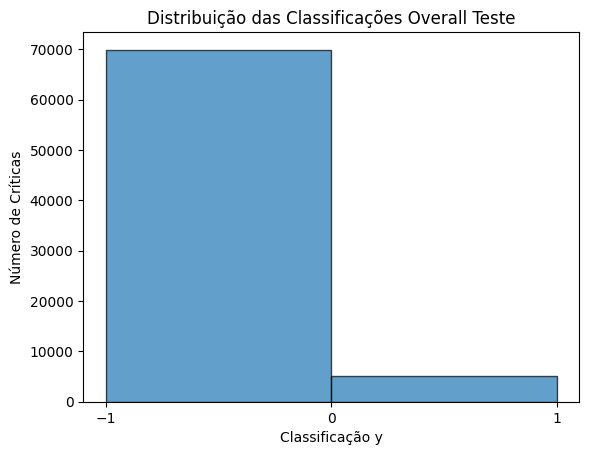

Total de Críticas: 75000
Total de Críticas 1: 3346
Total de Críticas -1: 71654


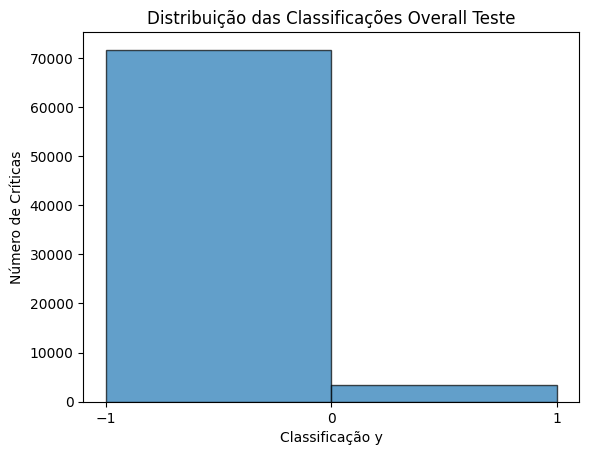

In [39]:
y = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTrain])
plot_classes(y)
# executar_teste_de_stemmers_e_vetorizacao(y, True)
y = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) <= 2 else -1 for idx in beerDictTrain])
plot_classes(y)
# executar_teste_de_stemmers_e_vetorizacao(y, False)

Cria-se agora uma função para visualizar os resultados dos diferentes stemmers e configurações, através de uma tabela e de um gráfico de barras.

In [40]:
''' 
Função para criar tabela e gráficos de barras para vizualizar os resultados dos diferentes stemmers e configurações.

Atributos: 
    - dicionario: dicionário com as informações de cada vocabulário;
    - tipo_stemmer: tipo de stemmer utilizado.
'''
def criar_tabela_metricas(dicionario, tipo_stemmer):
    dados = []

    for configuracao, informacoes in dicionario.items():
        min_df, pattern, stop = extrair_parametros(configuracao)
        precisao = informacoes['precisao']
        recall = informacoes['recall']
        f1_score = informacoes['f1_score']
        dl_score_treino = informacoes['dl_score_treino']
        dl_score_val = informacoes['dl_score_val']
        
        dados.append([f"min_df={min_df}, pattern={pattern}, {stop}", precisao, recall, f1_score, dl_score_treino, dl_score_val])

    df = pd.DataFrame(dados, columns=['Configuração', 'Precisão', 'Recall', 'F1-score', 'DL Score Treino', 'DL Score Validação'])
    
    print(f"Tabela de Métricas - {tipo_stemmer}")
    print(tabulate(df, headers='keys', tablefmt='psql', showindex=False))
    
    # Gráficos separados para Precisão, Recall, F1-score e DL Scores
    plt.figure(figsize=(20, 20))
    plt.subplots_adjust(hspace=1)
    
    # Limites para garantir consistência nas escalas
    ylim_min, ylim_max = 0, 1

    # Gráfico de barras para Precisão
    plt.subplot(4, 1, 1)
    plt.bar(df['Configuração'], df['Precisão'], color='green')
    plt.title(f'Precisão - {tipo_stemmer}')
    plt.xlabel('Configuração')
    plt.ylabel('Precisão')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(ylim_min, ylim_max)

    # Gráfico de barras para Recall
    plt.subplot(4, 1, 2)
    plt.bar(df['Configuração'], df['Recall'], color='blue')
    plt.title(f'Recall - {tipo_stemmer}')
    plt.xlabel('Configuração')
    plt.ylabel('Recall')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(ylim_min, ylim_max)

    # Gráfico de barras para F1-score
    plt.subplot(4, 1, 3)
    plt.bar(df['Configuração'], df['F1-score'], color='orange')
    plt.title(f'F1-score - {tipo_stemmer}')
    plt.xlabel('Configuração')
    plt.ylabel('F1-score')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(ylim_min, ylim_max)

    # Gráfico de barras para DL Scores (Treino e Validação)
    plt.subplot(4, 1, 4)
    config_labels = df['Configuração']
    width = 0.35
    plt.bar(config_labels, df['DL Score Treino'], width, color='purple', alpha=0.5, label='Treino')
    plt.bar(config_labels, df['DL Score Validação'], width, color='red', alpha=0.5, label='Validação', align='edge')
    plt.title(f'DL Scores - {tipo_stemmer}')
    plt.xlabel('Configuração')
    plt.ylabel('DL Score')
    plt.legend()
    plt.xticks(rotation=45, ha='right')
    plt.ylim(ylim_min, ylim_max)

    plt.show()


Tabela de Métricas - Limpos
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.596899 | 0.0691824 |  0.123994  |          0.939399 |             0.934721 |
| min_df=2, pattern=1, (1, 2) |   0.679245 | 0.032345  |  0.0617496 |          0.937659 |             0.934361 |
| min_df=2, pattern=1, (1, 3) |   0.697674 | 0.0269542 |  0.0519031 |          0.936879 |             0.934241 |
| min_df=2, pattern=2, (1, 1) |   0.6      | 0.0673854 |  0.121163  |          0.939339 |             0.934721 |
| min_df=2, pattern=2, (1, 2) |   0.692308 | 0.032345  |  0.0618026 |          0.937689 |             0.934421 |
| min_df=2, pattern=2, (1, 3) |   0.727273 | 0.0287511 |  0.0553155 

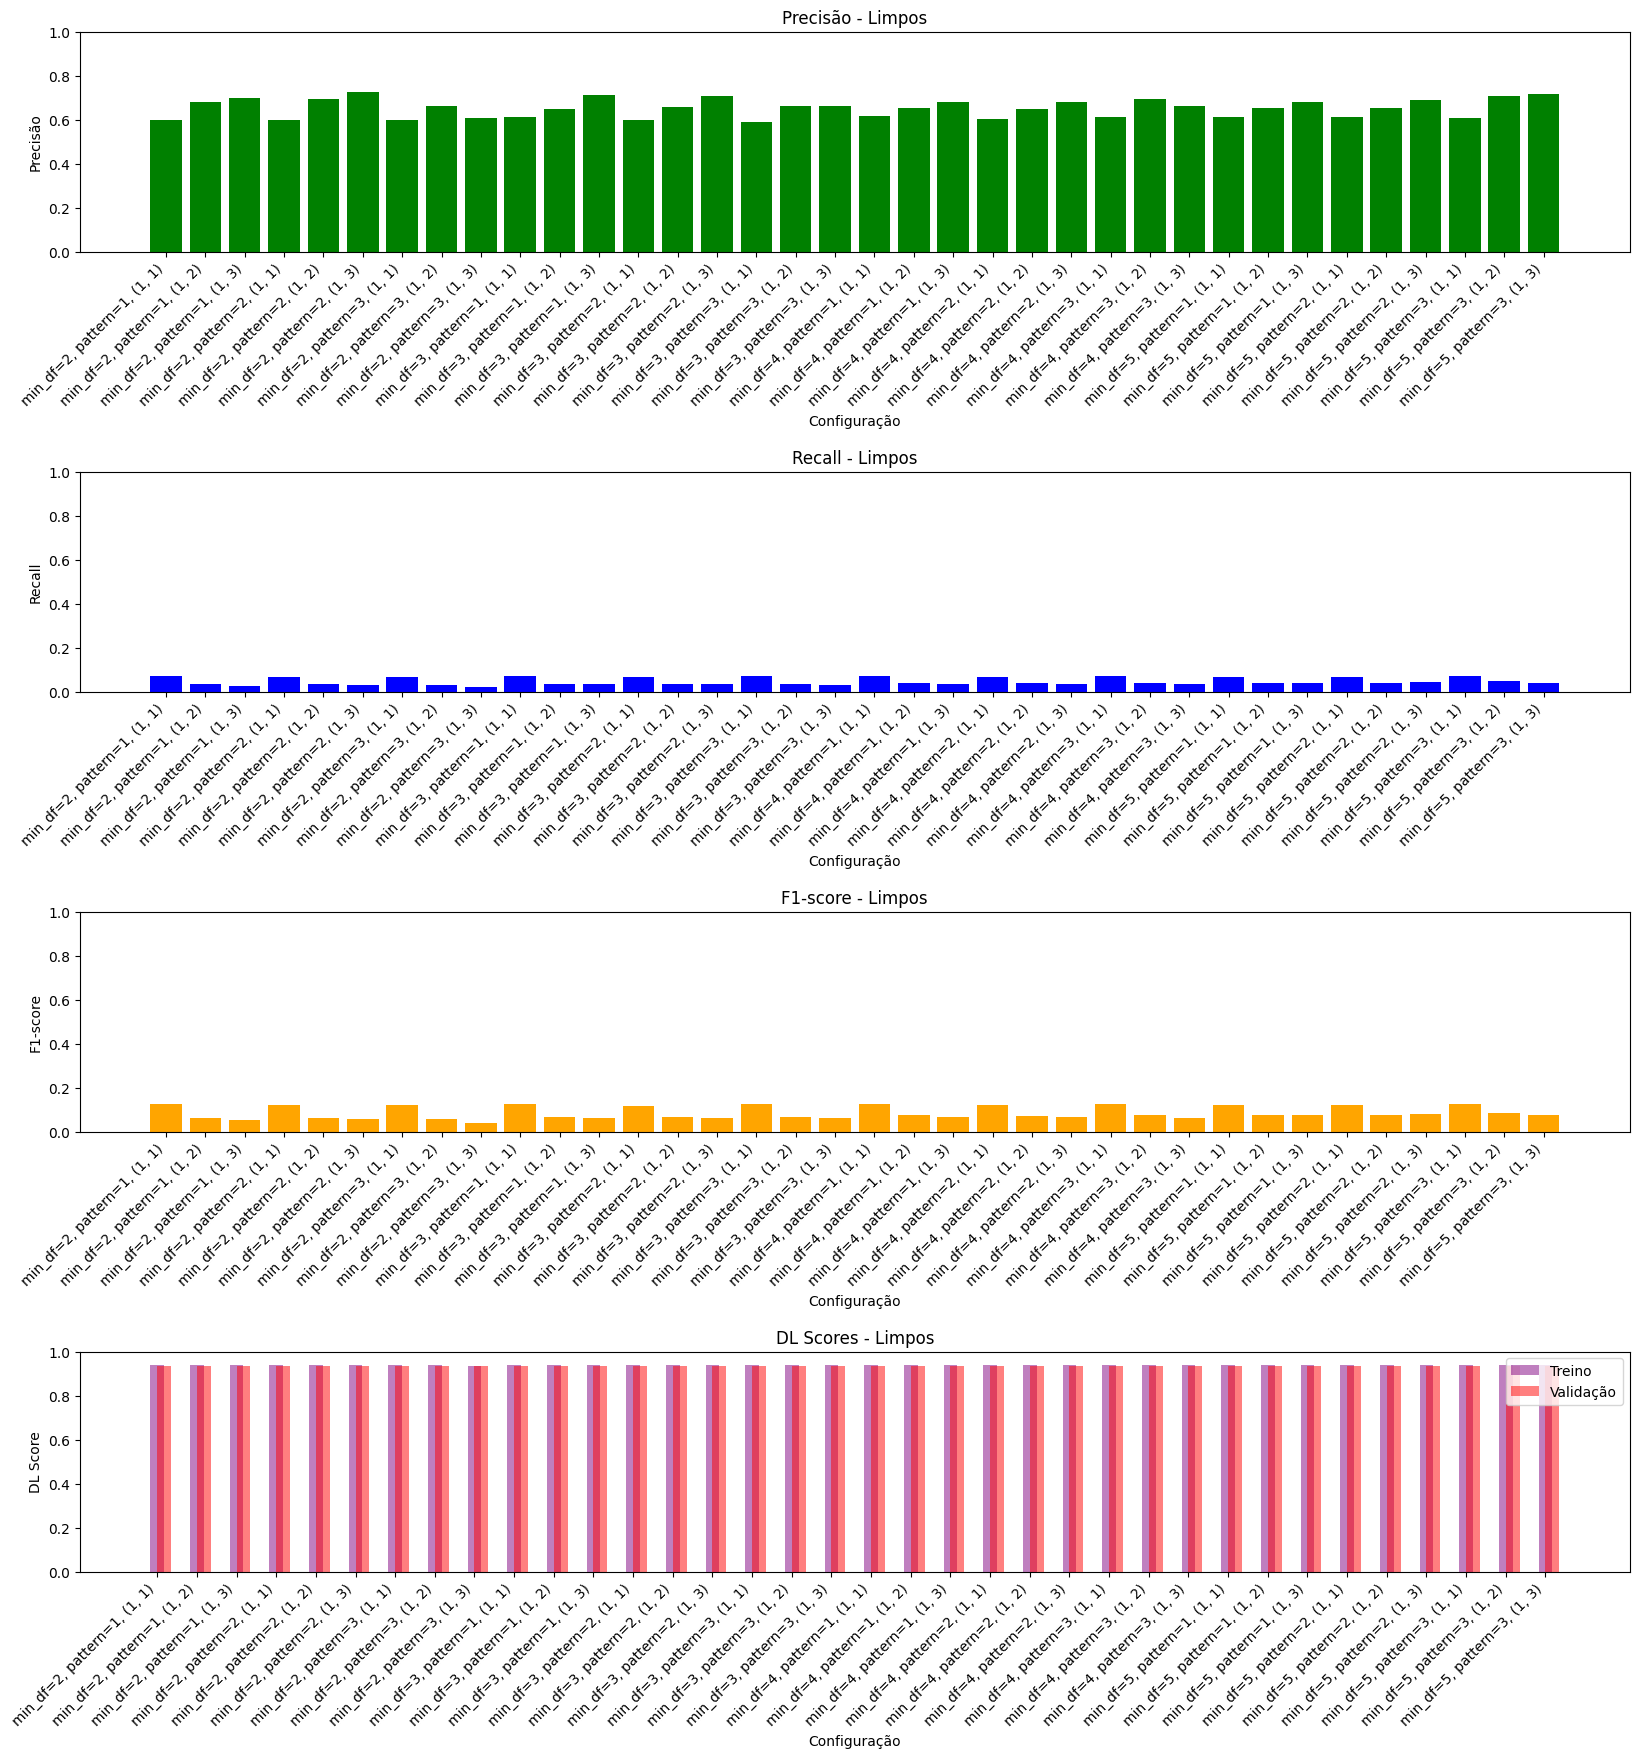

Tabela de Métricas - Porter
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.581081 | 0.0772686 |  0.1364    |          0.939639 |             0.934661 |
| min_df=2, pattern=1, (1, 2) |   0.711538 | 0.0332435 |  0.0635193 |          0.938529 |             0.934541 |
| min_df=2, pattern=1, (1, 3) |   0.704545 | 0.0278527 |  0.0535869 |          0.937539 |             0.934301 |
| min_df=2, pattern=2, (1, 1) |   0.578947 | 0.0790656 |  0.13913   |          0.939669 |             0.934661 |
| min_df=2, pattern=2, (1, 2) |   0.716981 | 0.034142  |  0.0651801 |          0.938649 |             0.934601 |
| min_df=2, pattern=2, (1, 3) |   0.708333 | 0.0305481 |  0.0585702 

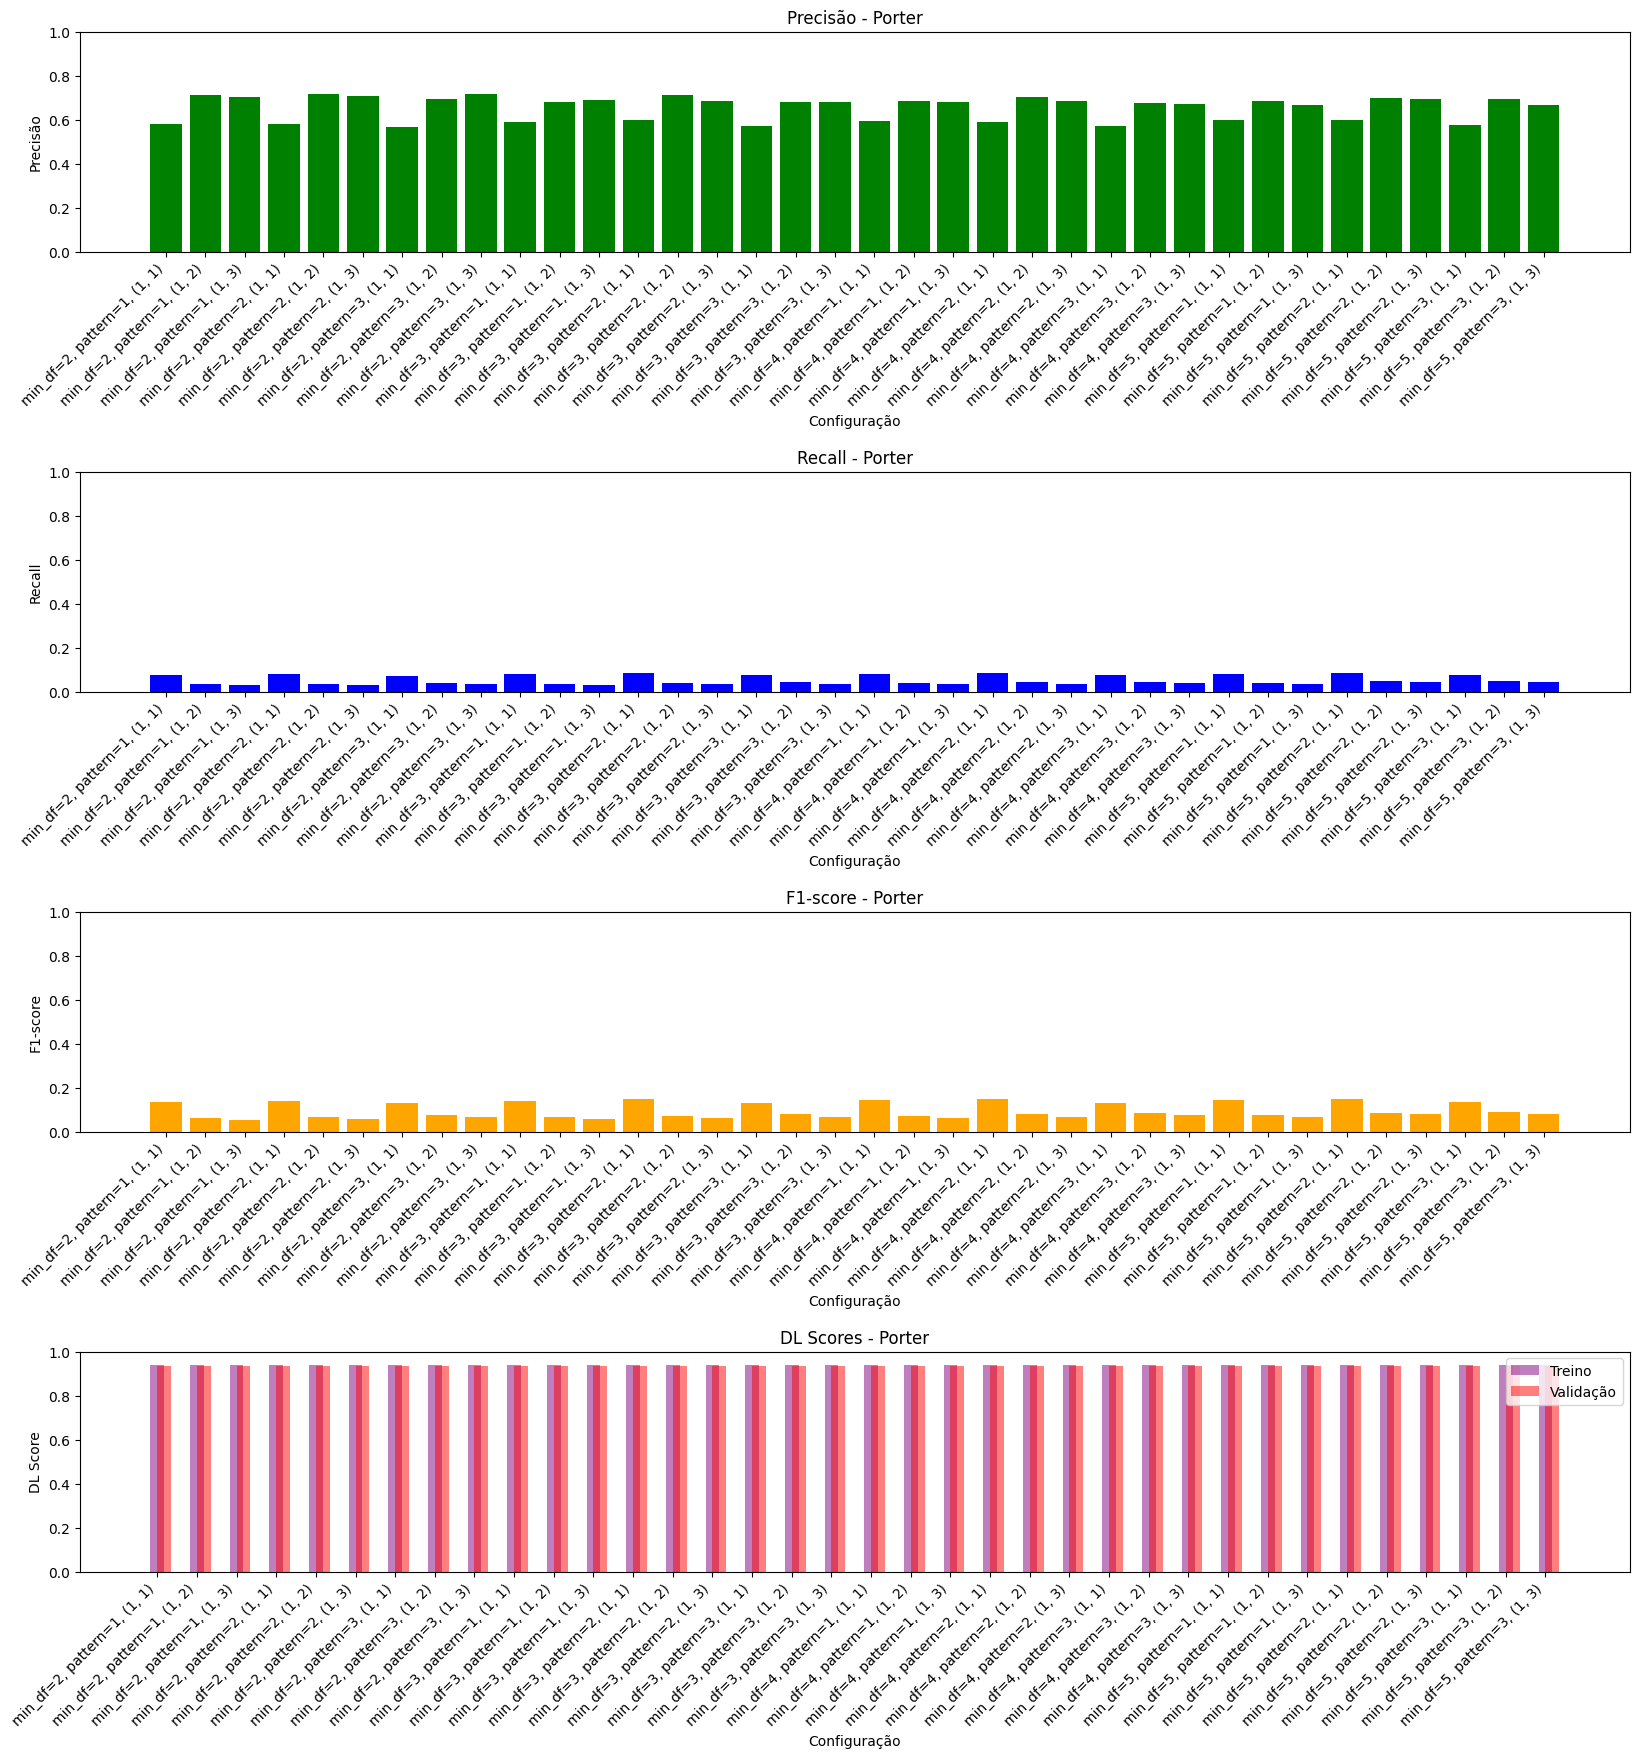

Tabela de Métricas - Snowball
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.578947 | 0.0790656 |  0.13913   |          0.940149 |             0.934661 |
| min_df=2, pattern=1, (1, 2) |   0.696429 | 0.0350404 |  0.0667237 |          0.938589 |             0.934541 |
| min_df=2, pattern=1, (1, 3) |   0.711111 | 0.0287511 |  0.0552677 |          0.937449 |             0.934361 |
| min_df=2, pattern=2, (1, 1) |   0.582278 | 0.0826595 |  0.144768  |          0.939969 |             0.934781 |
| min_df=2, pattern=2, (1, 2) |   0.709091 | 0.0350404 |  0.0667808 |          0.938559 |             0.934601 |
| min_df=2, pattern=2, (1, 3) |   0.695652 | 0.0287511 |  0.05522 

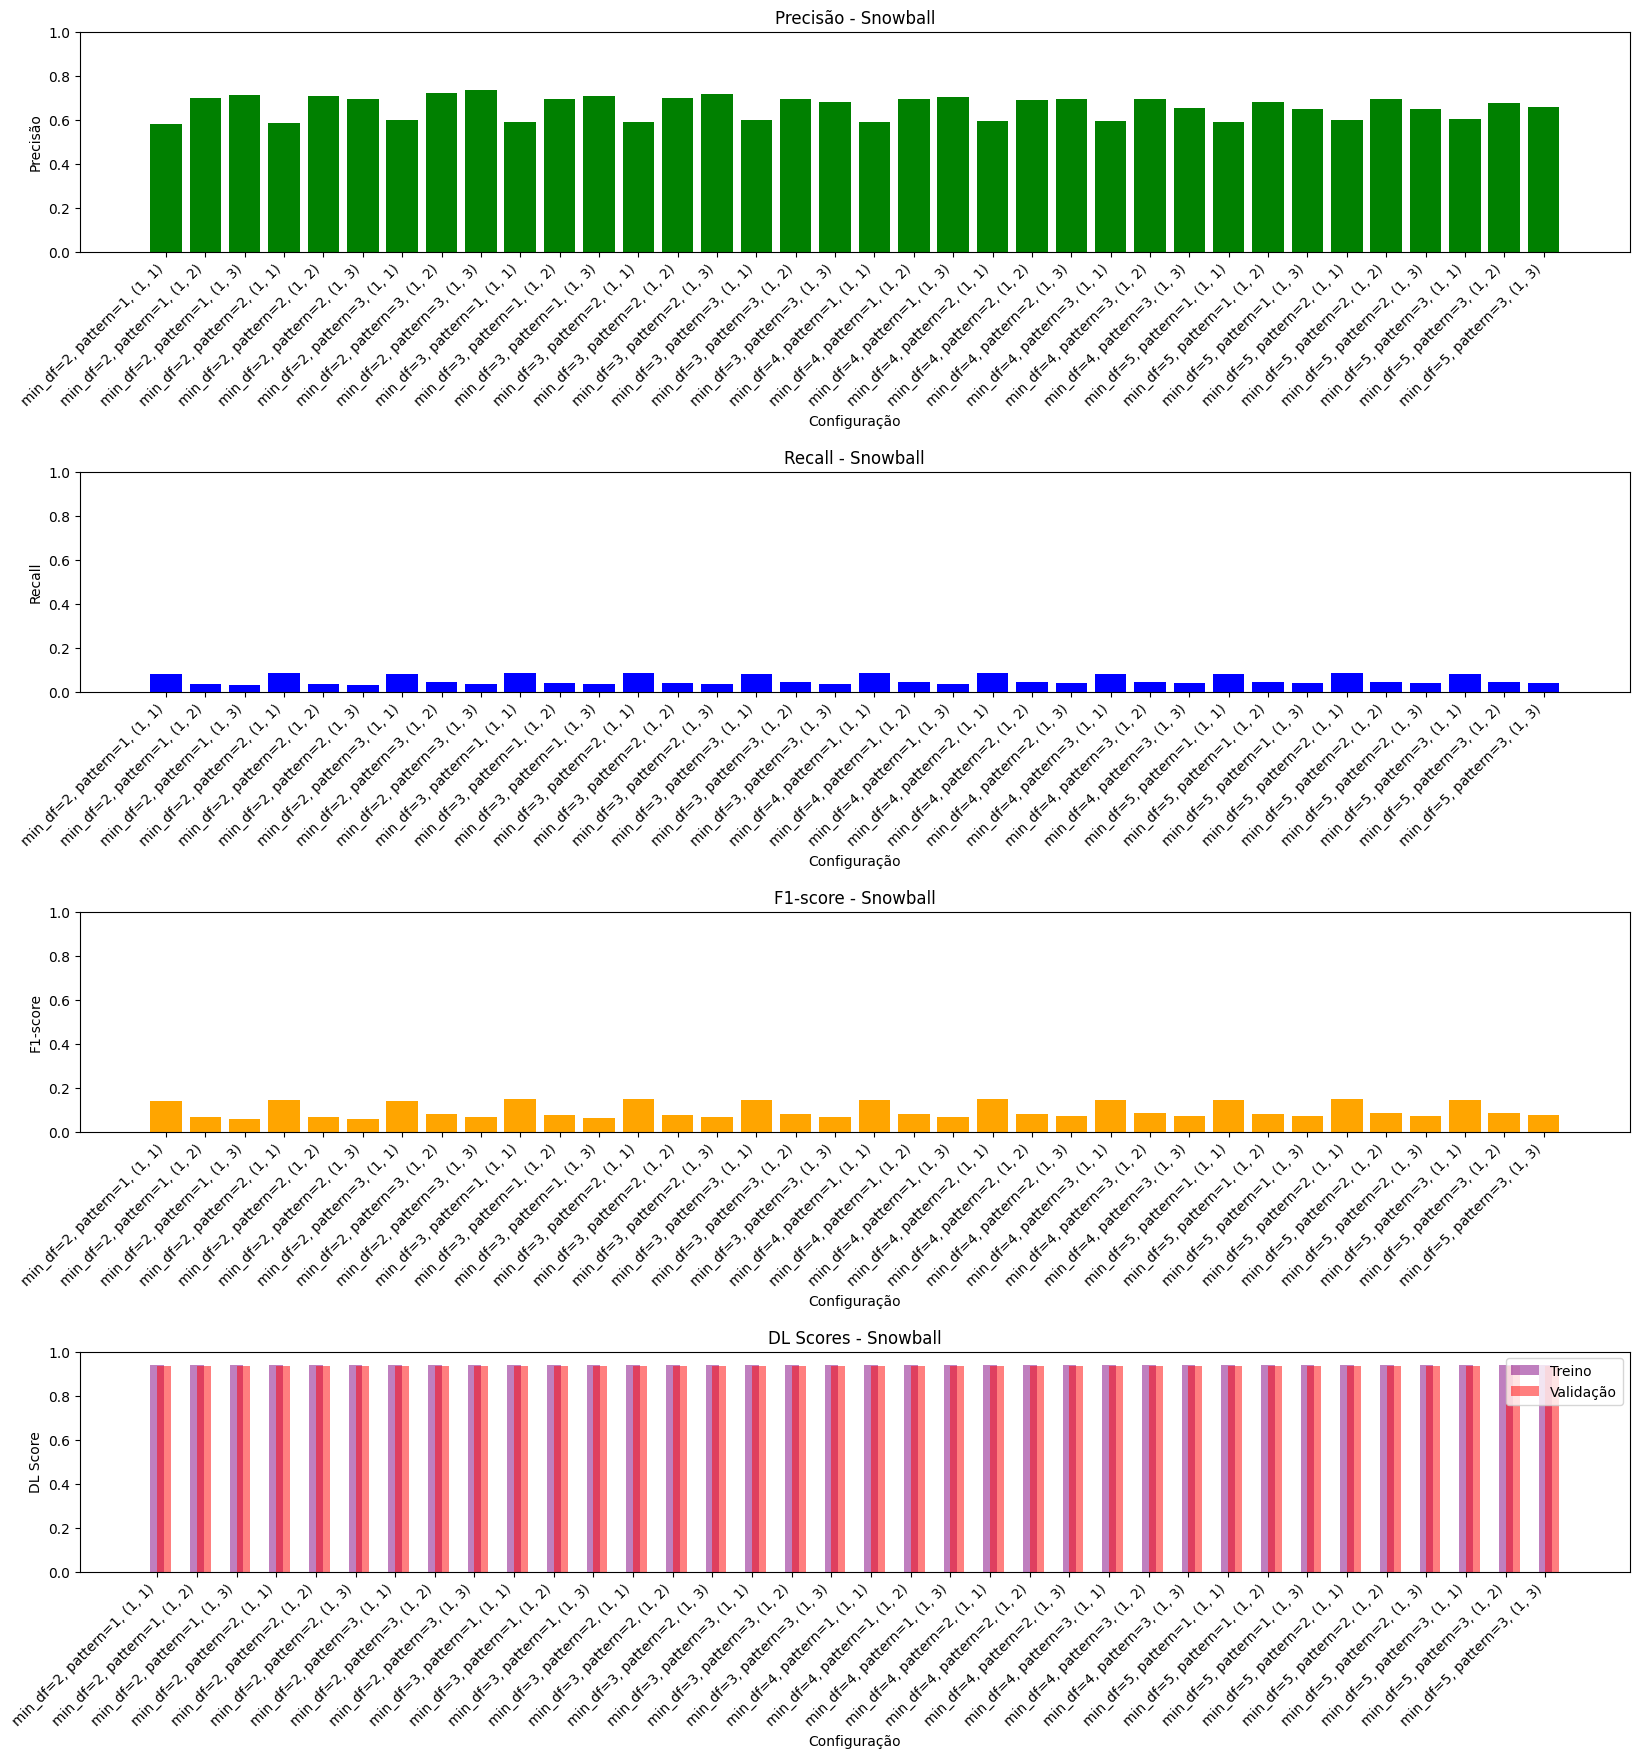

Tabela de Métricas - Lancaster
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.579882 | 0.0880503 |  0.152886  |          0.940329 |             0.934841 |
| min_df=2, pattern=1, (1, 2) |   0.775862 | 0.0404313 |  0.0768574 |          0.938889 |             0.935141 |
| min_df=2, pattern=1, (1, 3) |   0.74     | 0.0332435 |  0.0636285 |          0.937689 |             0.934661 |
| min_df=2, pattern=2, (1, 1) |   0.582353 | 0.0889488 |  0.154326  |          0.939849 |             0.934901 |
| min_df=2, pattern=2, (1, 2) |   0.754386 | 0.0386343 |  0.0735043 |          0.938619 |             0.934961 |
| min_df=2, pattern=2, (1, 3) |   0.734694 | 0.032345  |  0.06196

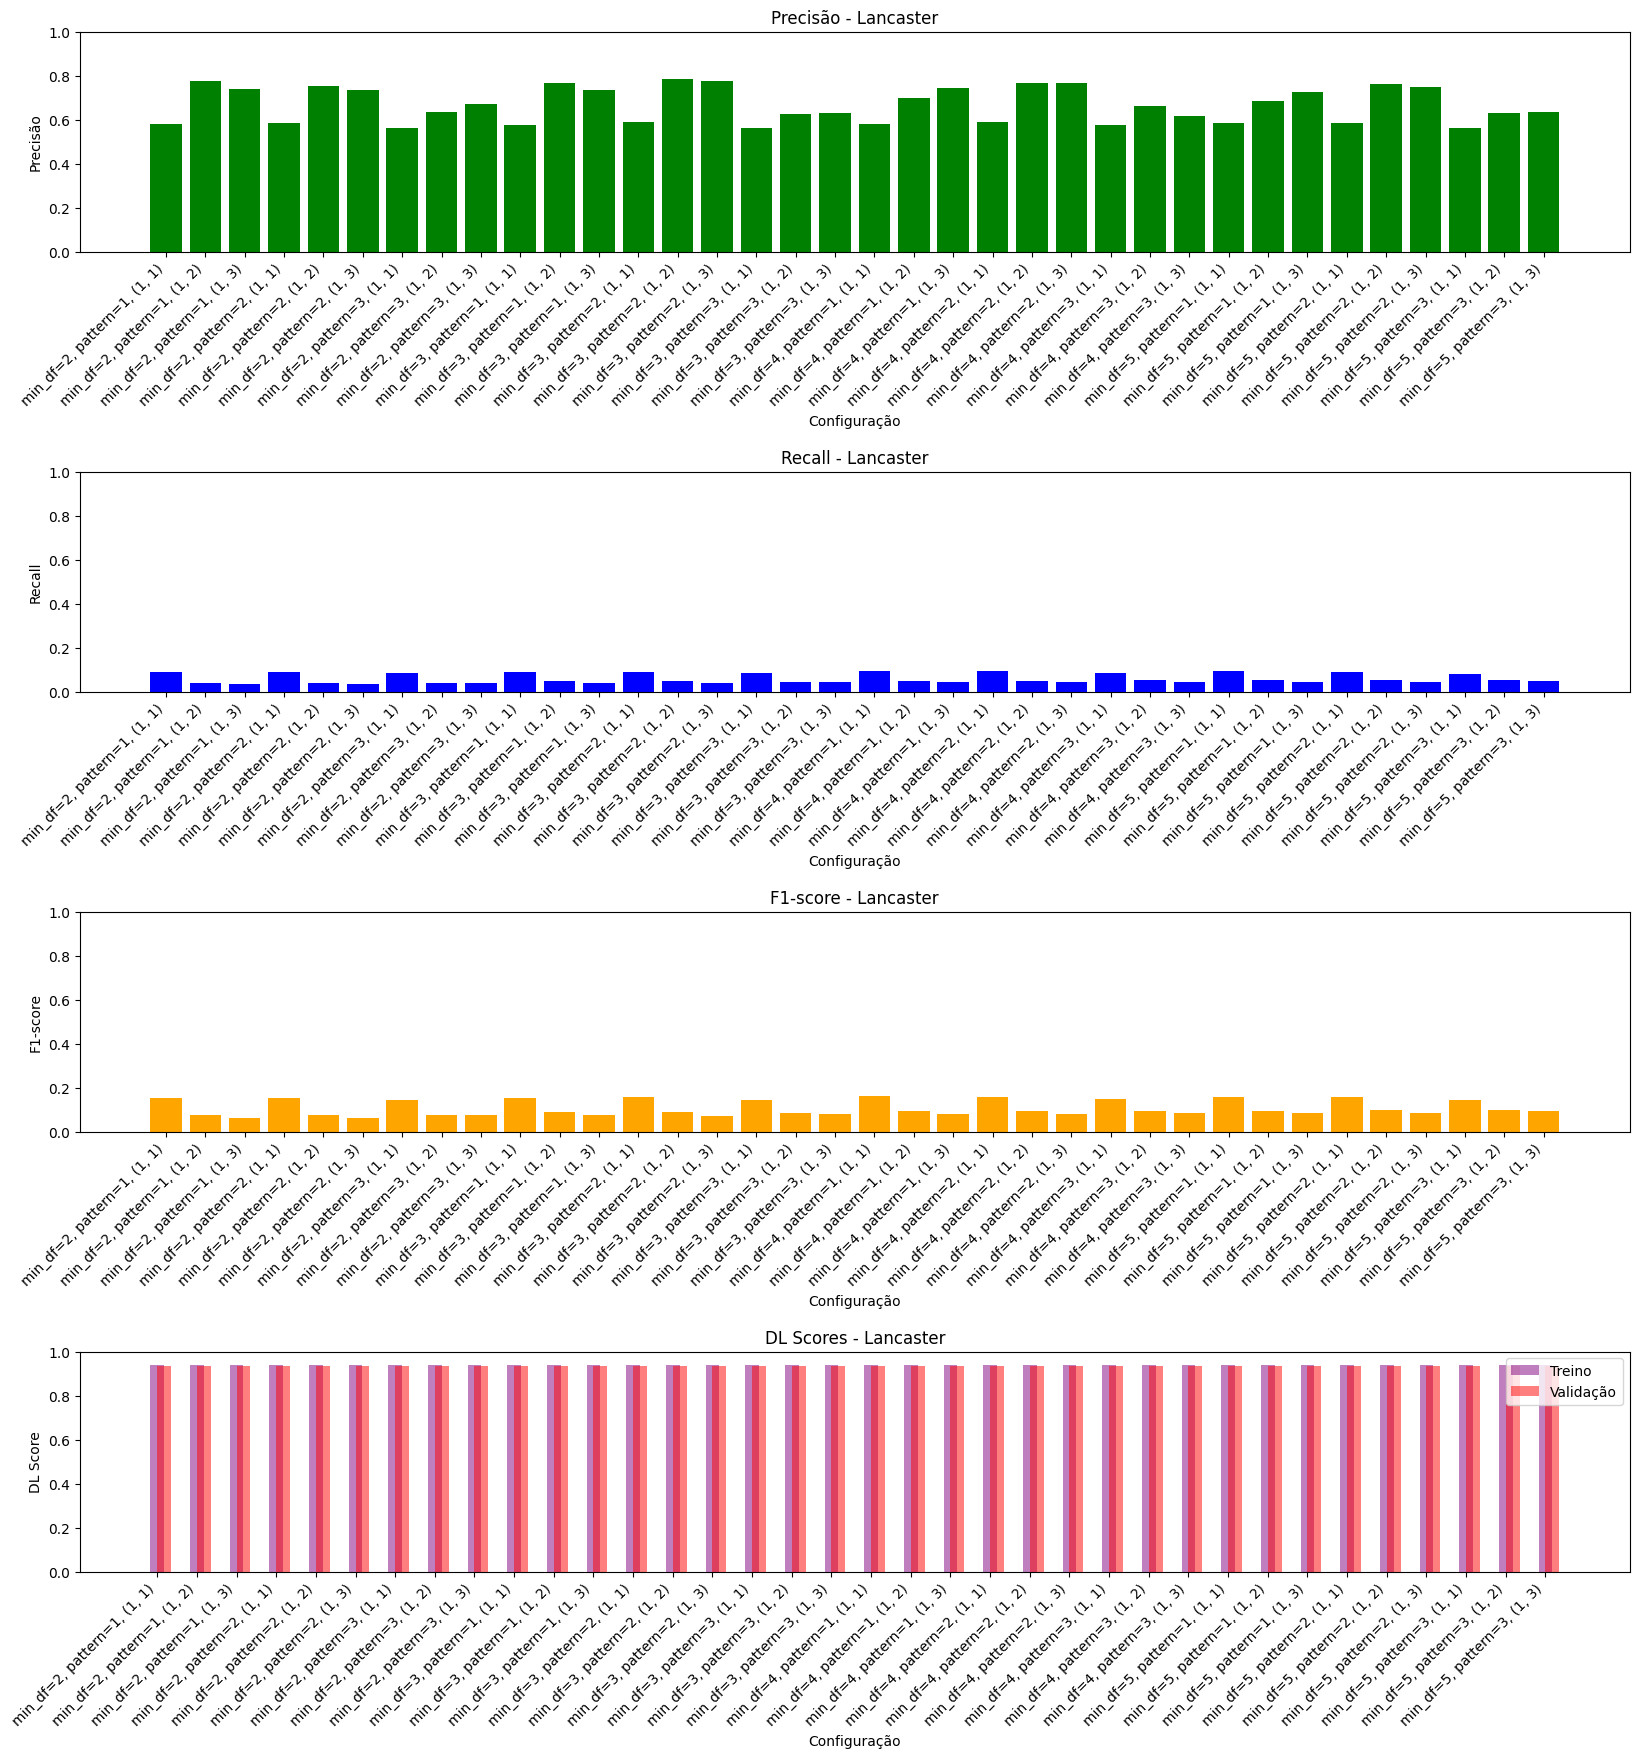

In [41]:
# Carregar os dicionários
dicionario_limpos = pickle.load(open("ficheirosPickel/dicionario_limpos_pos_dl.p", "rb"))
dicionario_porter = pickle.load(open("ficheirosPickel/dicionario_porter_pos_dl.p", "rb"))
dicionario_snowball = pickle.load(open("ficheirosPickel/dicionario_snowball_pos_dl.p", "rb"))
dicionario_lancaster = pickle.load(open("ficheirosPickel/dicionario_lancaster_pos_dl.p", "rb"))

# Criar tabela e gráfico para cada stemmer
criar_tabela_metricas(dicionario_limpos, "Limpos")
criar_tabela_metricas(dicionario_porter, "Porter")
criar_tabela_metricas(dicionario_snowball, "Snowball")
criar_tabela_metricas(dicionario_lancaster, "Lancaster")

Visualizar os resultados da classificaçao de Muito Más

Tabela de Métricas - Limpos
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.695238 | 0.102241  |  0.178266  |           0.96037 |             0.959621 |
| min_df=2, pattern=1, (1, 2) |   0.837838 | 0.0434174 |  0.0825566 |           0.95662 |             0.958661 |
| min_df=2, pattern=1, (1, 3) |   0.8      | 0.0336134 |  0.0645161 |           0.95584 |             0.958241 |
| min_df=2, pattern=2, (1, 1) |   0.706422 | 0.107843  |  0.18712   |           0.96037 |             0.959861 |
| min_df=2, pattern=2, (1, 2) |   0.842105 | 0.0448179 |  0.0851064 |           0.95659 |             0.958721 |
| min_df=2, pattern=2, (1, 3) |   0.8125   | 0.0364146 |  0.0697051 

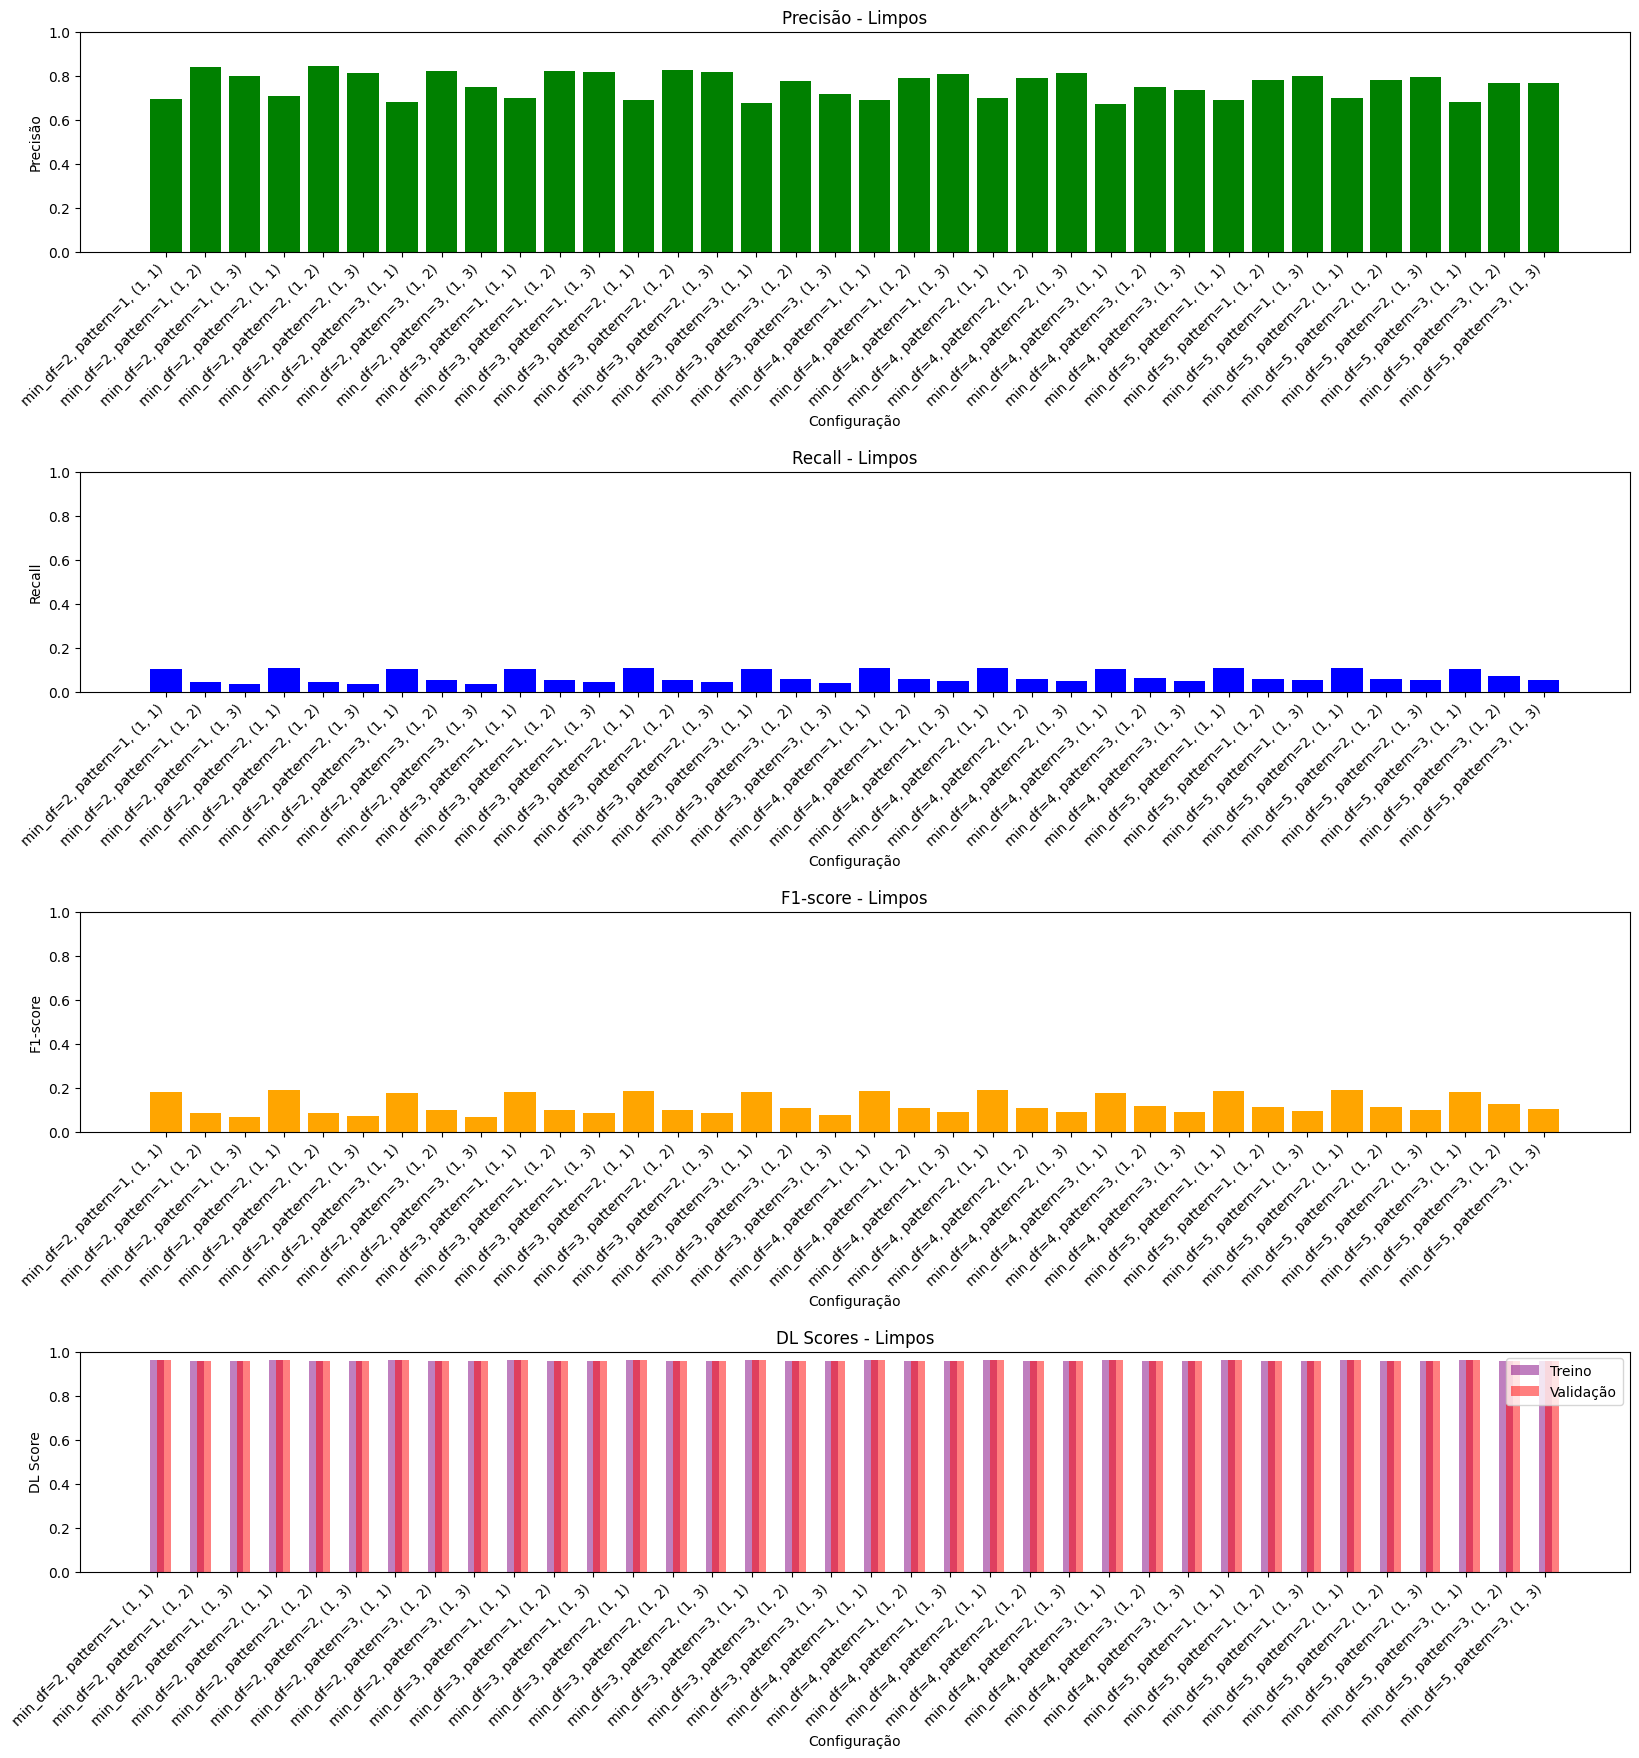

Tabela de Métricas - Porter
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.709677 | 0.123249  |  0.210024  |           0.96097 |             0.960281 |
| min_df=2, pattern=1, (1, 2) |   0.837209 | 0.0504202 |  0.0951123 |           0.95746 |             0.958901 |
| min_df=2, pattern=1, (1, 3) |   0.8      | 0.0336134 |  0.0645161 |           0.95587 |             0.958241 |
| min_df=2, pattern=2, (1, 1) |   0.717742 | 0.12465   |  0.212411  |           0.961   |             0.960401 |
| min_df=2, pattern=2, (1, 2) |   0.8125   | 0.0546218 |  0.102362  |           0.95755 |             0.958961 |
| min_df=2, pattern=2, (1, 3) |   0.764706 | 0.0364146 |  0.0695187 

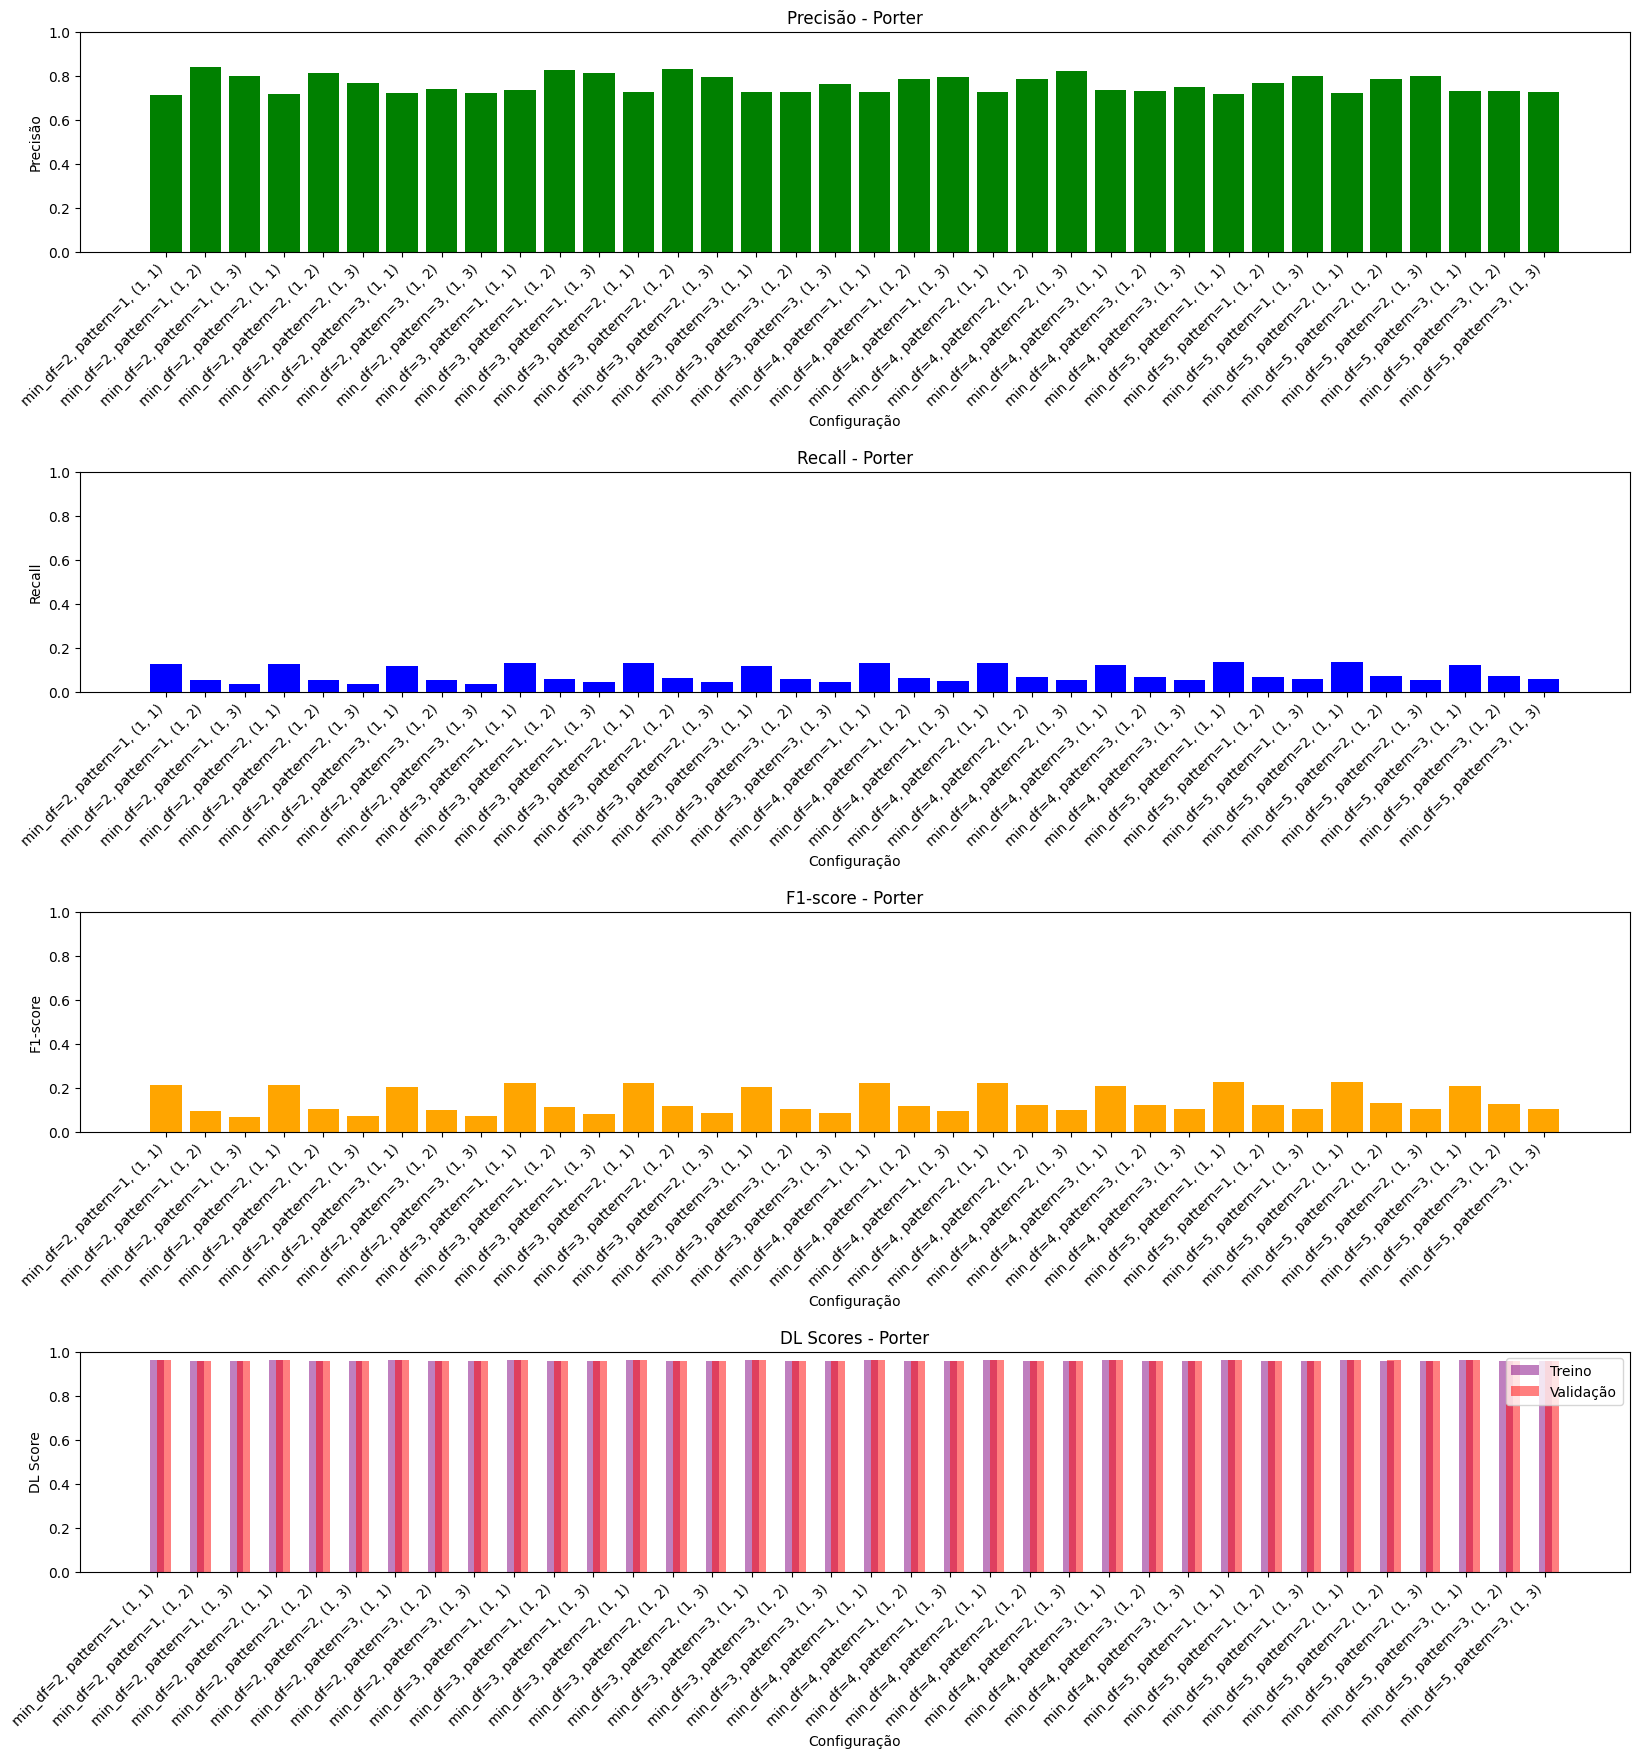

Tabela de Métricas - Snowball
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.72     | 0.12605   |  0.214541  |           0.96103 |             0.960461 |
| min_df=2, pattern=1, (1, 2) |   0.8      | 0.0504202 |  0.0948617 |           0.95746 |             0.958781 |
| min_df=2, pattern=1, (1, 3) |   0.777778 | 0.0392157 |  0.0746667 |           0.95635 |             0.958361 |
| min_df=2, pattern=2, (1, 1) |   0.722222 | 0.127451  |  0.216667  |           0.96091 |             0.960521 |
| min_df=2, pattern=2, (1, 2) |   0.826087 | 0.0532213 |  0.1       |           0.9574  |             0.958961 |
| min_df=2, pattern=2, (1, 3) |   0.771429 | 0.0378151 |  0.072096

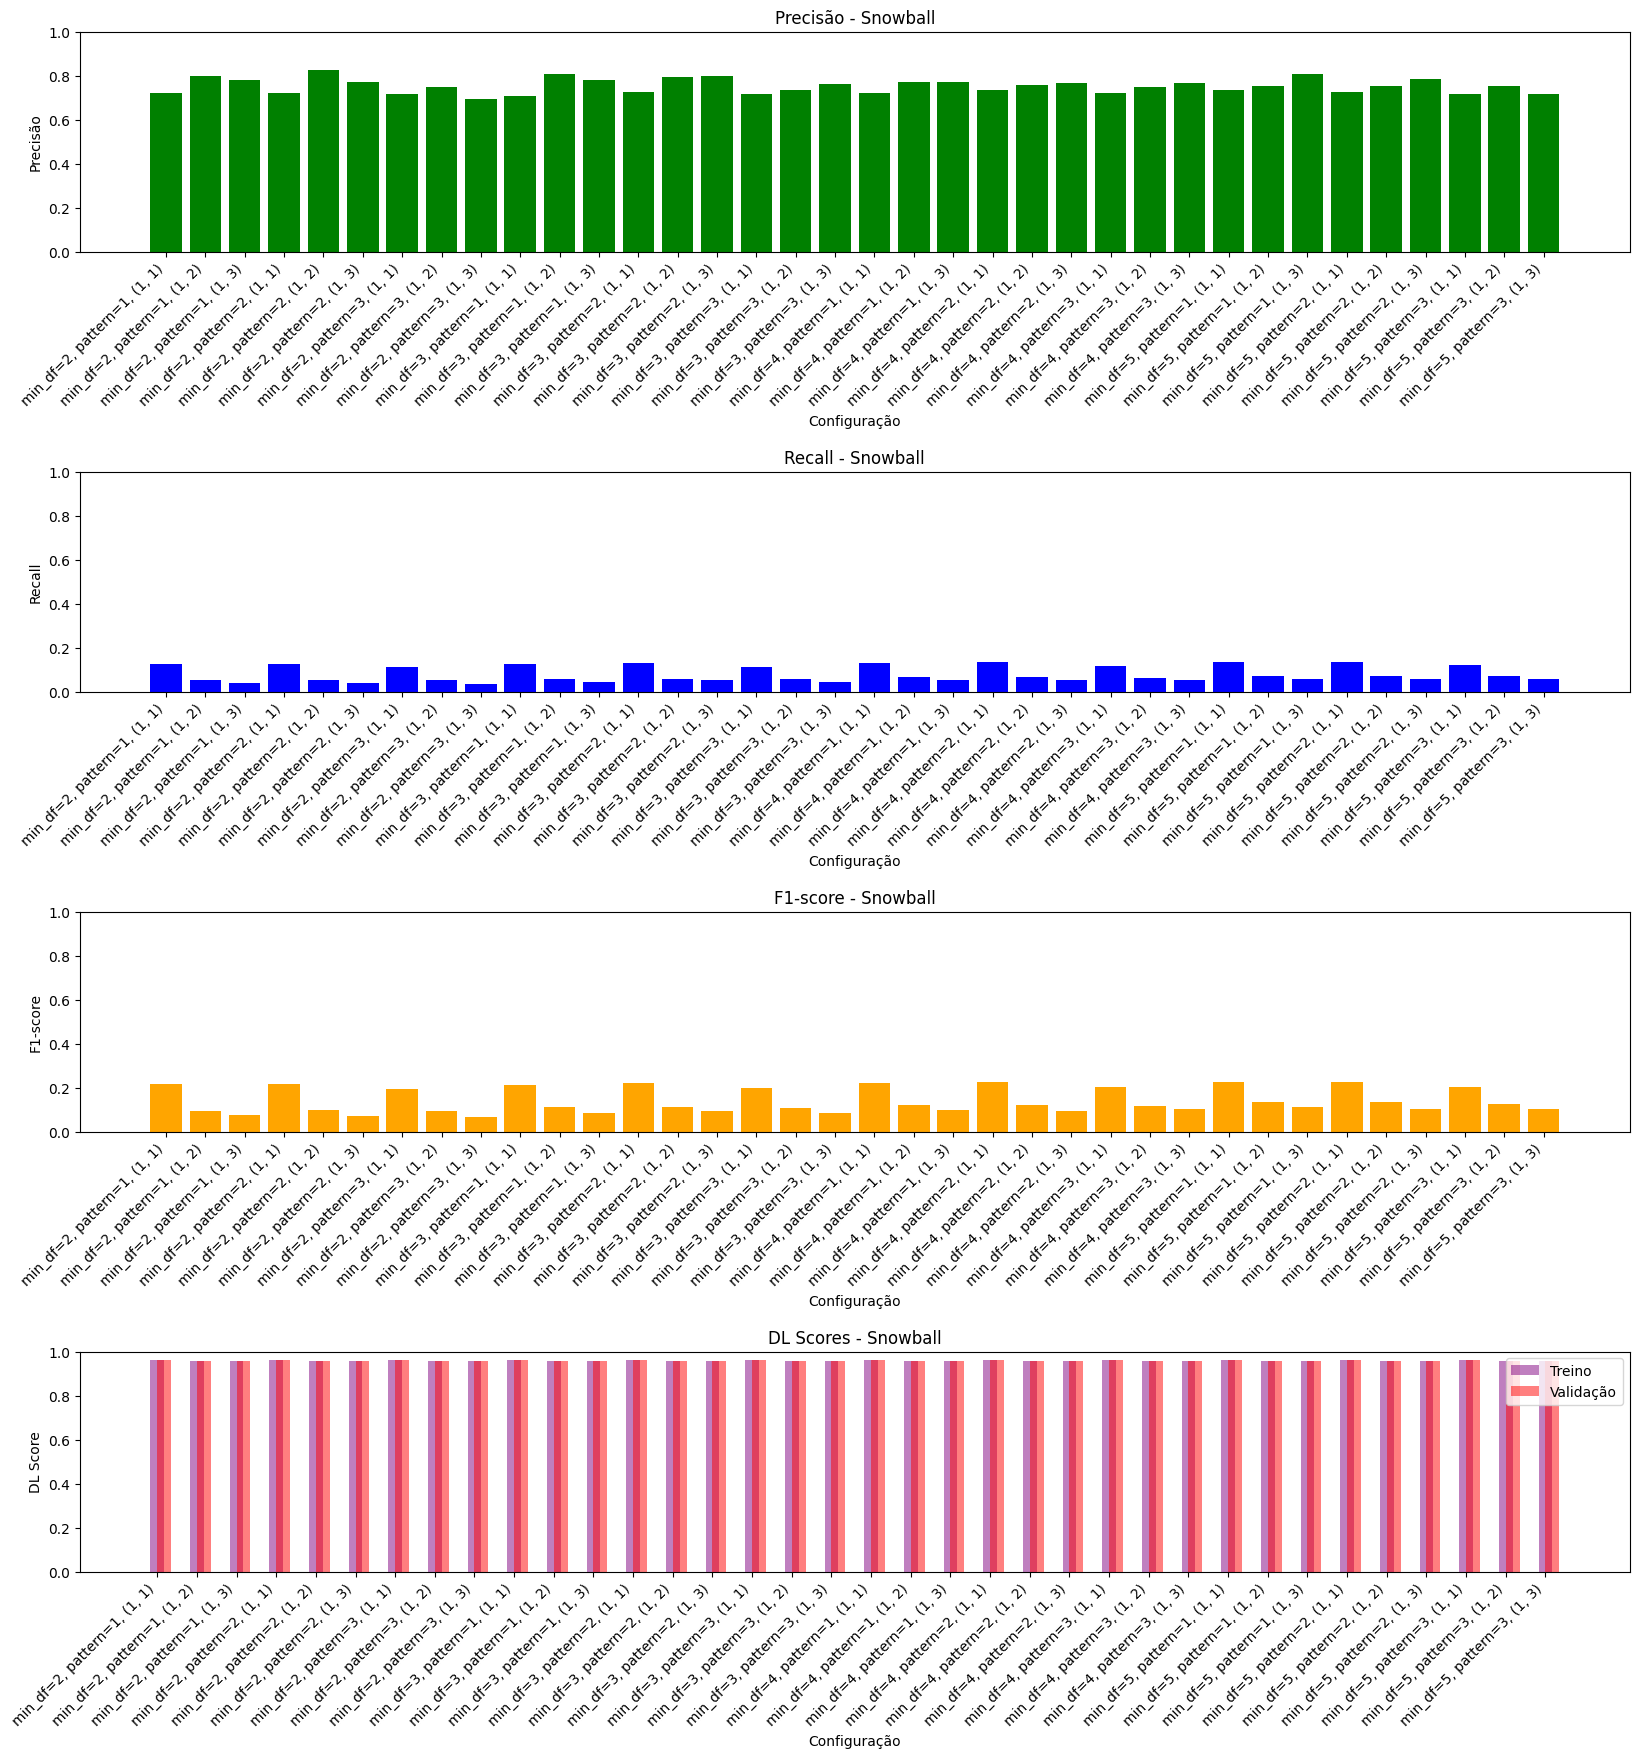

Tabela de Métricas - Lancaster
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.697674 | 0.12605   |  0.213523  |           0.96124 |             0.960221 |
| min_df=2, pattern=1, (1, 2) |   0.805556 | 0.0406162 |  0.0773333 |           0.95701 |             0.958481 |
| min_df=2, pattern=1, (1, 3) |   0.851852 | 0.0322129 |  0.0620783 |           0.95578 |             0.958301 |
| min_df=2, pattern=2, (1, 1) |   0.691176 | 0.131653  |  0.221176  |           0.96121 |             0.960281 |
| min_df=2, pattern=2, (1, 2) |   0.820513 | 0.0448179 |  0.0849934 |           0.95704 |             0.958661 |
| min_df=2, pattern=2, (1, 3) |   0.814815 | 0.0308123 |  0.05937

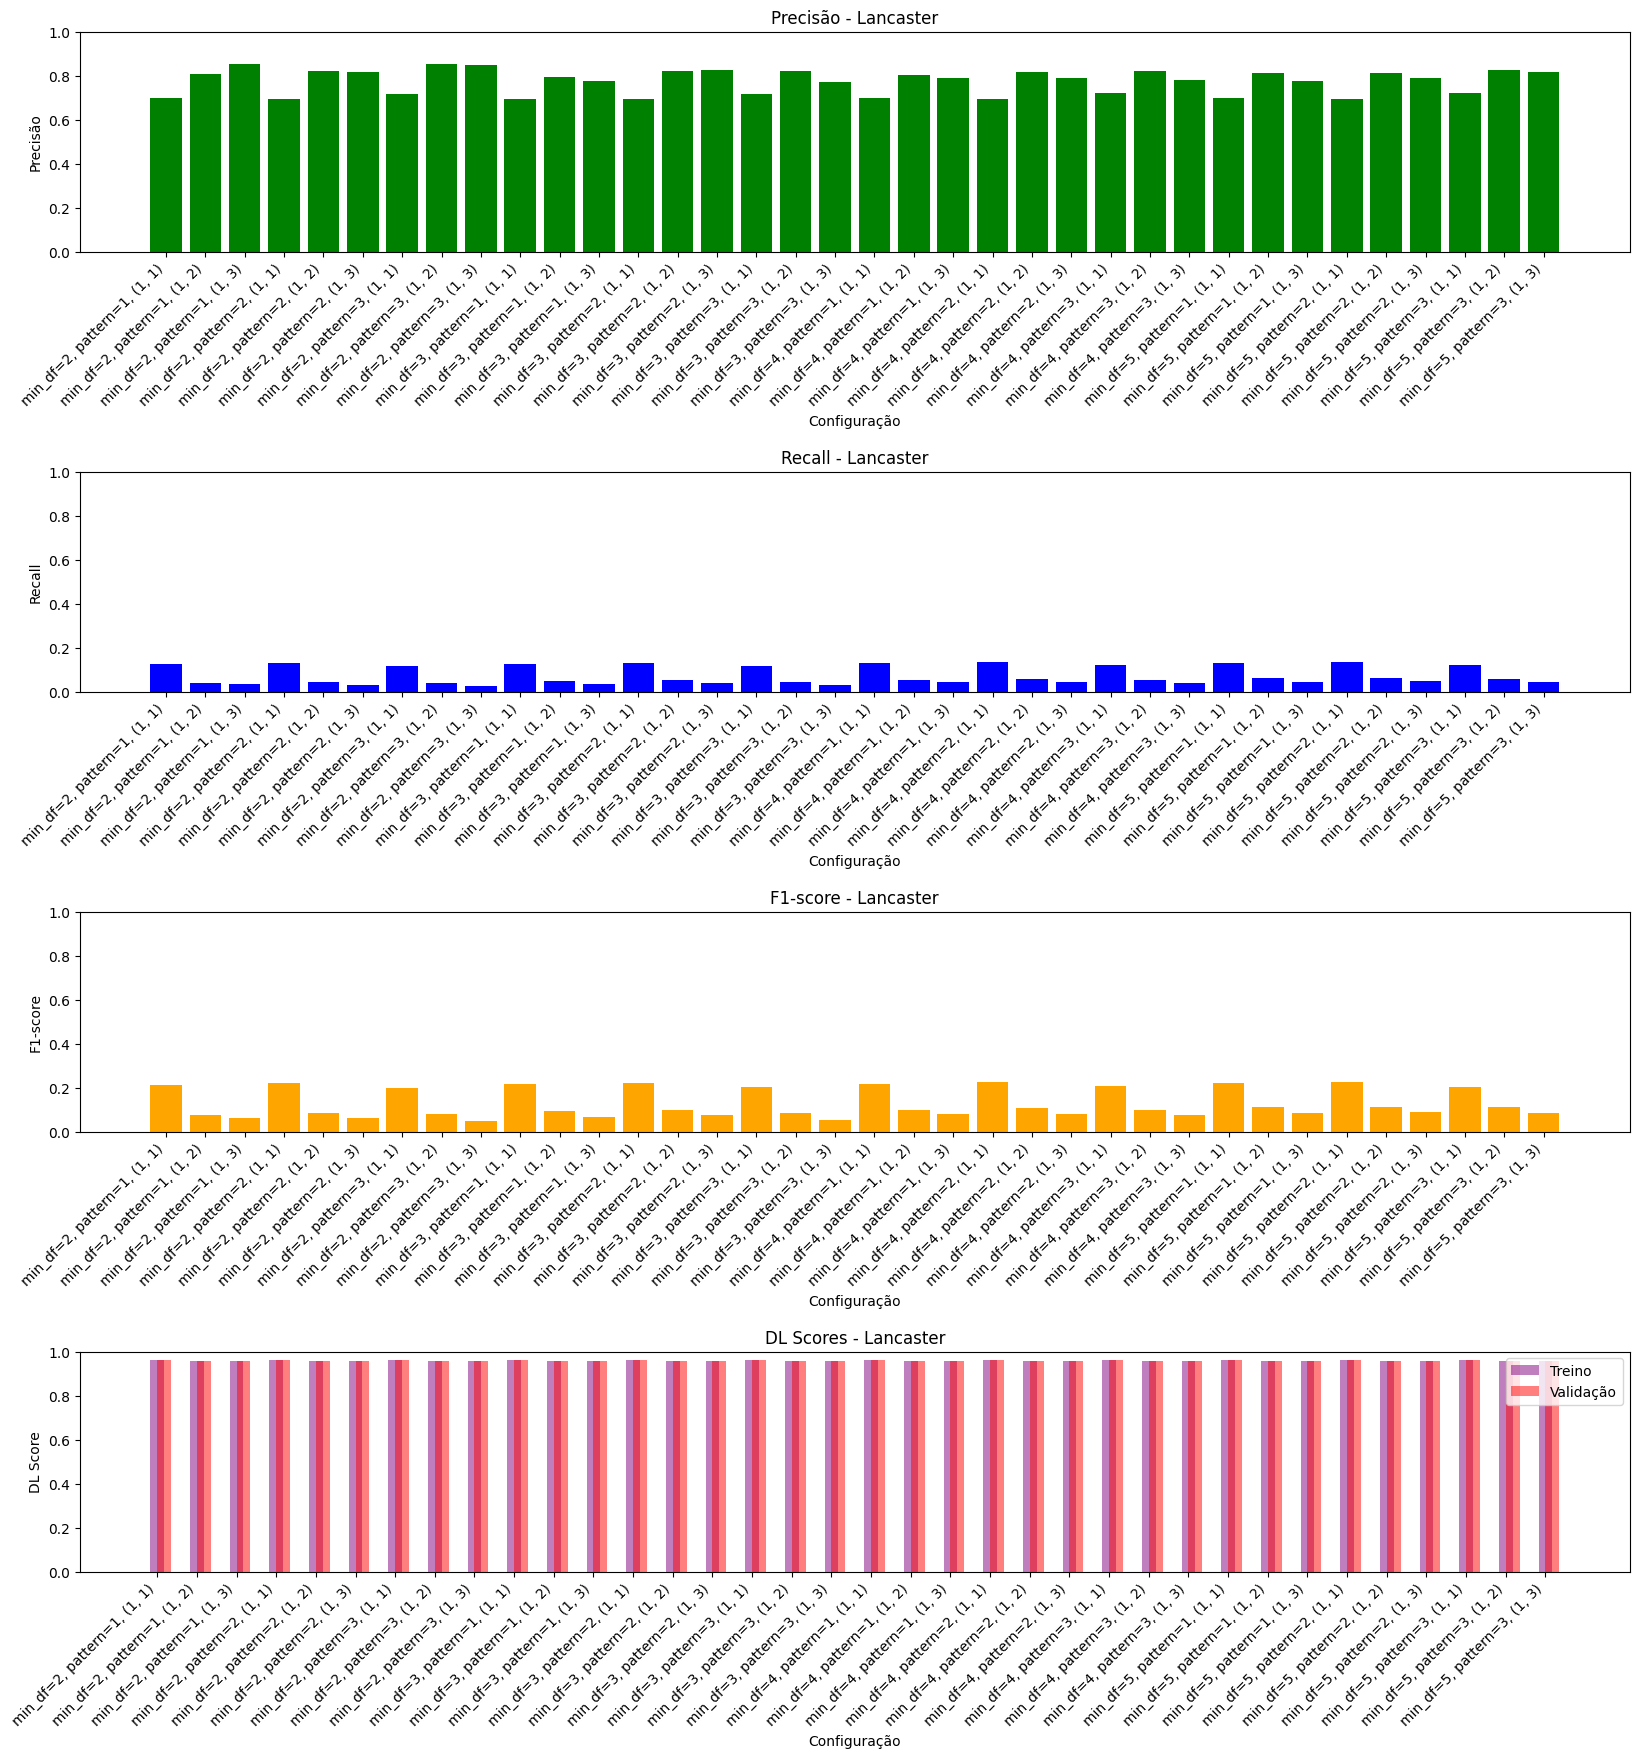

In [42]:
dicionario_limpos_n = pickle.load(open("ficheirosPickel/dicionario_limpos_neg_dl.p", "rb"))
dicionario_porter_n = pickle.load(open("ficheirosPickel/dicionario_porter_neg_dl.p", "rb"))
dicionario_snowball_n = pickle.load(open("ficheirosPickel/dicionario_snowball_neg_dl.p", "rb"))
dicionario_lancaster_n = pickle.load(open("ficheirosPickel/dicionario_lancaster_neg_dl.p", "rb"))

# Criar tabela e gráfico para cada stemmer
criar_tabela_metricas(dicionario_limpos_n, "Limpos")
criar_tabela_metricas(dicionario_porter_n, "Porter")
criar_tabela_metricas(dicionario_snowball_n, "Snowball")
criar_tabela_metricas(dicionario_lancaster_n, "Lancaster")

Tendo agora aplicado a função LogisticRegression, podemos analisar os dados para ver que configuração de vetorização se deve usar para criar o vocabulário.
Ao treinar o modelo com diferentes vocabulários, conseguimos retirar varios valores de precisão, de recall, do F1-score, e o score do modelo na parte do treino e da validação.

Tendo uma alta precisão, significa que quando o modelo classifica uma critica como -1 (não muito boa, ou não muito má), é provavel que esse critica esteja bem classificada.

Ter um Recall alto, significa que existe poucos falsos negativos, ou seja, classificar criticas como muito boas ou muito más quando não são.

Ter um bom F1-score, significa que existe um equilibro entre a precisão e o recall, alcança-se esse equilibro tendo um valor alto, perto de 1

Vendo o score do modelo, sabe-se que quando maior o valor melhor foi o ajuste do modelo aos dados.

Tem que se ter atanção que, por vezes o modelo pode entrar em sobreaprendizagem, podendo verificar através do score do treino e da validação, caso o de treino for significativamente maior ao de teste ou validação, é por que entra em sobreaprendizagem. Para alem disso, ter um precisão de 100% também pode indicar sobreaprendizagem.

Olhando para os resultados da analise do modelo onde se aplicou diversos vocabulários e documentos, onde se aplicou stemmers diferentes, e na vetorização, hiperparametros diferentes, podemos procurar qual os hiperparametros melhores.

Analisando primeiro as diferenças de scores, de treino e de validação, para verificar se existe sobreaprendizagem, não encontramos nenhum, todos os scores variam entre 0.94 e 0.95 em todas as configurações.

Olhando para as tabelas, verifica-se que existe sempre mais precisão do que recall, sendo que quando se esta a classificar como muito boa, o recall é sempre abaixo de 0.1, por isso analisou-se as configurações com os resultados da classificação de muito más.

Para agora escolher a configuração a usar, temos que analisar os dados em relação as configurações. Verificou-se que quando se tinha uma precisão mais alta, o recall era abaixo de 0.1, sendo que aqui é preferivel classificar bem as criticas que são muito más, uma boa precisão é mais importante, pois significa que tem menos falsos positivo, contudo, procura-se um recall acima de 0.1:




Tabela de Métricas - Limpos

| Configuração                  | Precisão     | Recall      | F1-score     | DL Score Treino     | DL Score Validação     |
|-------------------------------|--------------|-------------|--------------|---------------------|------------------------|
| min_df=2, pattern=1, (1, 1)   | 0.695238     | 0.102241    | 0.178266     | 0.96037             | 0.959621               |
| min_df=2, pattern=2, (1, 1)   | 0.706422     | 0.107843    | 0.18712      | 0.96037             | 0.959861               |
| min_df=3, pattern=1, (1, 1)   | 0.698113     | 0.103641    | 0.180488     | 0.96043             | 0.959681               |
| min_df=4, pattern=2, (1, 1)   | 0.696429     | 0.109244    | 0.188862     | 0.96049             | 0.959801               |
| min_df=5, pattern=2, (1, 1)   | 0.696429     | 0.109244    | 0.188862     | 0.96076             | 0.959801               |
| ----------------------------- | ------------ | ----------- | ------------ | ------------------- | ---------------------- |

Sem utilizar stemmer, escolheu-se a configuração min_df=2, pattern=2, (1, 1).

Tabela de Métricas - Porter

| Configuração                  | Precisão     | Recall      | F1-score     | DL Score Treino     | DL Score Validação     |
|-------------------------------|--------------|-------------|--------------|---------------------|------------------------|
| min_df=3, pattern=1, (1, 1)   | 0.732283     | 0.130252    | 0.221165     | 0.96103             | 0.960701               |
| min_df=3, pattern=2, (1, 1)   | 0.726562     | 0.130252    | 0.220903     | 0.96091             | 0.960641               |
| min_df=3, pattern=3, (1, 1)   | 0.724138     | 0.117647    | 0.20241      | 0.96019             | 0.960281               |
| min_df=4, pattern=3, (1, 1)   | 0.732759     | 0.119048    | 0.204819     | 0.96025             | 0.960401               |
| min_df=5, pattern=3, (1, 1)   | 0.731092     | 0.121849    | 0.208884     | 0.96022             | 0.960461               |


COm o porter, escolheu-se a configuração min_df=3, pattern=1, (1, 1), tendo um maior equilibrio entre a precisão e o recall.

Tabela de Métricas - Snowball

| Configuração                  | Precisão     | Recall      | F1-score     | DL Score Treino     | DL Score Validação     |
|-------------------------------|--------------|-------------|--------------|---------------------|------------------------|
| min_df=2, pattern=1, (1, 1)   | 0.72         | 0.12605     | 0.214541     | 0.96103             | 0.960461               |
| min_df=2, pattern=2, (1, 1)   | 0.722222     | 0.127451    | 0.216667     | 0.96091             | 0.960521               |
| min_df=3, pattern=2, (1, 1)   | 0.724409     | 0.128852    | 0.218787     | 0.961               | 0.960581               |
| min_df=4, pattern=2, (1, 1)   | 0.732824     | 0.134454    | 0.227219     | 0.96097             | 0.960821               |
| min_df=4, pattern=3, (1, 1)   | 0.721739     | 0.116246    | 0.200241     | 0.96034             | 0.960221               |
| min_df=5, pattern=1, (1, 1)   | 0.732824     | 0.134454    | 0.227219     | 0.96109             | 0.960821               |
| min_df=5, pattern=2, (1, 1)   | 0.727273     | 0.134454    | 0.22695      | 0.96112             | 0.960761               |


Com o snowball, escolheu-se a configuração min_df=4, pattern=2, (1, 1).


Tabela de Métricas - Lancaster

| Configuração                  | Precisão     | Recall      | F1-score     | DL Score Treino     | DL Score Validação     |
|-------------------------------|--------------|-------------|--------------|---------------------|------------------------|
| min_df=2, pattern=3, (1, 1)   | 0.715517     | 0.116246    | 0.2          | 0.95971             | 0.960161               |
| min_df=3, pattern=3, (1, 1)   | 0.717949     | 0.117647    | 0.202166     | 0.95962             | 0.960221               |
| min_df=4, pattern=3, (1, 1)   | 0.722689     | 0.120448    | 0.206483     | 0.95974             | 0.960341               |
| min_df=5, pattern=3, (1, 1)   | 0.720339     | 0.119048    | 0.204327     | 0.95971             | 0.960281               |


Com o lancaster, escolheu-se a configuração min_df=4, pattern=3, (1, 1).

Comparar agora o melhor dos stemmers

|---------|------------------------------|------------|-----------|------------|----------|----------|
|Limpos   | min_df=2, pattern=2, (1, 1)   | 0.706422     | 0.107843    | 0.18712      | 0.96037             | 0.959861               |
|Porter   | min_df=3, pattern=1, (1, 1)   | 0.732283     | 0.130252    | 0.221165     | 0.96103             | 0.960701               |
|Snowball | min_df=4, pattern=2, (1, 1)   | 0.732824     | 0.134454    | 0.227219     | 0.96097             | 0.960821               |
|Lancaster| min_df=4, pattern=3, (1, 1)   | 0.722689     | 0.120448    | 0.206483     | 0.95974             | 0.960341               |

Os melhores valores de precisão estao no Porter e no snowball, tendo o snowball os valores ligeiramente mais altos. Escolhendo então esse.

Vendo a configuração na tabela de quando se esta a classificar as criticas como muito boas e muit mas, os resultados da configuração sao os seguinte:

|            | Configuração                | Precisão | Recall   | F1-score | DL Score Treino | DL Score Validação |
|------------|-----------------------------|----------|----------|----------|-----------------|--------------------|
| Muito Boas | min_df=4, pattern=2, (1, 1) | 0.732824 | 0.134454 | 0.227219 | 0.96097         | 0.960821           |
| Muito Más  | min_df=4, pattern=2, (1, 1) | 0.732824 | 0.134454 | 0.227219 | 0.96097         | 0.960821           |

Steammer: Snowball
Configuração do TfidfVectorizer: min_df=4, pattern=2, n-gramas (1, 1) Stop_Words='English'

##### Encontrar os melhores hipreparametros para o classificador

O LogisticRegression tem alguns hiperparametros que podem ser alterados para melhorar o modelo, sendo eles:

- penalty: Regularização, para minorar a sobreaprendizagem, sendo que o valor l1 é a regularização de Lasso e o valor l2 é a regularização de Ridge;
- C: Inverso da força de regularização, sendo que quanto maior o valor, menor a regularização;
- solver: Método de otimização, que podem ser: ‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’, sendo que se utiliza o liblinear para problemas binarios;
- muilti_class: Método para problemas multiclasse, sendo que se utiliza o ovr para problemas binarios;
- max_iter: Número máximo de iterações para convergência.

In [43]:
#importar bibliotecas
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, precision_recall_curve, roc_curve

''' 
Função para treinar e testar o modelo com diferentes hiperparametros.
Atributos: 
    - X_train: conjunto de documentos de treino;
    - X_test: conjunto de documentos de teste;
    - y_train: classes de treino;
    - y_test: classes de teste;
    - c: valor de C;
    - penalty: tipo de regularização.
Return:
    - score_crossVal: score do cross validation;
    - erros: erros;
    - score_modelo: score do modelo;
    - dist_crp: distancia da curva precisão/recall;
    - ponto_ideal_crp_prec: ponto ideal da curva precisão/recall;
    - ponto_ideal_crp_rec: ponto ideal da curva precisão/recall;
    - dist_roc: distancia da curva roc;
    - ponto_ideal_roc_fpr: ponto ideal da curva roc;
    - ponto_ideal_roc_tpr: ponto ideal da curva roc.
'''

def linearRegression_3(X_train, X_test, y_train, y_test, c, penalty):
    print("Linear Regression")

    lr = LogisticRegression(C=c, max_iter=5000, penalty=penalty, solver='liblinear', tol=1e-2).fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    # Ver o score atraves do cross validation utilizando 5 folds
    score_crossVal = cross_val_score(lr, X_train, y_train, cv=5)
    # Ver os erros
    erros = np.sum(y_test != y_pred)
    # Ver o score do modelo
    score_modelo = lr.score(X_test, y_test)
    # Ver a curva precisão/recall
    dcf = lr.decision_function(X_test)
    prec, rec, _ = precision_recall_curve(y_test, dcf)
    #calcular a distancia entre o ponto ideal e o ponto da curva
    pontos = np.array([prec, rec])
    dist_crp_arr = np.sqrt(np.sum((pontos - np.array([[1.0], [1.0]]))**2, axis=0))
    idx_min_crp = np.argmin(dist_crp_arr)
    dist_crp = dist_crp_arr[idx_min_crp]
    ponto_ideal_crp  = pontos[:, idx_min_crp]
    # Ver a curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, dcf)
    #calcular a distancia entre o ponto ideal e o ponto da curva
    pontos = np.array([fpr, tpr])
    dist_roc_arr = np.sqrt(np.sum((pontos - np.array([[0.0], [1.0]]))**2, axis=0))
    idx_min_roc = np.argmin(dist_roc_arr)
    dist_roc = dist_roc_arr[idx_min_roc]
    ponto_ideal_roc = pontos[:, idx_min_roc]
    
    CM = confusion_matrix(y_test, y_pred)
    print("Matriz de Confusão:")
    print(CM)
    
    if(CM[1][1] + CM[0][1]) != 0:
        precisao = CM[1][1] / (CM[1][1] + CM[0][1])
    else:
        precisao = 0.0

    if(CM[1][1] + CM[1][0]) != 0:
        recall = CM[1][1] / (CM[1][1] + CM[1][0])
    else:
        recall = 0.0

    print("precisão:", precisao)
    print("recall:", recall)

    return score_crossVal, erros, score_modelo, dist_crp, ponto_ideal_crp[0], ponto_ideal_crp[1], dist_roc, ponto_ideal_roc[0], ponto_ideal_roc[1]

Para chegar a uma conclusão de qual são os melhores parametros, vai se ver qual os melhores parametros para cada métrica.

In [44]:
'''
Função para aplicar a função linearRegression_3 com diferentes hiperparametros e guardar os melhores resultados por métrica.
Atributos: 
    - X_train: conjunto de documentos de treino;
    - X_test: conjunto de documentos de teste;
    - y_train: classes de treino;
    - y_test: classes de teste.
Return:
    - best_results: dicionário com os melhores resultados por métrica.
'''

def teste_hiper_linearRegression(X_train, X_test, y_train, y_test):
    print("Linear Regression")

    cList = [0.1, 1, 10, 50, 100, 150, 200]
    penaltyList = ['l1', 'l2']

    best_results = {
        'score_crossVal': {'value': -1, 'C': None, 'penalty': None},
        'erros': {'value': float('inf'), 'C': None, 'penalty': None},
        'score_modelo': {'value': -1, 'C': None, 'penalty': None},
        'curva_precisao_recall': {'dist': 1, 'prec': -1, 'rec': -1, 'C': None, 'penalty': None},
        'curva_roc': {'dist': 1, 'fpr': -1, 'tpr': -1, 'C': None, 'penalty': None},
    }

    for c in cList:
        for penalty in penaltyList:
            score_crossVal, erros, score_modelo, dist_crp, ponto_ideal_crp_prec, ponto_ideal_crp_rec, dist_roc, ponto_ideal_roc_fpr, ponto_ideal_roc_tpr = linearRegression_3(X_train, X_test, y_train, y_test, c, penalty)

            # Comparar e atualizar os melhores resultados para cada métrica
            if np.mean(score_crossVal) > best_results['score_crossVal']['value']:
                best_results['score_crossVal'] = {'value': np.mean(score_crossVal), 'C': c, 'penalty': penalty}
            if erros < best_results['erros']['value']:
                best_results['erros'] = {'value': erros, 'C': c, 'penalty': penalty}
            if score_modelo > best_results['score_modelo']['value']:
                best_results['score_modelo'] = {'value': score_modelo, 'C': c, 'penalty': penalty}
            if dist_crp < best_results['curva_precisao_recall']['dist']:
                best_results['curva_precisao_recall'] = {'dist': dist_crp, 'prec': ponto_ideal_crp_prec, 'rec': ponto_ideal_crp_rec, 'C': c, 'penalty': penalty}
            if dist_roc < best_results['curva_roc']['dist']:
                best_results['curva_roc'] = {'dist': dist_roc, 'fpr': ponto_ideal_roc_fpr, 'tpr': ponto_ideal_roc_tpr, 'C': c, 'penalty': penalty}
            

            # Imprimir os melhores resultados e seus hiperparâmetros associados
            print("Melhores resultados:")
            print("Score Cross-Validation:", best_results['score_crossVal']['value'], "C:", best_results['score_crossVal']['C'], "Penalty:", best_results['score_crossVal']['penalty'])
            print("Erros:", best_results['erros']['value'], "C:", best_results['erros']['C'], "Penalty:", best_results['erros']['penalty'])
            print("Score do Modelo:", best_results['score_modelo']['value'], "C:", best_results['score_modelo']['C'], "Penalty:", best_results['score_modelo']['penalty'])
            print("Distância Precisão/Recall:", best_results['curva_precisao_recall']['dist'], "Precisão:", best_results['curva_precisao_recall']['prec'], "Recall:", best_results['curva_precisao_recall']['rec'], "C:", best_results['curva_precisao_recall']['C'], "Penalty:", best_results['curva_precisao_recall']['penalty'])
            print("Distância ROC:", best_results['curva_roc']['dist'], "FPR:", best_results['curva_roc']['fpr'], "TPR:", best_results['curva_roc']['tpr'], "C:", best_results['curva_roc']['C'], "Penalty:", best_results['curva_roc']['penalty'])

    return best_results




In [45]:
''' 
Função para fazer a vetorização dos documentos de treino com o stemmer e a configuração escolhida.
Guardar o vocabulário e os dados de treino e de teste.
'''
def vetorizar_criar_voc_com_parametros():
    #documentos porter
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    docs = np.array(docs)
    y = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTrain])

    # Criar divisões de treinamento e teste
    X_train, X_test, y_train, y_test = train_test_split(docs, y, test_size=1/3, stratify=y)


    # Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)

    vocabulario = vectorizer.get_feature_names_out()
    
    #save vocabulario e X_train_t e X_val_t
    vect = {'vocabulario': vocabulario, 'X_train_t': X_train_t, 'X_test_t': X_test_t, 'y_train': y_train, 'y_test': y_test}
    pickle.dump(vect, open("ficheirosPickel/vocabulario_X_train_t_X_test_t.p", "wb"))


In [46]:
# vetorizar_criar_voc_com_parametros()

In [47]:
vect = pickle.load(open("ficheirosPickel/vocabulario_X_train_t_X_test_t.p", "rb"))
vocabulario = vect['vocabulario']                            
X_train_t = vect['X_train_t']
X_test_t = vect['X_test_t']
y_train = vect['y_train']
y_test = vect['y_test']
# teste_hiper_linearRegression(X_train_t, X_test_t, y_train, y_test)

Apos testar os hiperparametros com varias métricas, temos que os melhores parametros focando em cada métrica são:

'score_crossVal': {'value': 0.93614, 'C': 1, 'penalty': 'l2'}
'erros': {'value': 1598, 'C': 1, 'penalty': 'l2'}
'score_modelo': {'value': 0.93608, 'C': 1, 'penalty': 'l2'}
'curva_precisao_recall': {'dist': 0.79825, 'prec': 0.31457, 'rec': 0.59086, 'C': 1,  'penalty': 'l2'}
'curva_roc': {'dist': 0.30239, 'fpr': 0.22564, 'tpr': 0.79869, 'C': 1, 'penalty': 'l2'}

Verifica-se que o melhor valor dos parametros são C=1 e penalty=l2

Faz se então um ultimo treino e teste do modelo com os hiperparametros encontrados, e com os dados de treino e teste todos para analisar o modelo.

In [48]:
''' 
Função para limpar os documentos de teste com o stemmer e guardar os documentos limpos.
'''
def limpar_teste_b1():
    Docs_teste = [beerDictTest[idx]['review'] for idx in beerDictTest]
    Docs_teste_limpos = limpar_caracteres_tags(Docs_teste)
    snowball = SnowballStemmer("english")
    X_test_limpos_snowball = stemming(Docs_teste_limpos, snowball)
    pickle.dump(X_test_limpos_snowball, open("ficheirosPickel/documentos_teste_snowball.p", "wb"))


In [49]:
limpar_teste_b1()

In [50]:
'''
Função para fazer o treino e teste final do classificador binario com os hiperametros encontrados.
Atributos: 
    - muito_boa: booleano para saber se se esta a classificar criticas muito boas ou muito más.
'''
def classificacao_Binaria_1_Discriminante_Logistico(muito_boa):
    
    #Passo 1: Carregar os dados de treino, estes já esão limpos com o porter
    X_train_limpos_porter = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    X_train = np.array(X_train_limpos_porter)
    if muito_boa:
        y_train = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTrain])
    else:
        y_train = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) <= 2 else -1 for idx in beerDictTrain])
    
    #Passo 2: Carregar os dados de teste
    X_test_limpos_porter = pickle.load(open("ficheirosPickel/documentos_teste_snowball.p", "rb"))
    X_test = np.array(X_test_limpos_porter)
    if muito_boa:
        y_test = np.array([1 if int(beerDictTest[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTest])
    else:
        y_test = np.array([1 if int(beerDictTest[idx]['overall'].split('/')[0]) <= 2 else -1 for idx in beerDictTest])

    
    print("Tamanho do conjunto de treino:", len(X_train))
    print("Tamanho do conjunto de teste:", len(X_test))
    #ver quanto sda classe 1 e da classe -1
    plot_classes(y_train)
    plot_classes(y_test)
    
    #Passo 3: Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)
    
    #armazenar o vocabulario e o vetorizador e os dados de treino e teste
    vect = {'vocabulario': vectorizer.get_feature_names_out(), 'X_train_t': X_train_t, 'X_test_t': X_test_t, 'y_train': y_train, 'y_test': y_test}
    
    if(muito_boa):
        pickle.dump(vect, open("ficheirosPickel/vetorizacaoConcluida_boa.p", "wb"))
    else:
        pickle.dump(vect, open("ficheirosPickel/vetorizacaoConcluida_ma.p", "wb"))
    
    #ver o tamanho do vocabulario
    vocabulario = vectorizer.get_feature_names_out()
    print("Tamanho do vocabulario:", len(vocabulario))
    
    #Passo 4: Treinar o modelo
    lr = LogisticRegression(C=1, max_iter=5000, penalty='l2', solver='liblinear', tol=1e-2).fit(X_train_t, y_train)
    
    #Passo 5: Testar o modelo
    y_pred = lr.predict(X_test_t)
    
    #Passo 6: Ver os erros
    erros = np.sum(y_test != y_pred)
    
    #Passo 7: Ver o score do modelo
    score_modelo = lr.score(X_test_t, y_test)
    
    #ver o score do treino
    score_treino = lr.score(X_train_t, y_train)
    
    #Passo 8: Matriz de confusão
    matriz_confusao = confusion_matrix(y_test, y_pred)
    

    #Passo 9: calcular a precisão, recall e f1-score atraves da matriz de confusão
    precisao = matriz_confusao[0][0] / (matriz_confusao[0][0] + matriz_confusao[0][1])
    recall = matriz_confusao[0][0] / (matriz_confusao[0][0] + matriz_confusao[1][0])
    f1_score = 2 * (precisao * recall) / (precisao + recall)

    dcf = lr.decision_function(X_test_t)

    #Passo 10: Ver a curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, dcf) 
    plt.plot(fpr,tpr, color='skyblue', label='Curva ROC')
    
    p1 = matriz_confusao[0,1]/(matriz_confusao[0,1] + matriz_confusao[0,0])
    p2 = matriz_confusao[1,1]/(matriz_confusao[1,1] + matriz_confusao[1,0])

    plt.plot(p1, p2, 'o', color='cadetblue', label='Ponto Operacional')
    
    plt.title('Curva ROC e Ponto Operacional')
    plt.ylabel('Taxa de True Positive')
    plt.xlabel('Taxa de False Positive')
    plt.legend()
    plt.text(p1+0.06, p2-0.02, '(' + str(np.round(p1,3)) + ', ' + str(np.round(p2,3)) + ')' )
    plt.axis('scaled')
    plt.show()
    
    #Passo 11: Fazer print dos resultados
    
    if(muito_boa):
        print("Resultados para classificar criticas muito boas:")
    else:
        print("Resultados para classificar criticas muito más:")
        
    print("Erros:", erros)
    print("--------------------")
    print("Score do Modelo:", score_modelo)
    print("Score do Treino:", score_treino)
    print("--------------------")
    print("Matriz de Confusão:")
    print(matriz_confusao)
    print("--------------------")
    print("Precisão:", precisao)
    print("Recall:", recall)
    print("F1-score:", f1_score)
    print("--------------------")

    
    #ver os pesos do modelo com os vocabularios associados
    w= lr.coef_.ravel()
    idxv=np.argsort(w)
           
    print("Palavras com menor peso:")
    for i in idxv[:30]:
        print('(%.2f) %s'%(w[i],vocabulario[i]))
    print("--------------------")
    
    print("Palavras com maior peso:")
    for i in idxv[-30:]:
        print('(%.2f) %s'%(w[i],vocabulario[i]))
    print("--------------------")  
    
    #ir buscar as keys das criticas
    keys = list(beerDictTest.keys())
    
    #ver 5 criticas bem classificadas do conjunto de teste original e o seu overall
    print("5 criticas bem classificadas:")
    #ver criticas classificadas na classe 1 e que são da classe 1
    idxs = np.where((y_test == 1) & (y_pred == 1))[0]

    for i in range(5):
        idx = idxs[i]
        item = beerDictTest[keys[idx]]
        print("Critica:", item.get('review'))
        print("Classificação:", item.get('overall'))
        print("Classificação do Modelo:", y_pred[idx])
        print("----------")
    
    print("+++++++++++++++++++++")
    #ver 5 criticas mal classificadas
    print("5 criticas mal classificadas:")
    idxs = np.where(y_test != y_pred)[0]
    for i in range(5):
        idx = idxs[i]
        print("Critica:", beerDictTest[keys[idx]].get('review'))
        print("Classificação:", beerDictTest[keys[idx]].get('overall'))
        print("Classificação do Modelo:", y_pred[idx])
        print("----------")
        
    

Tamanho do conjunto de treino: 75000
Tamanho do conjunto de teste: 25000
Total de Críticas: 75000
Total de Críticas 1: 5052
Total de Críticas -1: 69948


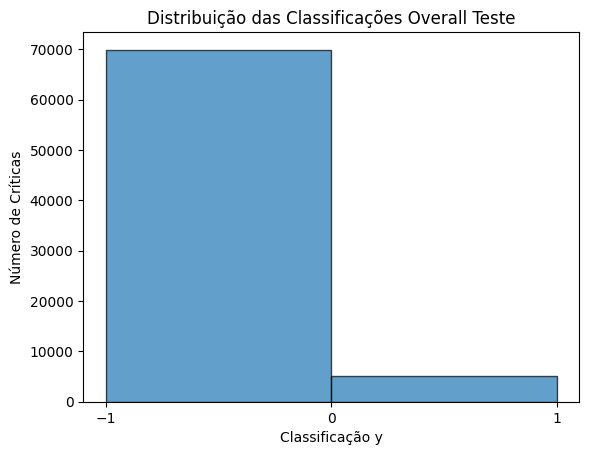

Total de Críticas: 25000
Total de Críticas 1: 1111
Total de Críticas -1: 23889


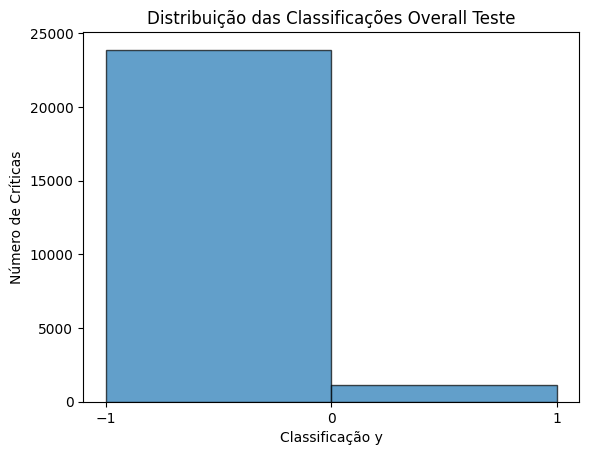

Tamanho do vocabulario: 12836


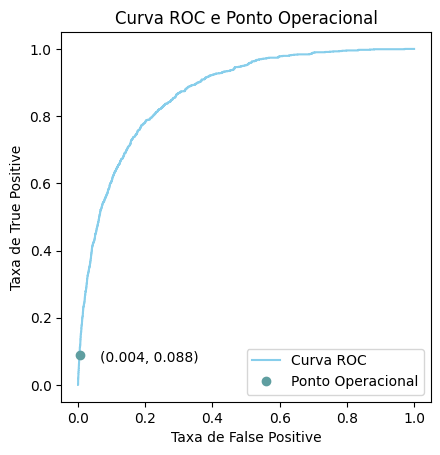

Resultados para classificar criticas muito boas:
Erros: 1117
--------------------
Score do Modelo: 0.95532
Score do Treino: 0.9399866666666666
--------------------
Matriz de Confusão:
[[23785   104]
 [ 1013    98]]
--------------------
Precisão: 0.9956465318765959
Recall: 0.9591499314460844
F1-score: 0.9770575307576972
--------------------
Palavras com menor peso:
(-4.08) bad
(-3.79) pretti
(-2.85) lack
(-2.67) bit
(-2.55) wateri
(-2.50) beig
(-2.31) weird
(-2.31) decent
(-2.28) noth
(-2.24) odd
(-2.24) harsh
(-2.20) clear
(-2.19) light
(-2.03) strang
(-2.02) wheat
(-1.97) littl
(-1.95) averag
(-1.90) flavour
(-1.90) bland
(-1.84) corn
(-1.81) fair
(-1.79) head
(-1.77) solid
(-1.75) unfortun
(-1.72) sort
(-1.68) doesnt
(-1.64) white
(-1.63) soapi
(-1.59) howev
(-1.59) weak
--------------------
Palavras com maior peso:
(2.19) savor
(2.24) exquisit
(2.25) sip
(2.26) updat
(2.31) everyth
(2.37) growler
(2.37) abt
(2.43) super
(2.54) truli
(2.55) masterpiec
(2.63) love
(2.83) smooth
(2.85)

In [51]:
#classificar criticas muito boas
classificacao_Binaria_1_Discriminante_Logistico(True)

Podemos ver que as criticas mal classificadas como esta: 

Critica: "You might notice that Louisiana beers (dixi, acadiana) tend to have a cider taste to them somehow.  I dont know if they keep them in cider barrels or what, but Abita typicaly doesnt have that distinction.  This particular seasonal abita beer (after fall fest and before red ale) does have that distinction and is particularly good during christmas time.  Its aftertaste tastes like you drank out of a can, but the initial taste makes up for that fault.  I prefer to drink it with something sweet like a desert, but it is definatly not something I would like to drink all day.  Do give it a shot." 

Não tem muitas palavras que sugerem que é uma boa critica, o critico limita-se a descrever alguns aspetos.


Tamanho do conjunto de treino: 75000
Tamanho do conjunto de teste: 25000
Total de Críticas: 75000
Total de Críticas 1: 3346
Total de Críticas -1: 71654


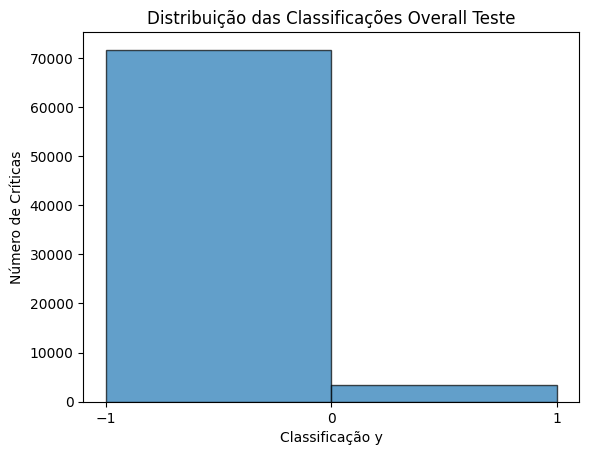

Total de Críticas: 25000
Total de Críticas 1: 2429
Total de Críticas -1: 22571


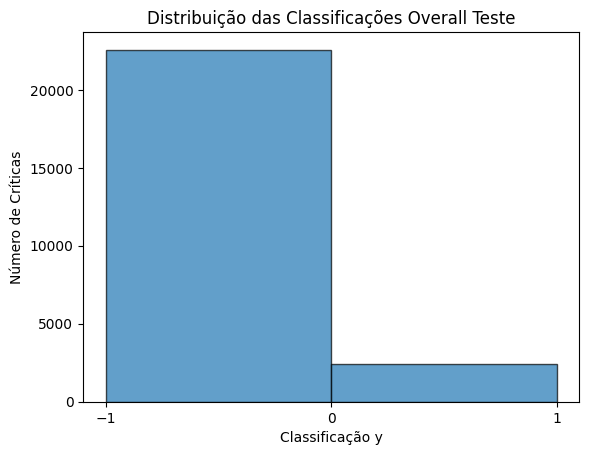

Tamanho do vocabulario: 12836


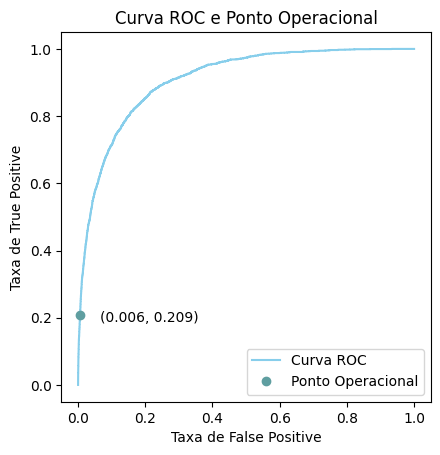

Resultados para classificar criticas muito más:
Erros: 2051
--------------------
Score do Modelo: 0.91796
Score do Treino: 0.9639066666666667
--------------------
Matriz de Confusão:
[[22442   129]
 [ 1922   507]]
--------------------
Precisão: 0.9942847016082584
Recall: 0.921113117714661
F1-score: 0.9563012677106638
--------------------
Palavras com menor peso:
(-6.02) nice
(-4.31) citrus
(-3.69) chocol
(-3.66) solid
(-3.57) smooth
(-3.47) great
(-3.40) hop
(-3.38) age
(-3.31) tasti
(-3.07) complex
(-2.92) easi
(-2.92) rich
(-2.88) grapefruit
(-2.80) excel
(-2.63) spici
(-2.59) delici
(-2.58) coffe
(-2.57) yeasti
(-2.52) decent
(-2.48) hoppi
(-2.45) refresh
(-2.40) pine
(-2.39) thank
(-2.36) cherri
(-2.35) lagunita
(-2.33) oak
(-2.23) caramel
(-2.22) good
(-2.17) amaz
(-2.15) raisin
--------------------
Palavras com maior peso:
(2.29) suck
(2.35) lager
(2.38) short
(2.54) wast
(2.55) rude
(2.55) veget
(2.56) skunk
(2.59) mess
(2.62) weird
(2.69) yellow
(2.74) horribl
(2.75) stale
(2.8

In [52]:
#classificar criticas muito más
classificacao_Binaria_1_Discriminante_Logistico(False)

Colocando os valores das metricas em tabela:


| Metrica         | Classificar Muito Boas | Classificar Muito Más |
|-----------------|------------------------|-----------------------|
| Erros           | 1117                   | 2051                  |
| Score do Modelo | 0.95532                | 0.91796               |
| Score do Treino | 0.93999                | 0.96391               |
| Precisão        | 0.9996                 | 0.9943                |
| Recall          | 0.9657                 | 0.9211                |
| F1-score        | 0.9591                 | 0.9563                |
| TPositivos      | 23785                  | 22442                 |
| TNegativos      | 98                     | 507                   |
| FPositivos      | 1013                   | 1922                  |
| FNegativos      | 104                    | 129                   |

Comparando o score do treino com o do modelo, a partida o modelo não etraa em sobreaprendizagem, sendo que os valores são  próximos. Verifica-se uma precisão de 0.99 o que pode indicar overfitting.
Existe um numero maior de Falsos Positivos do que Verdadeiros Negativos, o que significa que o modelo esta a classificar praticamente todas as criticas Muito Boas como não o sendo, no caso de classificar criticas muito boas, e as Muito Más como não sendo, no caso de classificar criticas muito más.

Concluindo, este classificador, é um mau classificador.

### Classificador Binário 2 - SVM

O segundo classificador binario a testar vai ser a Maquinas de Vetores de Suporte (SVM).

As SVM vao escolher a fronteira de decisão que maximiza a margem entre as classes, ou seja, a distancia entre a fronteira de decisão e os pontos mais proximos de cada classe.
Os pontos mais proximos da fronteira de decisão são chamados de vetores de suporte. Aqueles que vao ser usados para classificar.
Vai ser necessário definir uma função de Kernel, que vai ser uma questao se experimentar qual a melhor, função esta que vai depender dos dados normais.

Existe o Kernel:
- linear 
- polinomial 
- Gaussian RBF 
- Sigmoidal

Para alem disso existem outros hiperparametros que podem ser alterados, sendo eles:

- C: Este parâmetro controla a força da regularização, sendo inversamente proporcional ao parâmetro de regularização e determina o quão tolerantes os erros de classificação são permitidos no modelo.
- Kernel:Este parâmetro especifica o tipo de função kernel usada para transformar os dados de entrada. As opções incluem "linear", "poly", "rbf" e "sigmoid". O kernel "linear" é adequado para dados linearmente separáveis, enquanto os outros kernels são adequados para dados não linearmente separáveis.
- Degree:Este parâmetro é usado somente quando o kernel é "poly" e especifica o grau da função polinomial.
- Gamma: Este parâmetro é usado somente quando o kernel é "rbf", "poly" ou "sigmoid" e controla a complexidade do modelo. Um valor de gamma alto resulta numa menor complexidade e um valor baixo resulta em numa complexidade mais elevada.
- Coef0: Este parâmetro é usado somente quando o kernel é "poly" ou "sigmoid" e controla o offset na função kernel.
- Max_iter: Este parâmetro especifica o número máximo de iterações para o algoritmo de otimização.

Para este problema de classificação vai se testar o kernel linear apenas, devido ao tempo de computação que os outros kernels demoram.
Vai ser usado os documentos já limpos onde foi aplicado o stemmer porter e vai se fazer a vetorização com os parametros min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,2), tal como na refressão linar.


In [70]:
''' 
Função para calcular as metricas do modelo SVM.
Atributos: 
    - svm: modelo SVM;
    - topScore: score do cross validation;
    - par: parametros do modelo;
    - y_test: classes de teste;
    - X_test_t: documentos de teste vetorizados;
    - X_train_t: documentos de treino vetorizados;
    - y_train: classes de treino;
    - y_pred: classes previstas.
Return:
    - score_modelo: score do modelo;
    - erros: numero de erros;
    - score_treino: score do treino;
    - precisao: precisao;
    - recall: recall;
    - f1_score: f1-score;
    - p1: ponto 1 da curva ROC;
    - p2: ponto 2 da curva ROC.
'''

def calcular_metricas_svm(svm, topScore, par, y_test, X_test_t, X_train_t, y_train, y_pred):
    
    #calcular as métricas
    erros=np.sum(y_test!=y_pred)
    score_modelo=svm.score(X_test_t, y_test)
    score_treino=svm.score(X_train_t, y_train)
    matriz_confusao=confusion_matrix(y_test, y_pred)
    precisao=matriz_confusao[0][0]/(matriz_confusao[0][0]+matriz_confusao[0][1])
    recall=matriz_confusao[0][0]/(matriz_confusao[0][0]+matriz_confusao[1][0])
    f1_score=2*(precisao*recall)/(precisao+recall)
    
    dcf = svm.decision_function(X_test_t)
    
    #ver a curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, dcf)
    plt.plot(fpr,tpr, color='skyblue', label='Curva ROC')
    
    p1 = matriz_confusao[0,1]/(matriz_confusao[0,1] + matriz_confusao[0,0])
    p2 = matriz_confusao[1,1]/(matriz_confusao[1,1] + matriz_confusao[1,0])
    
    plt.plot(p1, p2, 'o', color='cadetblue', label='Ponto Operacional')
    
    plt.title('Curva ROC e Ponto Operacional')
    plt.ylabel('Taxa de True Positive')
    plt.xlabel('Taxa de False Positive')
    plt.legend()
    plt.text(p1+0.06, p2-0.02, '(' + str(np.round(p1,3)) + ', ' + str(np.round(p2,3)) + ')' )
    plt.axis('scaled')
    plt.grid(visible=True)
    plt.show()
    
    #mostrar os dados
    print('% de acertos na validação:', topScore)
    print('score de treino:', score_treino)
    print('score de teste:', score_modelo)
    print(f'Parametros escolhidos:C={par[0]}, penalty={par[1]}')
    print("--------------------")
    
    print('erros:', erros)
    print("--------------------")
    
    print('matriz de confusão:')
    print(matriz_confusao)
    print("--------------------")
    
    print('precisão:', precisao)
    print('recall:', recall)
    print('f1-score:', f1_score)
    print("--------------------")
    print("--------------------")
        
    return score_modelo, erros, score_treino, precisao, recall, f1_score, p1, p2
    

Começar por procurar os melhores parametros, escolher o o C e o penalty.

In [ ]:
from sklearn.svm import SVC, LinearSVC

'''
Função que vai testar os diferentes valores de C e penalty e escolher os melhores parametros através do score.
Atributos: 
    - X_train_t: documentos de treino vetorizados;
    - X_test_t: documentos de teste vetorizados;
    - y_train: classes de treino;
    - y_test: classes de teste;
    - muito_boa: booleano para saber se se esta a classificar criticas muito boas ou muito más.
Return:
    - par: melhores parametros do modelo.
'''

def svm_escolher_melhor_par(X_train_t, X_test_t, y_train, y_test, muito_boa):
    X_tt, X_val, y_tt, y_val = train_test_split(X_train_t, y_train, test_size=1/3, stratify=y_train)

    topScore=0

    cList=[0.1, 1, 10]
    penaltyList = ['l1', 'l2']

    for c in cList:
            for penalty in penaltyList:
                
                if penalty=='l1':
                    svm = LinearSVC(C=c,penalty=penalty,dual=False)
                else:
                    svm = LinearSVC(C=c,penalty=penalty)
                
                #cross validation
                scores = cross_val_score(svm, X_tt, y_tt, cv=5)
                
                svm.fit(X_tt, y_tt)
                score_treino=svm.score(X_tt, y_tt)
                score = svm.score(X_val, y_val)
                print("--------------------")
                print('score:', score, 'C:', c, 'penalty:', penalty)
                print("score de treino:", score_treino)
                cm = confusion_matrix(y_val, svm.predict(X_val))
                print(cm)
                print("--------------------")
                print("precisão:", cm[0][0]/(cm[0][0]+cm[0][1]))
                print("recall:", cm[0][0]/(cm[0][0]+cm[1][0]))
    
                if score>=topScore:
                    topScore=score
                    par=(c, penalty)


    #voltar a treinar o modelo com os melhores parametros
    if par[1]=='l1':
        svm=LinearSVC(C=par[0], penalty=par[1], dual=False)
    else:
        svm=LinearSVC(C=par[0], penalty=par[1])
    #guardar o modelo em pickel
    if muito_boa:
        pickle.dump(svm, open("ficheirosPickel/svm_boa.p", "wb"))
    else:
        pickle.dump(svm, open("ficheirosPickel/svm_ma.p", "wb"))

    svm.fit(X_train_t, y_train)
    y_pred=svm.predict(X_test_t)
    score_modelo, erros, score_treino, precisao, recall, f1_score, p1, p2 = calcular_metricas_svm(svm, topScore, par, y_test, X_test_t, X_train_t, y_train, y_pred)

    return par

In [59]:
from sklearn.preprocessing import StandardScaler


def procurar_parametros_svm(muito_boa):
    X_train_limpos_snowball = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    X_train = np.array(X_train_limpos_snowball)
    if muito_boa:
        y_train = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTrain])
    else:
        y_train = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) <= 2 else -1 for idx in beerDictTrain])
        
    X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=1/3, stratify=y_train)
        
    
    # # Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)

    
    # scaler = StandardScaler(with_mean=False).fit(X_train_t)
    # X_train_scaled = scaler.transform(X_train_t)
    # X_test_scaled = scaler.transform(X_test_t)


    print(np.sum(y_train==1))
    print(np.sum(y_train==-1))
    par = svm_escolher_melhor_par(X_train_t, X_test_t, y_train, y_test, muito_boa)
    return par
    

3368
46632
--------------------
score: 0.9336413271734565 C: 0.1 penalty: l1
score de treino: 0.933339333393334
[[15536     8]
 [ 1098    25]]
--------------------
precisão: 0.9994853319608852
recall: 0.933990621618372
--------------------
score: 0.9341213175736486 C: 0.1 penalty: l2
score de treino: 0.936819368193682
[[15524    20]
 [ 1078    45]]
--------------------
precisão: 0.9987133299022131
recall: 0.935068064088664


C:\Users\Utilizador\OneDrive - Instituto Superior de Engenharia de Lisboa\00_ISEL\00_5Semestre\AA\venv\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


--------------------
score: 0.9333413331733366 C: 1 penalty: l1
score de treino: 0.9491194911949119
[[15408   136]
 [  975   148]]
--------------------
precisão: 0.9912506433350489
recall: 0.9404870902765061
--------------------
score: 0.9326813463730725 C: 1 penalty: l2
score de treino: 0.9576395763957639


C:\Users\Utilizador\OneDrive - Instituto Superior de Engenharia de Lisboa\00_ISEL\00_5Semestre\AA\venv\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


[[15358   186]
 [  936   187]]
--------------------
precisão: 0.9880339680905815
recall: 0.9425555419172702


C:\Users\Utilizador\OneDrive - Instituto Superior de Engenharia de Lisboa\00_ISEL\00_5Semestre\AA\venv\Lib\site-packages\sklearn\svm\_base.py:1250: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
C:\Users\Utilizador\OneDrive - Instituto Superior de Engenharia de Lisboa\00_ISEL\00_5Semestre\AA\venv\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


--------------------
score: 0.8956020879582408 C: 10 penalty: l1
score de treino: 0.988809888098881
[[14588   956]
 [  784   339]]
--------------------
precisão: 0.9384971693257849
recall: 0.9489981785063752
--------------------
score: 0.9113817723645528 C: 10 penalty: l2
score de treino: 0.982749827498275
[[14888   656]
 [  821   302]]
--------------------
precisão: 0.9577972207925888
recall: 0.9477369660704055


C:\Users\Utilizador\OneDrive - Instituto Superior de Engenharia de Lisboa\00_ISEL\00_5Semestre\AA\venv\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


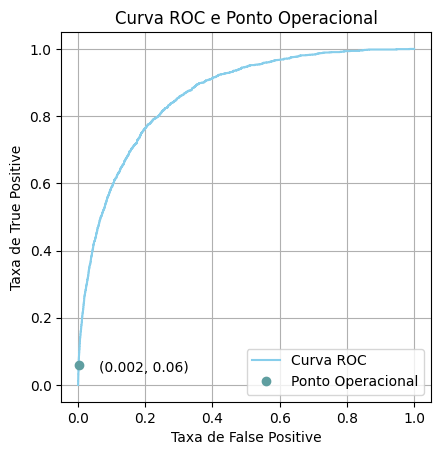

% de acertos na validação: 0.9341213175736486
score de treino: 0.9371
score de teste: 0.93512
Parametros escolhidos:C=0.1, penalty=l2
--------------------
erros: 1622
--------------------
matriz de confusão:
[[23277    39]
 [ 1583   101]]
--------------------
precisão: 0.998327328872877
recall: 0.9363234111021722
f1-score: 0.9663317834606444
--------------------
--------------------


In [73]:
par = procurar_parametros_svm(True)

Os parametros escolhidos foram:

C=1, penalty=l2

contudo a precisão do modelo é de 0.998, o que pode indicar overfitting. Vendo os outros resultados com outros parametros que não tenham sinais de overfitting:

| C  | penalty | precisão | recall | score | score treino |
|----|---------|----------|--------|-------|--------------|
| 10 | l1      | 0.9384   | 0.948  | 0.895 | 0.982        |
| 10 | l2      | 0.957    | 0.947  | 0.911 | 0.983        |

Estas duas combinações são as menos prováveis de ter overfitting, contundon têm indicios na mesma. Sendo que, a primeira vista, esta modelo, com o kernel linear, pode não ser uma boa opção. Tendo uma melhor precisão com o l2, testa-se e treina-se com esses valores.


In [75]:
'''
Função para fazer o treino e teste final do classificador binario com os hiperametros encontrados.
Atributos: 
    - par: parametros do modelo;
    - muito_boa: booleano para saber se se esta a classificar criticas muito boas ou muito más.
    
'''

def classificacao_Binaria_2_SVM(par, muito_boa):
    
    #Passo 1: Carregar os dados de teste, estes já esão limpos com o porter
    X_train_limpos_snowball = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    X_train = np.array(X_train_limpos_snowball)
    if muito_boa:
        y_train = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTrain])
    else:
        y_train = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) <= 2 else -1 for idx in beerDictTrain])
    
    #Passo 2: Carregar os dados de teste
    X_test_limpos_snowball = pickle.load(open("ficheirosPickel/documentos_teste_snowball.p", "rb"))
    X_test = np.array(X_test_limpos_snowball)
    if muito_boa:
        y_test = np.array([1 if int(beerDictTest[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTest])
    else:
        y_test = np.array([1 if int(beerDictTest[idx]['overall'].split('/')[0]) <= 2 else -1 for idx in beerDictTest])

    #Passo 3: Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)
    
    #armazenar o vocabulario e o vetorizador e os dados de treino e teste
    vect = {'vocabulario': vectorizer.get_feature_names_out(), 'X_train_t': X_train_t, 'X_test_t': X_test_t, 'y_train': y_train, 'y_test': y_test}
    
    vocabulario = vect['vocabulario']
    print("Tamanho do vocabulario:", len(vocabulario))
    print("--------------------")
    print(np.sum(y_train==1))
    print(np.sum(y_train==-1))


    svm=LinearSVC(C=par[0], penalty=par[1])
    svm.fit(X_train_t, y_train)

    svm.fit(X_train_t, y_train)
    y_pred=svm.predict(X_test_t)
    #calcular as métricas
    calcular_metricas_svm(svm, 0, par, y_test, X_test_t, X_train_t, y_train, y_pred)
 
    #ir buscar as keys das criticas
    keys = list(beerDictTest.keys())

    #ver 5 criticas bem classificadas do conjunto de teste original e o seu overall
    print("5 criticas bem classificadas:")
    #ver criticas classificadas na classe 1 e que são da classe 1
    idxs = np.where((y_test == 1) & (y_pred == 1))[0]

    for i in range(5):
        idx = idxs[i]
        item = beerDictTest[keys[idx]]
        print("Critica:", item.get('review'))
        print("Classificação:", item.get('overall'))
        print("Classificação do Modelo:", y_pred[idx])
        print("----------")

    print("+++++++++++++++++++++")

    #ver 5 criticas mal classificadas
    print("5 criticas mal classificadas:")
    idxs = np.where(y_test != y_pred)[0]
    for i in range(5):
        idx = idxs[i]
        print("Critica:", beerDictTest[keys[idx]].get('review'))
        print("Classificação:", beerDictTest[keys[idx]].get('overall'))
        print("Classificação do Modelo:", y_pred[idx])
        print("----------")


Tamanho do vocabulario: 12836
--------------------
3346
71654


C:\Users\Utilizador\OneDrive - Instituto Superior de Engenharia de Lisboa\00_ISEL\00_5Semestre\AA\venv\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Utilizador\OneDrive - Instituto Superior de Engenharia de Lisboa\00_ISEL\00_5Semestre\AA\venv\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


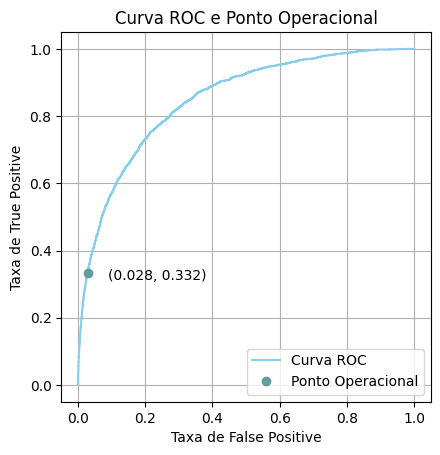

% de acertos na validação: 0
score de treino: 0.9866533333333334
score de teste: 0.90968
Parametros escolhidos:C=10, penalty=l2
--------------------
erros: 2258
--------------------
matriz de confusão:
[[21935   636]
 [ 1622   807]]
--------------------
precisão: 0.971822249789553
recall: 0.9311457316296642
f1-score: 0.9510492542490462
--------------------
--------------------
5 criticas bem classificadas:
Critica: UPDATED: SEP 28, 2011 This brew poured up a dark amber colored body with a one-finger thick off-white colored head; moderate retention and minimal lacing. Aromas of citrusy hops, harvest spices (nutmeg, etc.) and orange zest. Flavors are rather bland making this brew a good chugger/quaffer for those into that sort of drinking style. Near medium-bodied, watered-down with a bland and tasteless finish. I was a bit dismayed at this brew and hope that future runs will improve. NOTE: This was the 2010 release.
Classificação: 2/10
Classificação do Modelo: 1
----------
Critica: 2005

In [76]:
# classificacao_Binaria_2_SVM((10, 'l2'), False)

Tamanho do vocabulario: 12836
--------------------
5052
69948


C:\Users\Utilizador\OneDrive - Instituto Superior de Engenharia de Lisboa\00_ISEL\00_5Semestre\AA\venv\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
C:\Users\Utilizador\OneDrive - Instituto Superior de Engenharia de Lisboa\00_ISEL\00_5Semestre\AA\venv\Lib\site-packages\sklearn\svm\_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


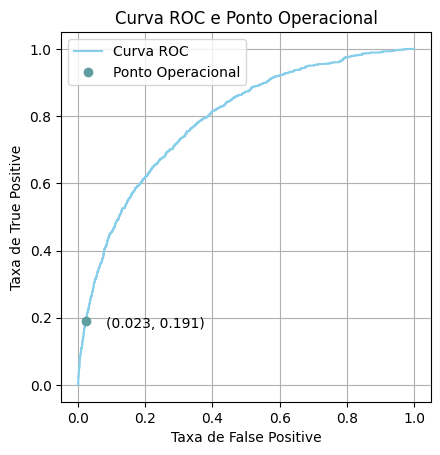

% de acertos na validação: 0
score de treino: 0.9646933333333333
score de teste: 0.94212
Parametros escolhidos:C=10, penalty=l2
--------------------
erros: 1447
--------------------
matriz de confusão:
[[23341   548]
 [  899   212]]
--------------------
precisão: 0.9770605718112939
recall: 0.9629125412541254
f1-score: 0.9699349664443474
--------------------
--------------------
5 criticas bem classificadas:
Critica: Tasted from bottle into a nucleated tulip glass. Poured a beautiful reddish-brown color with chill haze and long-lasting fluffy off-white foam, lots of Belgian lace. Awesome aroma of earthy, spicy hops, some bread and fruit and holiday spice. Complex biscuity malt sweetness with pronounced bittering and flavor hops, just shy of IPA strength. Great medium body and well-rounded, creamy mouthfeel, lingering fruity aftertaste. Absolutely delicious. Weighted average of only 2.8?! Apparently Abitas 2011 Christmas recipe is much, MUCH better than in the past. Everyone needs to giv

In [77]:
# classificacao_Binaria_2_SVM((10, 'l2'), True)

Ao treinar e testar com estes parametros temos os seguintes resultados:

Parametros escolhidos: C=10, penalty=l2


classificaçao | score | score treino | erros | precisão | recall | f1-score | Verdadeiros Positivos | Verdadeiros Negativos | Falsos Positivos | Falsos Negativos
--------------|-------|--------------|-------|----------|--------|----------|-----------------------|-----------------------|------------------|-----------------
Muito Más    | 0.909 | 0.986        | 2258  | 0.971    | 0.931  | 0.951    | 21935                 | 807                   | 1622             | 636
Muito Boas   | 0.942 | 0.965        | 1447  | 0.977    | 0.962  | 0.969    | 23341                 | 212                   | 899              | 548

Os resultados parecem razoáveis, contudo, mas estao mais criticas que deveriam ser classificadas como muito más, ou muito boas, que não estao a ser bem previstas pelo classificador. O que pode indicar que o modelo não é o melhor para este problema.

Comparando com o classificador anterior, temos:

| Metrica         | 1º Classificar Muito Boa | 1º Classificar Muito Más | 2º Classificar Muito Boa | 2º Classificar Muito Más |
|-----------------|--------------------------|--------------------------|--------------------------|--------------------------|
| Erros           | 1117                     | 2051                     | 1447                     | 2258                     |
| Score do Modelo | 0.95532                  | 0.91796                  | 0.942                    | 0.909                    |
| Score do Treino | 0.93999                  | 0.96391                  | 0.965                    | 0.986                    |
| Precisão        | 0.9996                   | 0.9943                   | 0.977                    | 0.971                    |
| Recall          | 0.9657                   | 0.9211                   | 0.962                    | 0.931                    |
| F1-score        | 0.9591                   | 0.9563                   | 0.969                    | 0.951                    |
| TPositivos      | 23785                    | 22442                    | 23341                    | 21935                    |
| TNegativos      | 98                       | 507                      | 212                      | 807                      |
| FPositivos      | 1013                     | 1922                     | 899                      | 1622                     |
| FNegativos      | 104                      | 129                      | 548                      | 636                      |

Podemos ver que o SVM comete mais erros, contudo classifica melhor se as criticas são muito boas e muito más.

## Classificador Multi-classe

O problema a resolver, é um problema de classificação multi-classe, onde, com base na critica de texto, tem que se prever a classificação das componetnes de 'smell', 'taste' e 'overall' da cerveja. Para isso, vai ser usado o Discriminante Logistico. Vai se então classificar para cada componete, sendo que têm classes diferentes, vejamos:

- smell: 1-5
- taste: 1-5
- overall: 1-10

Primeiro vai-se verificar o melhor vocabulario de novo, verificando para o smell. Aplicamos o discriminante Logistico sem testar hiperparametros para ver qual o melhor vocabulario.

In [40]:
'''
Função para testar o melhor vocabulario para o discriminante logistico multi-classe.
Atributos: 
    - X_train: documentos de treino;
    - y_train: classes de treino;
    - X_test: documentos de teste;
    - y_test: classes de teste;
    - vocabulario: vocabulario a testar.
Return:
    - vocabulario: melhor vocabulario;
    - matriz_confusao: matriz de confusão;
    - precisao: precisao;
    - recall: recall;
    - f1_score: f1-score;
    - dl_score_treino: score do treino;
    - dl_score_teste: score do teste.
'''

def logistic_regression_MC(X_train, X_test, y_train, y_test, vocabulario):
    
    modelo = LogisticRegression(C=0.1, penalty='l1', solver='saga', multi_class="multinomial" ).fit(X_train, y_train)
    
    y_e = modelo.predict(X_test)
    
    matriz_confusao = confusion_matrix(y_test, y_e)
    
    print("Matriz de Confusão:")
    print(matriz_confusao)
    print("----------")
    
    if (matriz_confusao[1][1] + matriz_confusao[0][1]) != 0:
        precisao = matriz_confusao[1][1] / (matriz_confusao[1][1] + matriz_confusao[0][1])
        recall = matriz_confusao[1][1] / (matriz_confusao[1][1] + matriz_confusao[1][0])

    else:
        precisao = 0.0
        recall = 0.0
        
    if (precisao + recall) != 0:
        f1_score = 2 * ((precisao * recall) / (precisao + recall))
    else:
        f1_score = 0.0
  
    
    print("Precisão:", precisao)
    print("Recall:", recall)
    print("F1-score:", f1_score)
    
    print("dl_Score_Treino:", modelo.score(X_train, y_train))
    print("dl_Score_Teste:", modelo.score(X_test, y_test))
    
    print("----------")

    print("Vocabulário:", len(vocabulario))
    w = modelo.coef_
    
    # Obter índices ordenados dos pesos para a primeira classe (você pode ajustar conforme necessário)
    idx = np.argsort(w[0, :])
    
    # Ordenar o vocabulário de acordo com os pesos
    vocabulario_ordenado = [vocabulario[i] for i in idx]
    
    # Imprimir as primeiras 100 palavras com seus pesos
    print("Palavras ordenadas pelo peso para a primeira classe (primeiras 100):")
    for i in idx[:100]:
        print('(%.2f) %s' % (w[0, i], vocabulario[i]))
    
    print('\n', '-' * 100, '\n')
    
    # Imprimir as últimas 100 palavras com seus pesos
    print("Palavras ordenadas pelo peso para a primeira classe (últimas 100):")
    for i in idx[-100:]:
        print('(%.2f) %s' % (w[0, i], vocabulario[i]))

    
    return vocabulario, matriz_confusao, precisao, recall, f1_score, modelo.score(X_train, y_train), modelo.score(X_test, y_test)
    

In [41]:
''' 
Funçaão para testar os parametros
Atributos: 
    - stemmer: stemmer a usar;
    - docs: documentos a usar;
    - y: classes a usar.
Return:
    - dicionario_valores: dicionario com os valores obtidos.
'''
def teste_logistic_Regression_MC(stemmer, docs, y):
    X_train, X_test, y_train, y_test = train_test_split(docs, y, test_size=1/3, stratify=y)
    #criar validação
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=1/3, stratify=y_train)
    ngrams      = [(1,1), (1,2), (1,3)]
    mdfs         = [2,3,4,5]
    tps         = [r'\b\w\w+\b', r'\b\w\w\w+\b', r'\b\w\w\w\w+\b']

    print(f"Stemmer: {stemmer}")
    
    dicionario_valores = {}
    
    for mdf in mdfs:
            t_index = 1
            for token in tps:
                t_index += 1
                for ngram in ngrams:
                    # Construir o nome do arquivo para salvar o vocabulário
                    configuracao = f"min_df_{mdf}_pattern_{t_index}_ngram_{ngram}"
        
                    # Aplicar vetorização e criar vocabulário para cada conjunto de documentos
                
                    stop = 'english'
                    vectorizer = TfidfVectorizer(min_df=mdf, token_pattern=token, stop_words=stop, ngram_range=ngram).fit(X_train)
                    X_train_t = vectorizer.transform(X_train)
                    X_val_t = vectorizer.transform(X_val)
                    vocabulario = vectorizer.get_feature_names_out()
                    vocabulario, matriz_confusao, precisao, recall, f1_score, dl_score_treino, dl_score_val = logistic_regression_MC(X_train_t, X_val_t, y_train, y_val, vocabulario)
                    dicionario_valores[configuracao] = {'vocabulario': vocabulario, 'matriz_confusao': matriz_confusao, 'precisao': precisao, 'recall': recall, 'f1_score': f1_score, 'dl_score_treino': dl_score_treino, 'dl_score_val': dl_score_val}
                    print(f"Configuração: {configuracao}")
                    print(f"Vocabulário: {len(vocabulario)}")
                    print(f"Matriz de Confusão: {matriz_confusao}")
                    print(f"Precisão: {precisao}")
                    print(f"Recall: {recall}")
                    print(f"F1-score: {f1_score}")
                    print("----------")
                    print("----------")
                    print("----------")
                    print("----------")
                    print("----------")
                    print("----------")
                    print("----------")
    return dicionario_valores


In [42]:
'''
 Função para testar os varios stemmers, guardando numa ficheiro pickel os resultados. 
'''
def executar_teste_de_stemmers_e_vetorizacao_MC():
   
    
    #documentoa limpoa sem stemming
    docs = pickle.load(open("ficheirosPickel/documentos_limpos.p", "rb"))
    docs = np.array(docs)
    
    y = np.array([int(beerDictTrain[idx]['smell'].split('/')[0]) for idx in beerDictTrain])
    print(y.shape)
    
    
    dicionario_limpos = teste_logistic_Regression_MC("Limpos", docs, y)
    pickle.dump(dicionario_limpos, open("ficheirosPickel/Multiclasse/Multi_classe_dicionario_limpos_dl_v2.p", "wb"))



    #documentos porter
    docs = pickle.load(open("ficheirosPickel/documentos_porter.p", "rb"))
    docs = np.array(docs)
    y = np.array([int(beerDictTrain[idx]['smell'].split('/')[0]) for idx in beerDictTrain])
    print(y.shape)

    
    dicionario_porter = teste_logistic_Regression_MC("Porter", docs, y)
    
    pickle.dump(dicionario_porter, open("ficheirosPickel/Multiclasse/Multi_classe_dicionario_porter_dl_v2.p", "wb"))


    
    #documentos snowball
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    docs = np.array(docs)
    y = np.array([int(beerDictTrain[idx]['smell'].split('/')[0]) for idx in beerDictTrain])
    print(y.shape)
    
    
    dicionario_snowball = teste_logistic_Regression_MC("Snowball", docs, y)
    pickle.dump(dicionario_snowball, open("ficheirosPickel/Multiclasse/Multi_classe_dicionario_snowball_dl_v2.p", "wb"))

    #documentos lancaster
    docs = pickle.load(open("ficheirosPickel/documentos_lancaster.p", "rb"))
    docs = np.array(docs)
    y = np.array([int(beerDictTrain[idx]['smell'].split('/')[0]) for idx in beerDictTrain])
    print(y.shape)
    
    
    dicionario_lancaster = teste_logistic_Regression_MC("Lancaster", docs, y)
    pickle.dump(dicionario_lancaster, open("ficheirosPickel/Multiclasse/Multi_classe_lancaster_dl_v2.p", "wb"))



In [43]:
#executar_teste_de_stemmers_e_vetorizacao_MC()

Tabela de Métricas - Limpos
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=2, (1, 1) |   0.539683 | 0.483412  |  0.51      |          0.408904 |             0.404092 |
| min_df=2, pattern=2, (1, 2) |   0.428571 | 0.214286  |  0.285714  |          0.381424 |             0.381712 |
| min_df=2, pattern=2, (1, 3) |   0        | 0         |  0         |          0.377314 |             0.379552 |
| min_df=2, pattern=3, (1, 1) |   0.536458 | 0.481308  |  0.507389  |          0.409024 |             0.404452 |
| min_df=2, pattern=3, (1, 2) |   0.466667 | 0.233333  |  0.311111  |          0.381724 |             0.381892 |
| min_df=2, pattern=3, (1, 3) |   0        | 0         |  0         

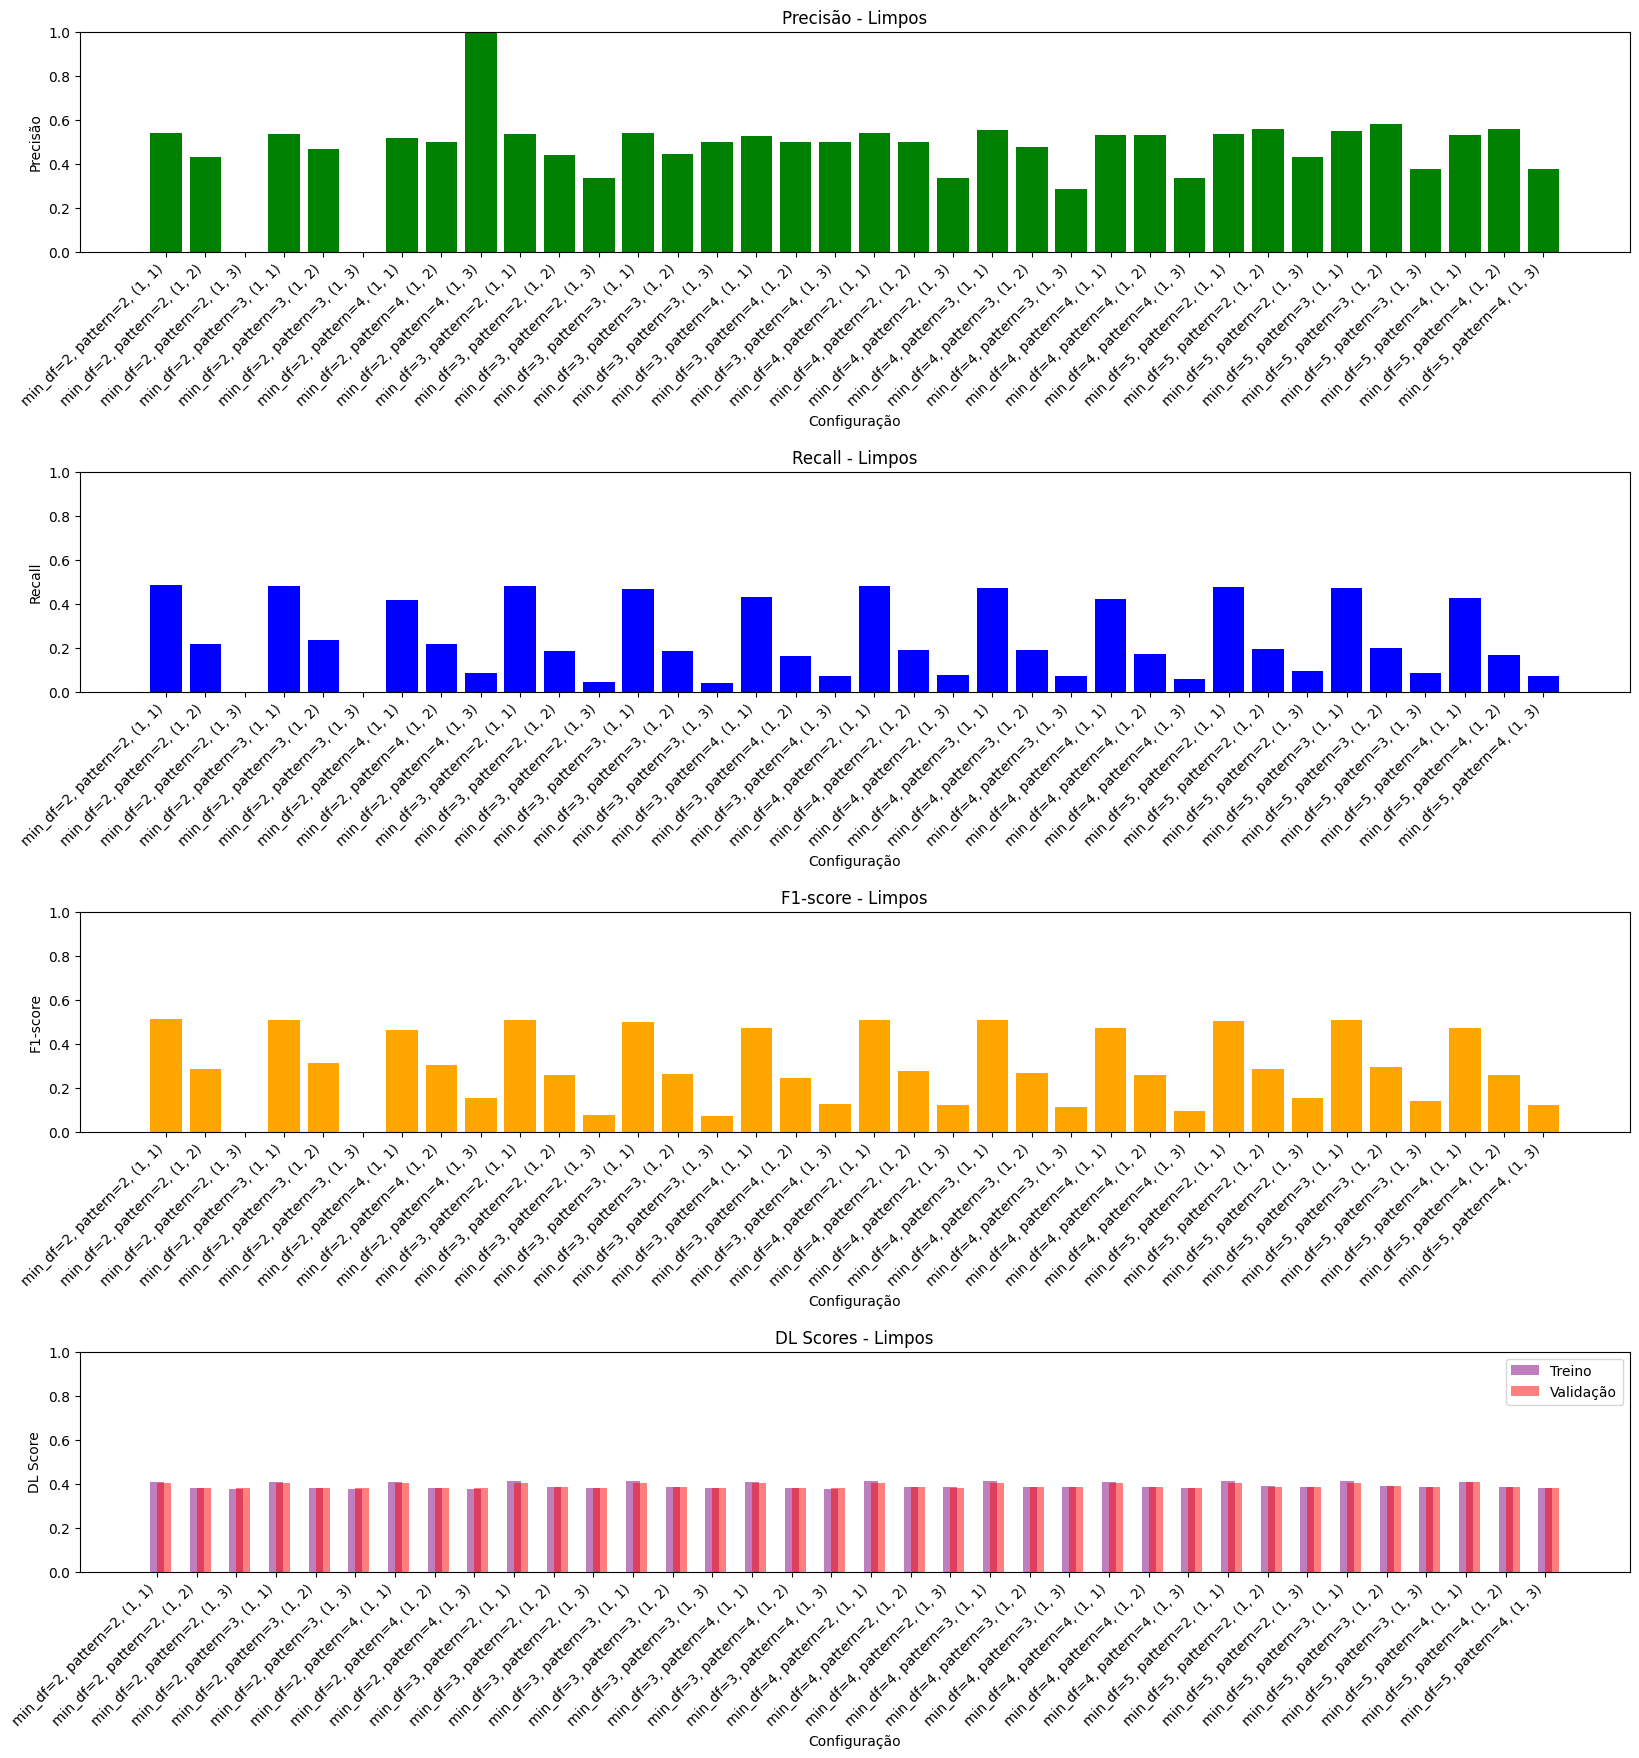

Tabela de Métricas - Porter
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=2, (1, 1) |   0.531646 | 0.508065  |   0.519588 |          0.415924 |             0.411652 |
| min_df=2, pattern=2, (1, 2) |   0.7      | 0.162791  |   0.264151 |          0.389224 |             0.385912 |
| min_df=2, pattern=2, (1, 3) |   0        | 0         |   0        |          0.383164 |             0.383092 |
| min_df=2, pattern=3, (1, 1) |   0.546559 | 0.523256  |   0.534653 |          0.416284 |             0.413152 |
| min_df=2, pattern=3, (1, 2) |   0.769231 | 0.212766  |   0.333333 |          0.389434 |             0.387052 |
| min_df=2, pattern=3, (1, 3) |   0        | 0         |   0        

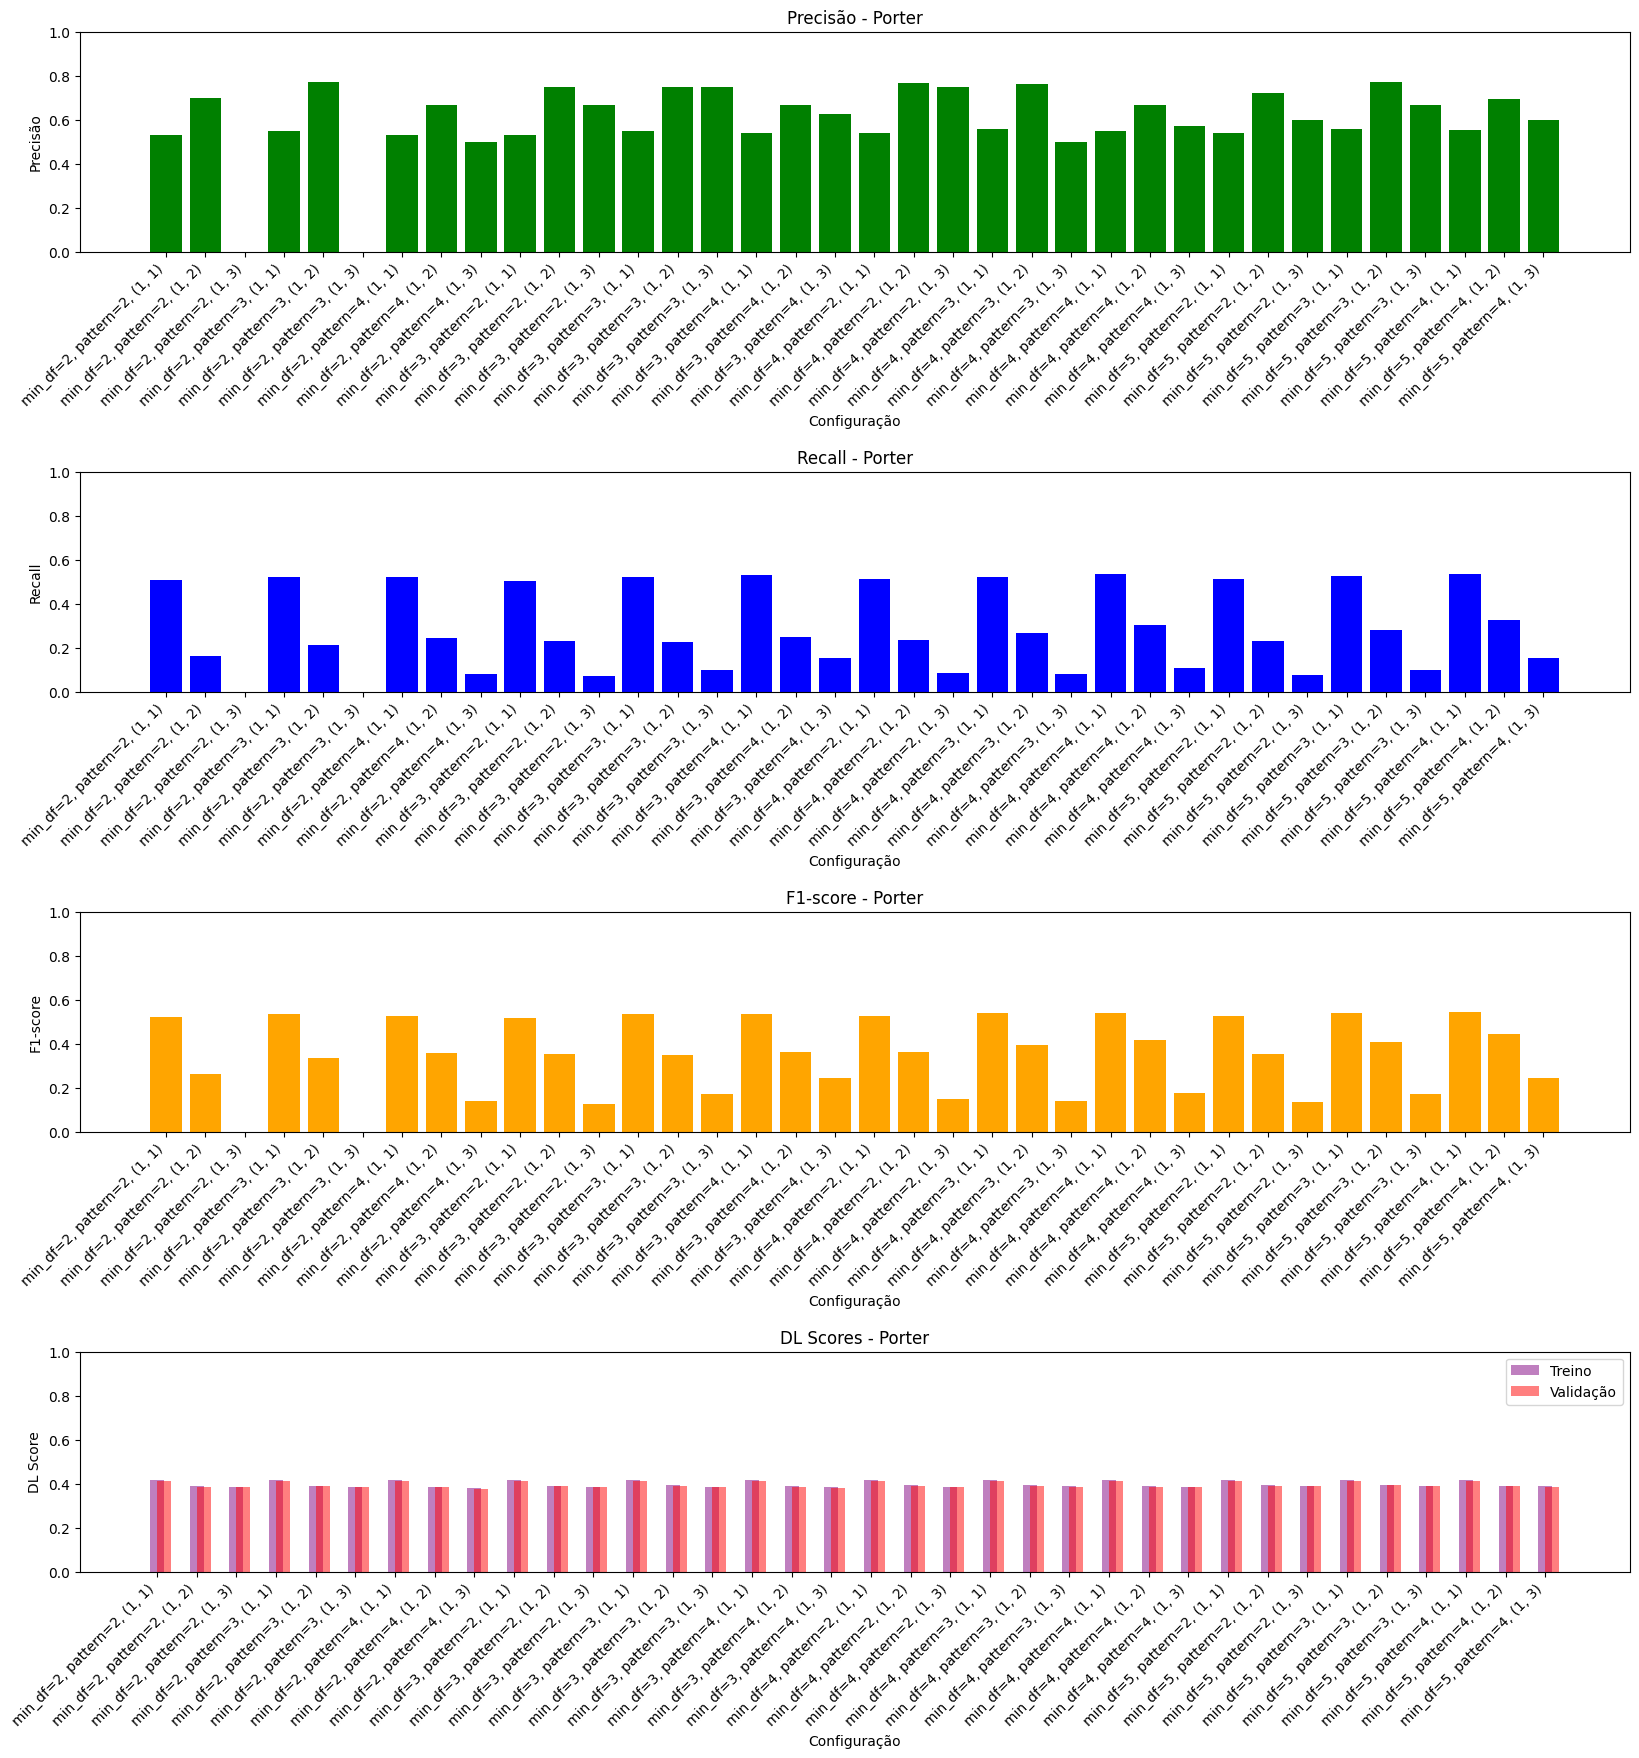

Tabela de Métricas - Snowball
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=2, (1, 1) |   0.584098 | 0.552023  |  0.567608  |          0.418354 |             0.413452 |
| min_df=2, pattern=2, (1, 2) |   0.612903 | 0.275362  |  0.38      |          0.389404 |             0.387292 |
| min_df=2, pattern=2, (1, 3) |   0.2      | 0.0416667 |  0.0689655 |          0.383074 |             0.383032 |
| min_df=2, pattern=3, (1, 1) |   0.590214 | 0.553009  |  0.571006  |          0.419134 |             0.413212 |
| min_df=2, pattern=3, (1, 2) |   0.588235 | 0.28169   |  0.380952  |          0.389494 |             0.387652 |
| min_df=2, pattern=3, (1, 3) |   0.2      | 0.0416667 |  0.068965

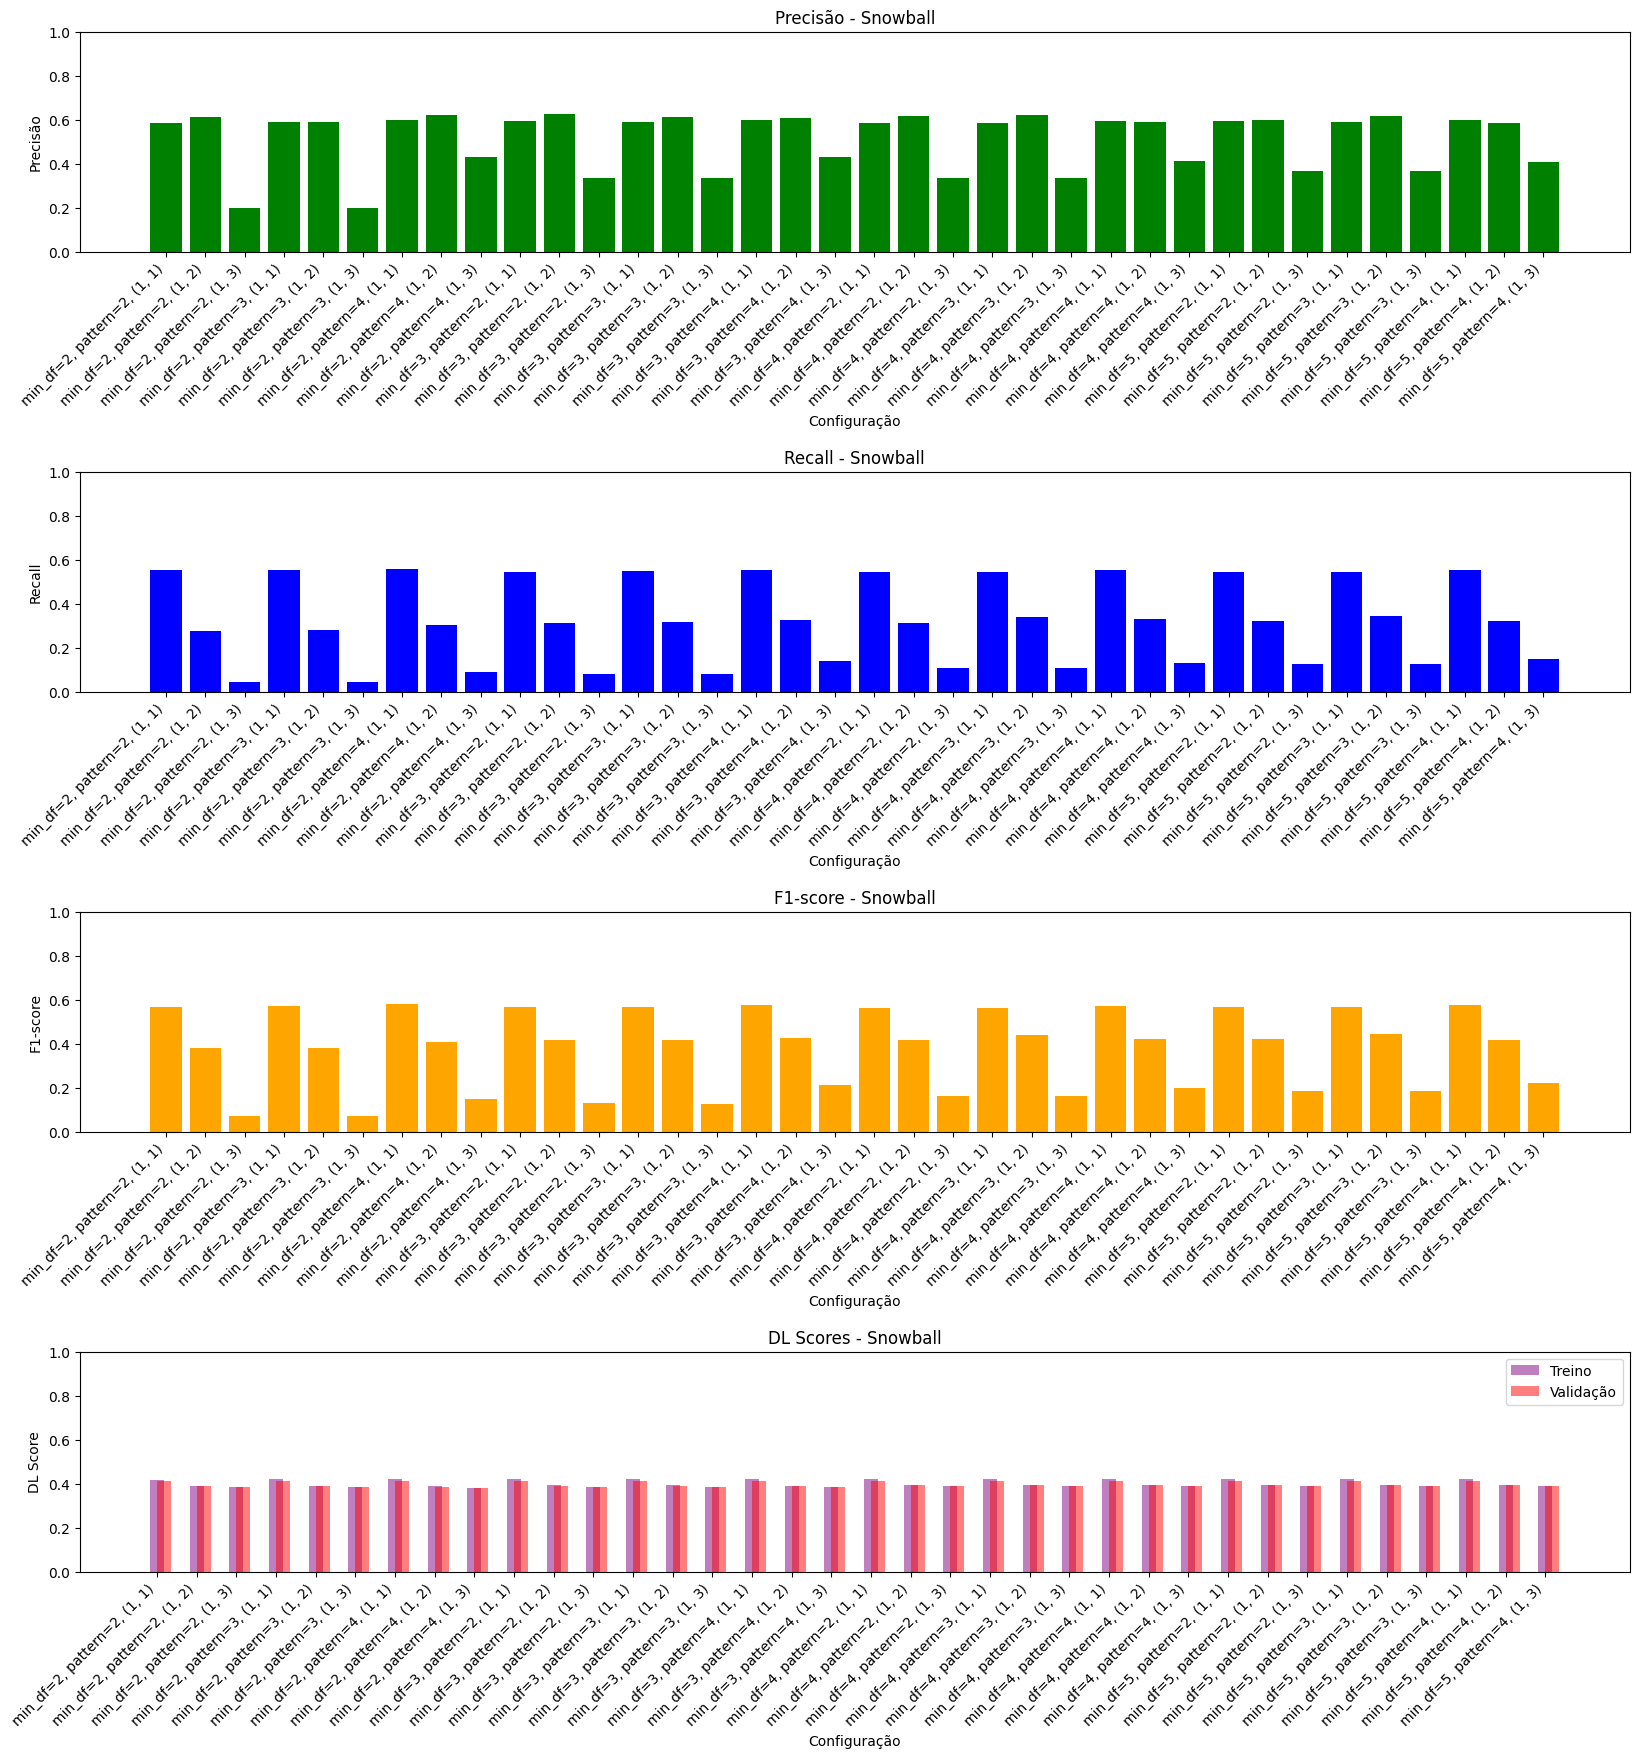

Tabela de Métricas - Lancaster
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=2, (1, 1) |   0.566225 | 0.51506   |  0.539432  |          0.423244 |             0.412852 |
| min_df=2, pattern=2, (1, 2) |   0.538462 | 0.21875   |  0.311111  |          0.389854 |             0.384832 |
| min_df=2, pattern=2, (1, 3) |   0        | 0         |  0         |          0.382174 |             0.379012 |
| min_df=2, pattern=3, (1, 1) |   0.540453 | 0.503012  |  0.521061  |          0.422554 |             0.412192 |
| min_df=2, pattern=3, (1, 2) |   0.464286 | 0.19403   |  0.273684  |          0.390904 |             0.386512 |
| min_df=2, pattern=3, (1, 3) |   0        | 0         |  0      

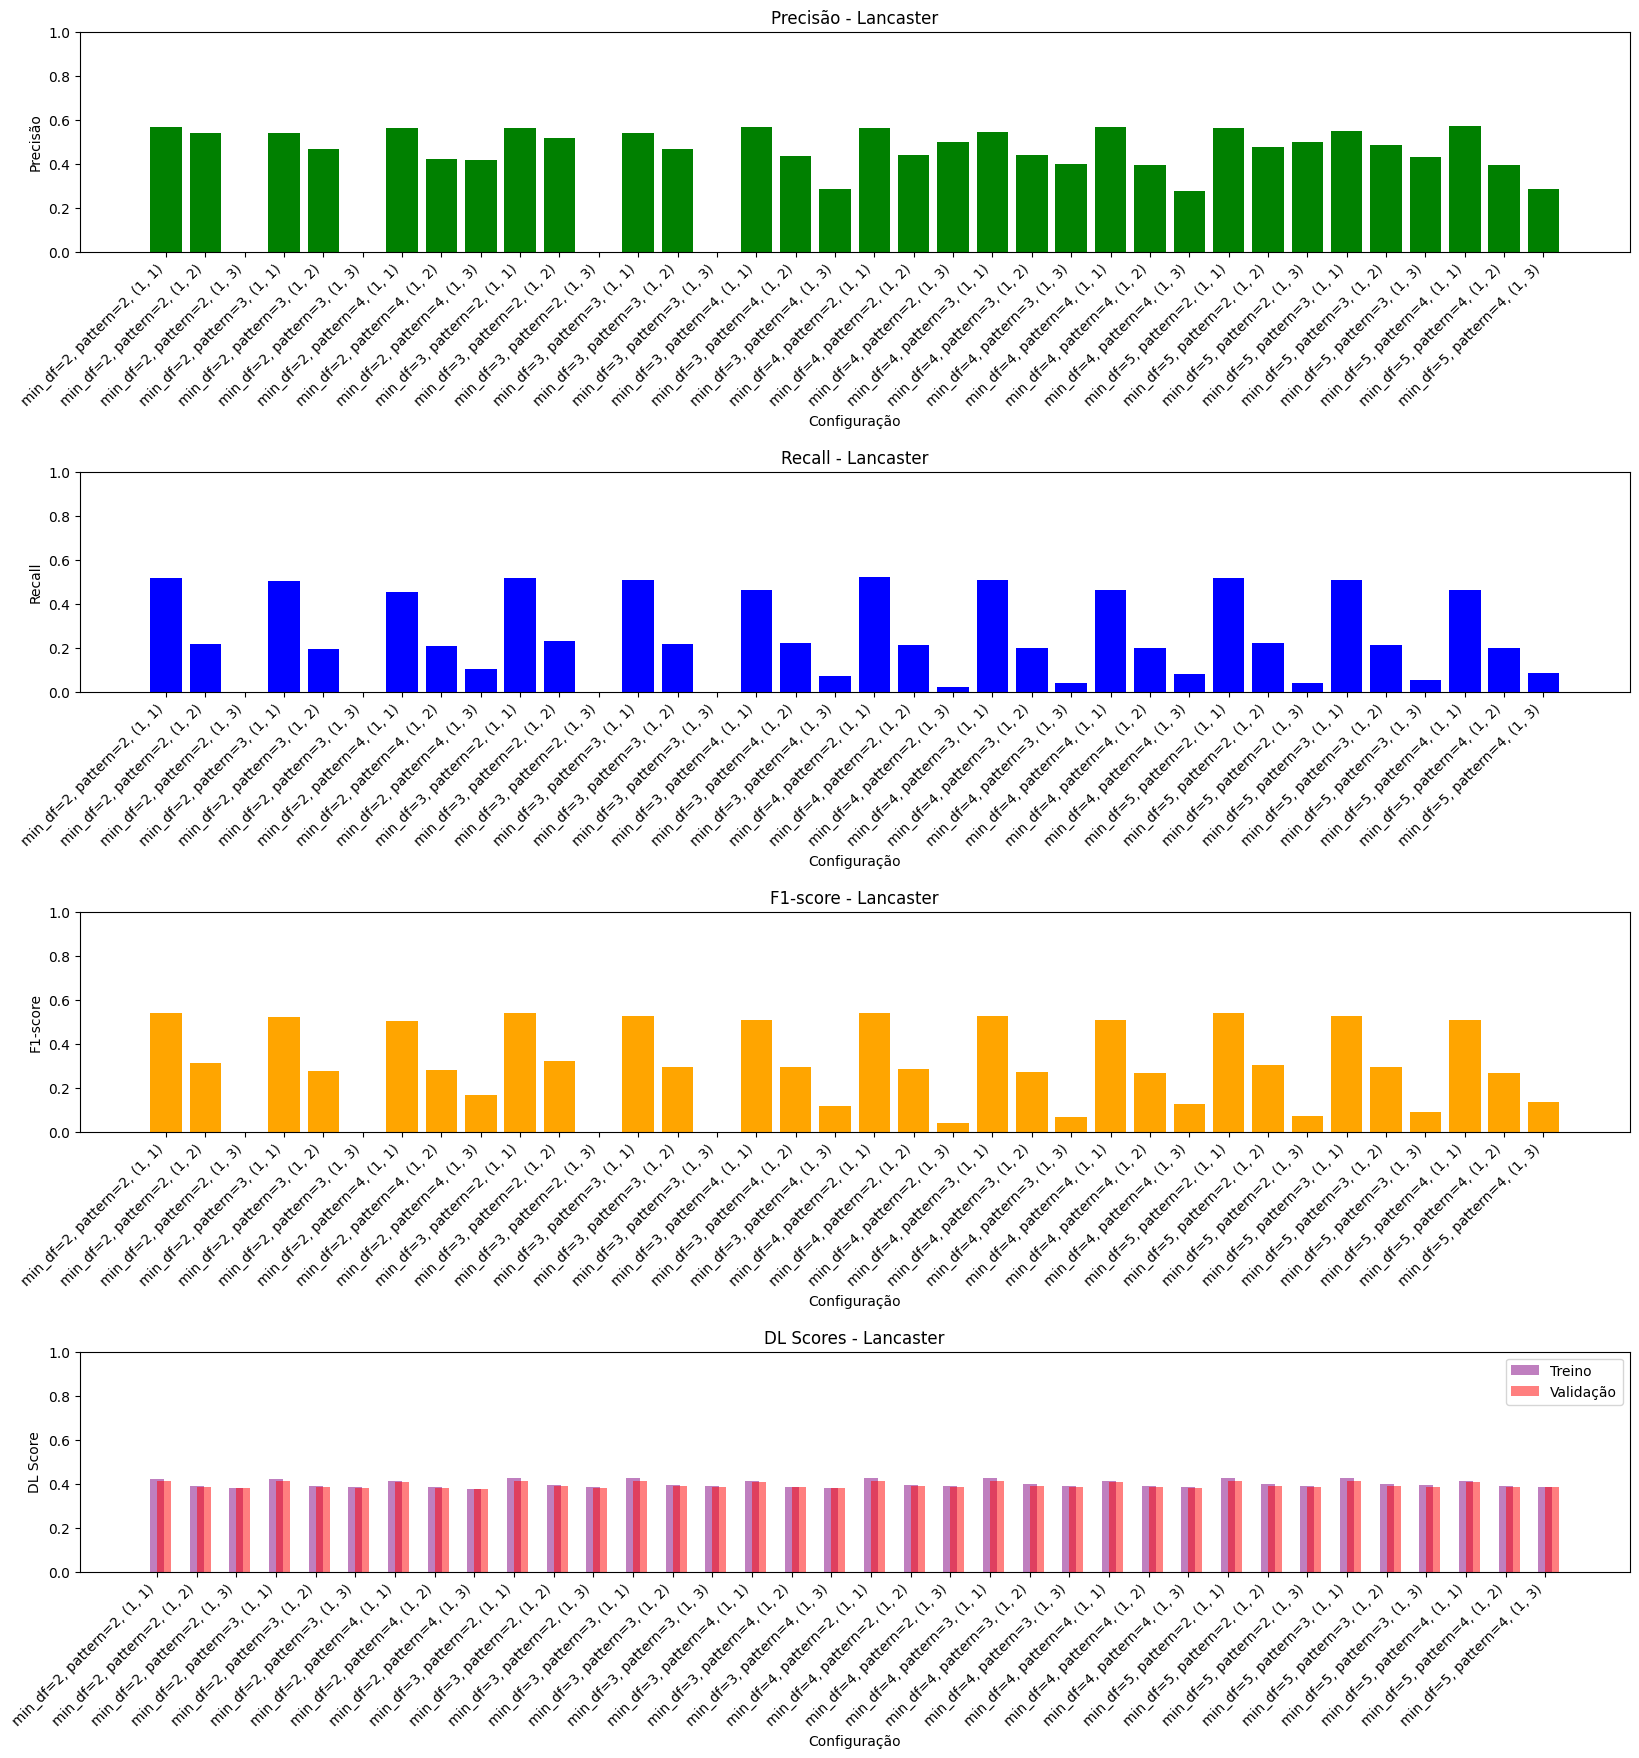

In [44]:
dicionario_limpos = pickle.load(open("ficheirosPickel/Multiclasse/Multi_classe_dicionario_limpos_dl_v2.p", "rb"))
dicionario_porter = pickle.load(open("ficheirosPickel/Multiclasse/Multi_classe_dicionario_porter_dl_v2.p", "rb"))
dicionario_snowball = pickle.load(open("ficheirosPickel/Multiclasse/Multi_classe_dicionario_snowball_dl_v2.p", "rb"))
dicionario_lancaster = pickle.load(open("ficheirosPickel/Multiclasse/Multi_classe_lancaster_dl_v2.p", "rb"))

# Criar tabela e gráfico para cada stemmer
criar_tabela_metricas(dicionario_limpos, "Limpos")
criar_tabela_metricas(dicionario_porter, "Porter")
criar_tabela_metricas(dicionario_snowball, "Snowball")
criar_tabela_metricas(dicionario_lancaster, "Lancaster")

Verifica-se agora que os scores estão muito baixos, compara-se então os valores de cada stemmer e depois entre cada stemmer. Procurando os melhores valores de score de validação e tendo atenção que existem valores de precisão a 0 e a 1, o que pode indicar overfitting.

Limpos:
Tabela de Métricas - Limpos

| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino | DL Score Validação   |
|-----------------------------|------------|-----------|------------|-------------------|----------------------|
| min_df=2, pattern=3, (1, 1) |   0.536458 | 0.481308  |  0.507389  |          0.409024 | 0.404452             |
| min_df=3, pattern=4, (1, 1) |   0.526012 | 0.429245  |  0.472727  |          0.408514 | 0.404572             |
| min_df=4, pattern=4, (1, 1) |   0.531792 | 0.422018  |  0.470588  |          0.408784 | 0.404872             |
| min_df=5, pattern=3, (1, 1) |   0.546798 | 0.47234   |  0.506849  |          0.411094 | 0.404512             |
| min_df=5, pattern=4, (1, 1) |   0.528409 | 0.424658  |  0.470886  |          0.409384 | 0.405352             |


Dos documentos stemmer, tendo estes valores muito proximos de score, pode-se olhar para os de precisão e de recall, sendo que o melhor de precisão é o min_df=5, pattern=3, (1, 1), tendo este em conta.

Na tabel do porter, os valores de score são parecidos, mas os de precisão variam de 0.76 a 0.5 o que pode fazer uma difecrença. Olhando para os valores de recall do s valores mais altos, estes são muito baixos, por isso analisa-se os valores de f1.

Tabela de Métricas - Porter

| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------|------------|-----------|------------|-------------------|----------------------|
| min_df=2, pattern=3, (1, 1) |   0.546559 | 0.523256  |   0.534653 |          0.416284 |             0.413152 |
| min_df=3, pattern=3, (1, 1) |   0.547619 | 0.522727  |   0.534884 |          0.417034 |             0.413452 |
| min_df=3, pattern=4, (1, 1) |   0.54023  | 0.532075  |   0.536122 |          0.416584 |             0.410632 |
| min_df=4, pattern=3, (1, 1) |   0.555556 | 0.520446  |   0.537428 |          0.417544 |             0.414052 |
| min_df=4, pattern=4, (1, 1) |   0.547893 | 0.533582  |   0.540643 |          0.417094 |             0.411112 |
| min_df=5, pattern=3, (1, 1) |   0.555556 | 0.524345  |   0.539499 |          0.417514 |             0.413752 |


Considerear o min_df=4, pattern=3, (1, 1)


Tabela de Métricas - Snowball

| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------|------------|-----------|------------|-------------------|----------------------|
| min_df=2, pattern=3, (1, 1) |   0.590214 | 0.553009  |  0.571006  |          0.419134 |             0.413212 |
| min_df=2, pattern=4, (1, 1) |   0.6      | 0.559322  |  0.578947  |          0.420184 |             0.413752 |
| min_df=3, pattern=4, (1, 1) |   0.596386 | 0.554622  |  0.574746  |          0.420064 |             0.414112 |
| min_df=4, pattern=4, (1, 1) |   0.59403  | 0.552778  |  0.572662  |          0.420394 |             0.414052 |
| min_df=5, pattern=4, (1, 1) |   0.600601 | 0.552486  |  0.57554   |          0.420964 |             0.413572 |


A considerar o min_df=5, pattern=4, (1, 1)


Tabela de Métricas - Lancaster

| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------|------------|-----------|------------|-------------------|----------------------|
| min_df=2, pattern=2, (1, 1) |   0.566225 | 0.51506   |  0.539432  |          0.423244 |             0.412852 |
| min_df=3, pattern=2, (1, 1) |   0.563518 | 0.516418  |  0.538941  |          0.423874 |             0.412972 |
| min_df=4, pattern=2, (1, 1) |   0.561905 | 0.520588  |  0.540458  |          0.424444 |             0.413692 |
| min_df=5, pattern=2, (1, 1) |   0.563291 | 0.514451  |  0.537764  |          0.424474 |             0.413632 |
| min_df=5, pattern=3, (1, 1) |   0.549206 | 0.505848  |  0.526636  |          0.424234 |             0.412432 |


considerar o min_df=4, pattern=2, (1, 1)


Comparando entre stemmers

Tabela de Métricas - Comparação

| Stemmer   | Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------|-----------------------------|------------|-----------|------------|-------------------|----------------------|
| Limpos    | min_df=5, pattern=3, (1, 1) |   0.546798 | 0.47234   |  0.506849  |          0.411094 |             0.404512 |
| Porter    | min_df=4, pattern=3, (1, 1) |   0.555556 | 0.520446  |   0.537428 |          0.417544 |             0.414052 |
| Snowball  | min_df=5, pattern=4, (1, 1) |   0.600601 | 0.552486  |  0.57554   |          0.420964 |             0.413572 |
| Lancaster | min_df=4, pattern=2, (1, 1) |   0.561905 | 0.520588  |  0.540458  |          0.424444 |             0.413692 |


Os valores são muito pareceidos, contudo o snowball tem melhores valores de precisão e recall, sendo que o melhor é o snowball.

| Snowball  | min_df=5, pattern=4, (1, 1) |

Procurar os melhores hiperparametros para o classificador multi-classe

In [45]:
'''
Função para testar os hiperparametros do discriminante logistico multi-classe.
Atributos: 
    - X_train: documentos de treino;
    - y_train: classes de treino;
    - X_test: documentos de teste;
    - y_test: classes de teste;
    - c: valor de c;
    - penalty: tipo de penalização;
    - solver: solver a usar.
Return:
    - score_crossVal: score do cross validation;
    - erros: erros;
    - score_modelo: score do modelo.
'''

def linearRegression_3_MC(X_train, X_test, y_train, y_test, c, penalty, solver):
    print("Linear Regression")
    
    lr = LogisticRegression(C=c, max_iter=5000, penalty=penalty, solver=solver, tol=1e-2).fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    # Ver o score atraves do cross validation
    score_crossVal = cross_val_score(lr, X_train, y_train, cv=5)
    # Ver os erros
    erros = np.sum(y_test != y_pred)
    # Ver o score do modelo
    score_modelo = lr.score(X_test, y_test)

    return score_crossVal, erros, score_modelo

In [46]:
'''
Função para testar as diferentes combinações
Atributos: 
    - X_train: documentos de treino;
    - X_test: documentos de teste;
    - y_train: classes de treino;
    - y_test: classes de teste.
Return:
    - best_results: melhores resultados.
'''

def teste_hiper_linearRegression_MC(X_train, X_test, y_train, y_test):
    print("Linear Regression")

    cList = [0.1, 1, 10, 100]
    penaltyList = ['l1', 'l2']
    solverList = ['lbfgs', 'sag', 'saga']

    best_results = {
        'score_crossVal': {'value': -1, 'C': None, 'penalty': None, 'solver': None},
        'erros': {'value': float('inf'), 'C': None, 'penalty': None, 'solver': None},
        'score_modelo': {'value': -1, 'C': None, 'penalty': None,  'solver': None},
    }

    for solver in solverList:
        for c in cList:
            
            for penalty in penaltyList:
                
                if solver == 'lbfgs' and penalty == 'l1':
                    continue
                elif solver == 'sag' and penalty == 'l1':
                    continue
    
                
                score_crossVal, erros, score_modelo = linearRegression_3_MC(X_train, X_test, y_train, y_test, c, penalty, solver)
    
                # Comparar e atualizar os melhores resultados para cada métrica
                if np.mean(score_crossVal) > best_results['score_crossVal']['value']:
                    best_results['score_crossVal'] = {'value': np.mean(score_crossVal), 'C': c, 'penalty': penalty, 'solver': solver}
                if erros < best_results['erros']['value']:
                    best_results['erros'] = {'value': erros, 'C': c, 'penalty': penalty, 'solver': solver}
                if score_modelo > best_results['score_modelo']['value']:
                    best_results['score_modelo'] = {'value': score_modelo, 'C': c, 'penalty': penalty, 'solver': solver}
    
    
                # Imprimir os melhores resultados e seus hiperparâmetros associados
                print("Melhores resultados:")
                print("Score Cross-Validation:", best_results['score_crossVal']['value'], "C:", best_results['score_crossVal']['C'], "Penalty:", best_results['score_crossVal']['penalty'], "Solver:", best_results['score_crossVal']['solver'])
                print("Erros:", best_results['erros']['value'], "C:", best_results['erros']['C'], "Penalty:", best_results['erros']['penalty'], "Solver:", best_results['erros']['solver'])
                print("Score do Modelo:", best_results['score_modelo']['value'], "C:", best_results['score_modelo']['C'], "Penalty:", best_results['score_modelo']['penalty'], "Solver:", best_results['score_modelo']['solver'])


    return best_results


In [47]:
'''
Função para vetorizar os documentos e guardar o vocabulario e os dados de treino e teste.
'''

def vetorizar_criar_voc_com_parametros_MC():
    #documentos snowball
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    docs = np.array(docs)
    
    y = np.array([int(beerDictTrain[idx]['smell'].split('/')[0]) for idx in beerDictTrain])
    print(y.shape)

    # Criar divisões de treinamento e teste
    X_train, X_test, y_train, y_test = train_test_split(docs, y, test_size=1/3, stratify=y)


    # Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=5, stop_words='english', token_pattern=r'\b\w\w\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)

    vocabulario = vectorizer.get_feature_names_out()
    
    #save vocabulario e X_train_t e X_val_t
    vect = {'vocabulario': vocabulario, 'X_train_t': X_train_t, 'X_test_t': X_test_t, 'y_train': y_train, 'y_test': y_test}
    pickle.dump(vect, open("ficheirosPickel/Multiclasse/Multi_classe_vocabulario_X_train_t_X_test_t_v3.p", "wb"))


In [48]:
#vetorizar_criar_voc_com_parametros_MC()

In [49]:
vect = pickle.load(open("ficheirosPickel/Multiclasse/Multi_classe_vocabulario_X_train_t_X_test_t_v3.p", "rb"))
vocabulario = vect['vocabulario']                            
X_train_t = vect['X_train_t']
X_test_t = vect['X_test_t']
y_train = vect['y_train']
y_test = vect['y_test']
# teste_hiper_linearRegression_MC(X_train_t, X_test_t, y_train, y_test)

Apos testar os hiperparametros com varias métricas, temos que os melhores parametros focando em cada métrica são:

 Metrica                | Valor  | C | Penalty | Solver
------------------------|--------|---| ------- | ------
 Score Cross-Validation | 0.4539 | 1 | l1      | saga
 Erros                  | 13691   | 1 | l1  | saga
 Score do Modelo        | 0.45236 | 1 | l1 | saga

Com um valor de score baixo, tem se a melhor configuração para o classificador multi-classe, sendo que o melhor é o solver saga, com penalty l1 e C = 1.
Treina-se e testa-se o modelo com estes parametros, para cada componente.


In [50]:
''' 
Função para limpar os dados de teste
'''
def limpar_teste_b1_MC():
    Docs_teste = [beerDictTest[idx]['review'] for idx in beerDictTest]
    Docs_teste_limpos = limpar_caracteres_tags(Docs_teste)
    porter = SnowballStemmer('english')
    X_test_limpos_lancaster = stemming(Docs_teste_limpos, porter)
    pickle.dump(X_test_limpos_lancaster, open("ficheirosPickel/Multiclasse/Multi_classe_documentos_teste_snowball_v2.p", "wb"))


In [51]:
# limpar_teste_b1_MC()

In [52]:
'''
Função que mostra os erros de classificação por classe num histograma.
Atributos: 
    - y_test: classes de teste;
    - y_pred: classes de predição;
    - classes: classes.
'''

def plot_histograma_classes_pior_classificadas(y_test, y_pred, classes):
    erros_por_classe = [np.sum((y_test == classe) & (y_pred != classe)) for classe in classes]

    # Criar o histograma
    plt.bar(classes, erros_por_classe, color='red')
    plt.xlabel('Classe')
    plt.ylabel('Número de Erros')
    plt.title('Erros de Classificação por Classe')
    plt.show()


In [85]:
from sklearn.metrics import accuracy_score, recall_score

'''
Função para classificar de um componente.
Atributos: 
    - componente: componente a classificar
'''
def classificacao_Multiclasse_1_Discriminante_Logistico(componente):
    
    print("Classificação Multiclasse: Discriminante Logistico - " + componente)
    

    #Passo 1: Carregar os dados de teste, estes já esão limpos
    X_train = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    X_train = np.array(X_train)
    
    y_train = np.array([int(beerDictTrain[idx][componente].split('/')[0]) for idx in beerDictTrain])
    print(y_train)

    #ver um exemplo do X_train
    print(X_train[0])
    print(X_train.shape)
    print(y_train.shape)
    
    
    #Passo 2: Carregar os dados de teste
    X_test_limpos_lancaster = pickle.load(open("ficheirosPickel/Multiclasse/Multi_classe_documentos_teste_snowball_v2.p", "rb"))
    X_test = np.array(X_test_limpos_lancaster)
    y_test = np.array([int(beerDictTest[idx][componente].split('/')[0]) for idx in beerDictTest])

    print(X_test.shape)
    print(y_test.shape)
    
    #Passo 3: Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=5, stop_words='english', token_pattern=r'\b\w\w\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)
    
    #armazenar o vocabulario e o vetorizador e os dados de treino e teste
    vect = {'vocabulario': vectorizer.get_feature_names_out(), 'X_train_t': X_train_t, 'X_test_t': X_test_t, 'y_train': y_train, 'y_test': y_test}
    pickle.dump(vect, open("ficheirosPickel/Multiclasse/Multi_classe_vetorizacaoConcluida_v2.p", "wb"))

    #ver o tamanho do vocabulario
    vocabulario = vectorizer.get_feature_names_out()
    print("Tamanho do vocabulario:", len(vocabulario))
    
    #Passo 4: Treinar o modelo
    lr = LogisticRegression(C=1, max_iter=5000, penalty='l1', solver='saga', tol=1e-2).fit(X_train_t, y_train)
    
    #Passo 5: Testar o modelo
    y_pred = lr.predict(X_test_t)
    
    #Passo 6: Ver os erros
    erros = np.sum(y_test != y_pred)
    
    #Passo 7: Ver o score do modelo
    score_modelo = lr.score(X_test_t, y_test)
    
    #ver o score do treino
    score_treino = lr.score(X_train_t, y_train)
    
    #Passo 8: Matriz de confusão
    matriz_confusao = confusion_matrix(y_test, y_pred)
    
    acuracy = accuracy_score(y_test, y_pred)


    #Passo 10: Fazer print dos resultados
    

    print("Resultados para classificar criticas:")

    print("Erros:", erros)
    print("--------------------")
    print("Score do Modelo:", score_modelo)
    print("Score do Treino:", score_treino)
    print("--------------------")
    print("Matriz de Confusão:")
    print(matriz_confusao)
    print("--------------------")
    print("Acuracy:", acuracy)


    print("--------------------")
    
    classes_unicas = np.unique(np.concatenate((y_test, y_pred)))
    plot_histograma_classes_pior_classificadas(y_test, y_pred, classes_unicas)

    w= lr.coef_
    print(w.shape)

    #guardar o y e o y_pred
    y = {'y_test': y_test, 'y_pred': y_pred}
    name = "ficheirosPickel/Multiclasse/Multi_classe_y_y_pred_" + componente + "_v2.p"
    pickle.dump(y, open(name, "wb"))

    #guardar os resultados o modelo e o w
    modelo = {'modelo': lr, 'w': w}
    name = "ficheirosPickel/Multiclasse/Multi_classe_modelo_w_" + componente + "_v2.p"
    pickle.dump(modelo, open(name, "wb"))
    
    resultados = {'erros': erros, 'score_modelo': score_modelo, 'score_treino': score_treino, 'matriz_confusao': matriz_confusao, 'acuracy': acuracy}
    name = "ficheirosPickel/Multiclasse/Multi_classe_resultados_" + componente + "_v2.p"
    pickle.dump(resultados, open(name, "wb"))


    #ir buscar as keys das criticas
    keys = list(beerDictTest.keys())
    
    # ver 5 criticas bem classificadas do conjunto de teste original e o seu overall
    print("5 criticas bem classificadas:")
    # ver criticas classificadas na classe 1 e que são da classe 1
    idxs = np.where((y_test == 1) & (y_pred == 1))[0]

    for i in range(5):
        idx = idxs[i]
        item = beerDictTest[keys[idx]]
        print("Critica:", item['review'])  # Modificado para acessar a crítica específica
        print("Classificação:", item[componente])
        print("Classificação do Modelo:", y_pred[idx])
        print("----------")

    print("+++++++++++++++++++++")
    # ver 5 criticas mal classificadas
    print("5 criticas mal classificadas:")
    idxs = np.where(y_test != y_pred)[0]
    for i in range(5):
        idx = idxs[i]
        item = beerDictTest[keys[idx]]
        print("Critica:", item['review'])  # Modificado para acessar a crítica específica
        print("Classificação:", item[componente])
        print("Classificação do Modelo:", y_pred[idx])
        print("----------")
        
    

Classificação Multiclasse: Discriminante Logistico - smell
[2 4 2 ... 4 3 2]
oz pour dark brown with a red rim and off white head nose is most sweet malt with fair notic alcohol depend on the temperatur flavor is sweet malt with raisin and banana yeast with some slight spice on the finish veri true to the style but less than inspir
(75000,)
(75000,)
(25000,)
(25000,)
Tamanho do vocabulario: 10180
Resultados para classificar criticas:
Erros: 13565
--------------------
Score do Modelo: 0.4574
Score do Treino: 0.5164933333333334
--------------------
Matriz de Confusão:
[[2463 1187 1127  111   10]
 [ 864 1623 2999  433   19]
 [ 374 1018 5162 1498   71]
 [ 104  203 2298 2000  224]
 [  34   32  321  638  187]]
--------------------
Acuracy: 0.4574
--------------------


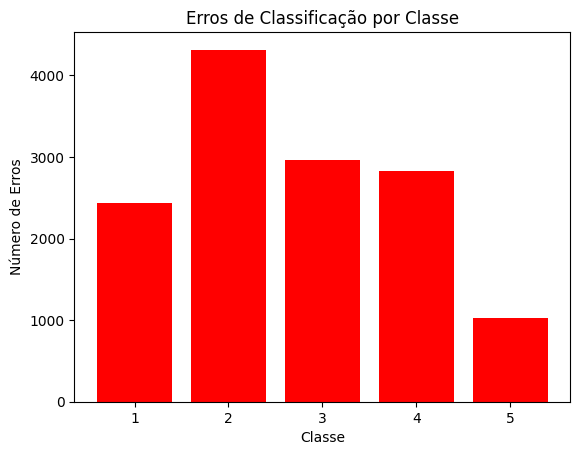

(5, 10180)
5 criticas bem classificadas:
Critica: 12 oz. bottle.  Pours a slightly hazy amber with a moderate head that faded away after a few minutes.  Very light aroma of malt and caramel.  Almost immediately, there is a dry bitterness that kicks in, but the beer itself lacks any flavor.  A bit thin. Disappointing.
Classificação: 1/5
Classificação do Modelo: 1
----------
Critica: 12oz bottle. Less than pleasant aroma of hay and dry dog food. That combination really reminded me of Christmas in an away in a manger sort of way. Poured a clear reddish orange color. The head was two fingers high and off white. It reduced over a minute or two to  a thin film and left a bit of lace behind on the glass. Light to medium bodied and dry. The flavor wasnt any better than the aroma; dry dog food, bitter grains, and unsalted whole wheat pretzel. Merry Christmas!
Classificação: 1/5
Classificação do Modelo: 1
----------
Critica: Name: XXX-mas Ale	Date: 12/16/1995	Mode: Draft	Source: Brewery		slightl

In [86]:
#classificar criticas muito boas
# classificacao_Multiclasse_1_Discriminante_Logistico("smell")

Classificação Multiclasse: Discriminante Logistico - taste
[3 3 1 ... 4 3 3]
oz pour dark brown with a red rim and off white head nose is most sweet malt with fair notic alcohol depend on the temperatur flavor is sweet malt with raisin and banana yeast with some slight spice on the finish veri true to the style but less than inspir
(75000,)
(75000,)
(25000,)
(25000,)
Tamanho do vocabulario: 10180
Resultados para classificar criticas:
Erros: 13270
--------------------
Score do Modelo: 0.4692
Score do Treino: 0.5305733333333333
--------------------
Matriz de Confusão:
[[2442 1137 1111  120   10]
 [ 768 1368 2854  388   18]
 [ 336  853 5254 1672   65]
 [  92  161 2320 2443  255]
 [  42   37  307  724  223]]
--------------------
Acuracy: 0.4692
--------------------


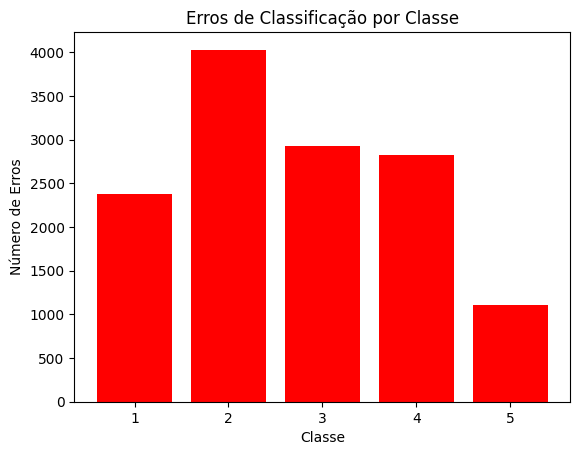

(5, 10180)
5 criticas bem classificadas:
Critica: 12 oz. bottle.  Pours a slightly hazy amber with a moderate head that faded away after a few minutes.  Very light aroma of malt and caramel.  Almost immediately, there is a dry bitterness that kicks in, but the beer itself lacks any flavor.  A bit thin. Disappointing.
Classificação: 1/5
Classificação do Modelo: 1
----------
Critica: 12oz bottle. Less than pleasant aroma of hay and dry dog food. That combination really reminded me of Christmas in an away in a manger sort of way. Poured a clear reddish orange color. The head was two fingers high and off white. It reduced over a minute or two to  a thin film and left a bit of lace behind on the glass. Light to medium bodied and dry. The flavor wasnt any better than the aroma; dry dog food, bitter grains, and unsalted whole wheat pretzel. Merry Christmas!
Classificação: 1/5
Classificação do Modelo: 1
----------
Critica: Name: XXX-mas Ale	Date: 12/16/1995	Mode: Draft	Source: Brewery		slightl

In [87]:
# classificacao_Multiclasse_1_Discriminante_Logistico("taste")

Classificação Multiclasse: Discriminante Logistico - overall
[4 6 4 ... 7 5 6]
oz pour dark brown with a red rim and off white head nose is most sweet malt with fair notic alcohol depend on the temperatur flavor is sweet malt with raisin and banana yeast with some slight spice on the finish veri true to the style but less than inspir
(75000,)
(75000,)
(25000,)
(25000,)
Tamanho do vocabulario: 10180
Resultados para classificar criticas:
Erros: 17426
--------------------
Score do Modelo: 0.30296
Score do Treino: 0.3804533333333333
--------------------
Matriz de Confusão:
[[ 306  123  280  370   21   31   17    4    1    1]
 [ 103   75  329  653   49   46   13    4    3    0]
 [  68   74  419 1690  173  177   75   17    2    4]
 [  43   52  311 3250  695  980  290   67   13    1]
 [  15    8   62 1515  635 1142  474  103   17    6]
 [   8   10   46  905  479 1480  759  268   47    8]
 [   5    7   26  494  254 1018  904  402   79   10]
 [   4    2   11  191  104  464  571  396  109   21]


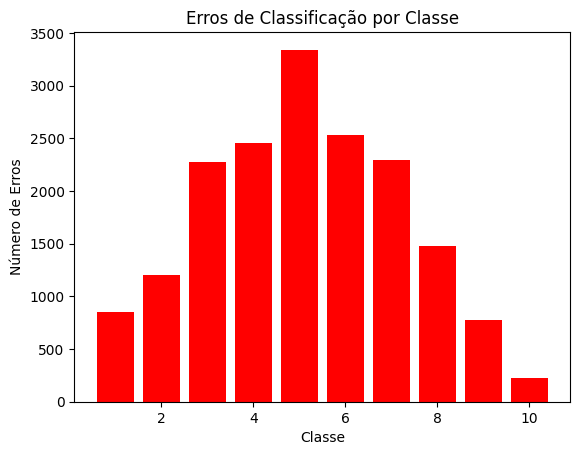

(10, 10180)
5 criticas bem classificadas:
Critica: Teaches me to buy a bottle of beer called "Turbodog" that didn't have a dog on it at all.  maybe they did have a dog on the label but it was smart and turboed out of there because it didn't want to be associated with this burnt choco-coffee smelling water.  i'm thinking that they just take water from the Mississippi River and bottle it...hence the color and the watery-ness.
Classificação: 1/10
Classificação do Modelo: 1
----------
Critica: Darkish red, with only a faint lacing.  Looks more like an alt to me.	I think this one is infected...Grainy, but also wet cardboard and skanky beauty salon permed hair smell.  Taste:  Heat stricken indeed, which is weird, because I got from a fridge, guess it got stored in the heat beforehand...Smokey, watery and just not very agreeable, this one ended up in the drain.
Classificação: 1/10
Classificação do Modelo: 1
----------
Critica: This stuff sucks.  They should call this Turboshwag.  Swells like 

In [88]:
# classificacao_Multiclasse_1_Discriminante_Logistico("overall")

Após o treino e teste com todos os dados, chegamos a estes valores:


Componente | Erros | Score Modelo | Score Treino | Acuracy | 
-----------|-------|--------------|--------------|---------|
smell      | 13567 | 0.45732      | 0.51645      | 0.4574  |
taste      | 13253 | 0.46988      | 0.53029      | 0.4692  |
overall    | 17435 | 0.3026      | 0.3804      | 0.30296  |
    

Podemos ver valores muito baixos em termos de score. Tendo uma percentagem de acertos inferior a 50%.

Matriz de confusão para smell:


| 2465 | 1185 | 1127 | 111  | 10  |
| 865  | 1613 | 3014 | 427  | 19  |
| 373  | 1014 | 5183 | 1483 | 70  |
| 104  | 202  | 2312 | 1984 | 227 |
|  34  | 31   | 322  | 637  | 188 |
|------|------|------|------|-----|

Matriz de confusão para taste:

| 2458 | 1113 | 1116 | 123  | 10  |
| 785  | 1351 | 2843 | 399  | 18  |
| 344  | 832  | 5246 | 1693 | 65  |
| 92   | 160  | 2296 | 2469 | 254 |
| 42   | 36   | 302  | 730  | 223 |
|------|------|------|------|-----|

Matriz de confusão para overall:

| 306  | 123  | 280  | 370  | 21  | 30  | 18  | 4   | 1   | 1   |
| 103  | 75   | 329  | 653  | 49  | 46  | 13  | 4   | 3   | 0   |
| 68   | 74   | 419  | 1687 | 175 | 178 | 75  | 17  | 2   | 4   |
| 43   | 52   | 312  | 3245 | 694 | 984 | 290 | 68  | 13  | 1   |
| 15   | 8    | 63   | 1511 | 635 | 1149| 468 | 105 | 16  | 7   |
| 8    | 10   | 46   | 903  | 480 | 1482| 759 | 267 | 47  | 8   |
| 5    | 7    | 26   | 493  | 254 | 1022| 902 | 401 | 78  | 11  |
| 4    | 2    | 12   | 190  | 104 | 465 | 572 | 393 | 109 | 22  |
| 2    | 0    | 7    | 82   | 41  | 148 | 239 | 243 | 88  | 16  |
| 1    | 0    | 4    | 17   | 4   | 32  | 53  | 73  | 41  | 20  |
|------|------|------|------|-----|-----|-----|-----|-----|-----|


## PCA

O método PCA á não supervisionado, sendo uqe não existe classes, onde é aplicado a todas os dados, não só as classes.
O objetivo de utilizar este método é reduzir a dimensão dos dados, tentando preservar o mais possivel  a variação presente nos dados de alta dimensão, sendo esta um método de pre-processamento de dados.
Ao reduzir o número de variáveis pode-se tornar o processo de classificação mais rápido e preciso, sendo que ao reduzir o número de variáveis, reduz-se também o número de parâmetros a serem treinados, o que pode levar a um melhor desempenho do modelo. Este método combina as variáveis originais em um conjunto de menor componentes principal, combinações lineares das variáveis, sendo estes componentes escolhidos de forma a maximizar a variância total nos dados.

Neste problema, onde estamos a utilizar dados de texto para classificar criticas, está-se a utilizar matrizes esparsas, onde o PCA pode não ser efeciente. Assim sendo, tem que se utilizar e testar o Truncated SVD (Singular Velue Decomposition), que é uma técnica relacionada com o PCA, mas efeciente para com matrizes esparsas. Neste problema, quando é criado o vocabulário, tem se uma matriz onde cada linha é um documento e cada coluna é as palavras do vocabulário com os valores correspondentes a frequencia no documento, sendo que a maioria das palavras vais estar a 0, tornando esta matriz esparsa, ou seja cada critica é representada por um vetor de grande dimensão, e o Truncated SVD reduz essa dimensão ficando com as mais importantes, sendo que se cria um vetor com a direção no espaço onde há mais variação.


Começando pelo vocabulário utilizado na classificação binária, pegamos nos documentos limpos aplicando o Steammer Snowball e a configuração do TfidfVectorizer: min_df=4, pattern=2, n-gramas (1, 1) Stop_Words=‘English’.

In [82]:
'''
função para vetorizar os documentos e guardar o vocabulario e os dados de treino e teste.

'''

def vetorizar_pca():
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    docs = np.array(docs)
    
    #construir e vetorizar
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(docs)
    docs_t = vectorizer.transform(docs)
    print(docs_t.shape)
    vocabulario = vectorizer.get_feature_names_out()
    #guardar o vetorizador e o vocabulario e a matriz
    name = "ficheirosPickel/pcaVectVoc.p"
    pickle.dump([vectorizer, vocabulario, docs_t], open(name, "wb"))

# vetorizar_pca()

(75000, 12836)


In [83]:
from sklearn.decomposition import TruncatedSVD


def truncatedSvd(n_components, docs_t, docs_teste_t, vocabulario):

    # Aplicar TruncatedSVD
    svd = TruncatedSVD(n_components=n_components).fit(docs_t)
    docs_treino_svd = svd.transform(docs_t)
    docs_teste_svd = svd.transform(docs_teste_t)

    cumulative_variance_ratio = np.cumsum(svd.explained_variance_ratio_)


    
    print("\nEstatísticas após o Truncated SVD Treino:")
    print(pd.DataFrame(docs_treino_svd).describe())
    print("\nEstatísticas após o Truncated SVD Teste:")
    print(pd.DataFrame(docs_teste_svd).describe())

    # Visualizar o tamanho da matriz após o TruncatedSVD
    print("Tamanho da matriz antes o TruncatedSVD:", docs_t.shape)
    print("Tamanho da matriz após o TruncatedSVD:", docs_treino_svd.shape)
    print("Tamanho da matriz antes Teste o TruncatedSVD:", docs_teste_t.shape)
    print("Tamanho da matriz após Teste o TruncatedSVD:", docs_teste_svd.shape)
    
        # Plotar a variância acumulada
    plt.plot(cumulative_variance_ratio)
    plt.xlabel('Número de Componentes')
    plt.ylabel('Variância Acumulada')
    plt.title('Análise de Variância Acumulada')
    plt.show()
    
    return docs_treino_svd, docs_teste_svd





Verificar o melhor numero de componentes

In [84]:
def pca_binario_teste(X_train, X_test, y_train, y_test, vocabulario):
    # Testar diferentes números de componentes principais
    for n_components in [10, 50, 100, 1000]:
        print("\n\n\n")
        X_train_svd, X_test_svd = truncatedSvd(n_components,X_train, X_test, vocabulario)

        score_crossVal, erros, score_modelo, dist_crp, ponto_ideal_crp_prec, ponto_ideal_crp_rec, dist_roc, ponto_ideal_roc_fpr, ponto_ideal_roc_tpr = linearRegression_3(X_train_svd, X_test_svd, y_train, y_test, 1, 'l2')
    
        print(f"Number of components: {n_components}")
        print(f"Cross-validation score: {score_crossVal}")
        print(f"Test score: {score_modelo}")
        print(f"Erros: {erros}")
        print(f"Distancia crp: {dist_crp}")
        print(f"Ponto ideal crp prec: {ponto_ideal_crp_prec}")
        print(f"Ponto ideal crp rec: {ponto_ideal_crp_rec}")
        print(f"Distancia roc: {dist_roc}")
        print(f"Ponto ideal roc fpr: {ponto_ideal_roc_fpr}")
        print(f"Ponto ideal roc tpr: {ponto_ideal_roc_tpr}")
        print("--------------------------------------------------")





Estatísticas após o Truncated SVD Treino:
                  0             1             2             3             4  \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       0.237223     -0.001897     -0.010072     -0.005351     -0.003498   
std        0.073664      0.113286      0.086813      0.080700      0.072317   
min        0.000128     -0.285798     -0.295200     -0.324242     -0.310901   
25%        0.187313     -0.080957     -0.066722     -0.060244     -0.050668   
50%        0.236295     -0.031087     -0.019150     -0.007583     -0.008352   
75%        0.286551      0.058144      0.033265      0.047550      0.039050   
max        0.519255      0.549964      0.543497      0.395211      0.374399   

                  5             6             7             8             9  
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000  
mean      -0.001668      0.001271      0.000369     -0.002528     -0.003121  
std     

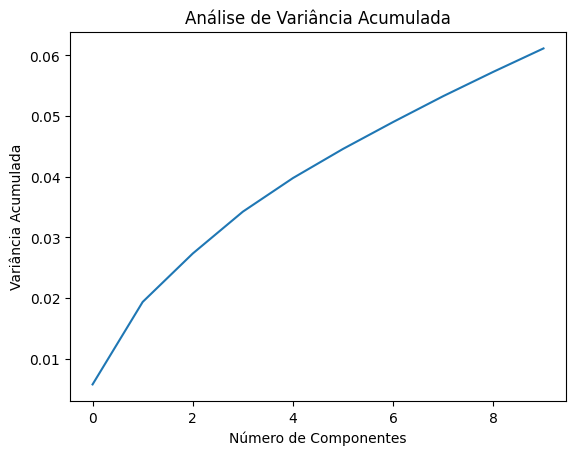

Linear Regression
Matriz de Confusão:
[[23298    18]
 [ 1677     7]]
precisão: 0.28
recall: 0.004156769596199525
Number of components: 10
Cross-validation score: [0.9317 0.9313 0.9321 0.9318 0.9325]
Test score: 0.9322
Erros: 1695
Distancia crp: 0.9048702393168118
Ponto ideal crp prec: 0.10586259764912025
Ponto ideal crp rec: 0.8610451306413301
Distancia roc: 0.4478738872283967
Ponto ideal roc fpr: 0.3305026591182021
Ponto ideal roc tpr: 0.6977434679334917
--------------------------------------------------




Estatísticas após o Truncated SVD Treino:
                 0             1             2             3             4   \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       0.237223     -0.001897     -0.010070     -0.005348     -0.003508   
std        0.073664      0.113286      0.086813      0.080701      0.072323   
min        0.000128     -0.285810     -0.295165     -0.324088     -0.309584   
25%        0.187313     -0.080953     -0.066710 

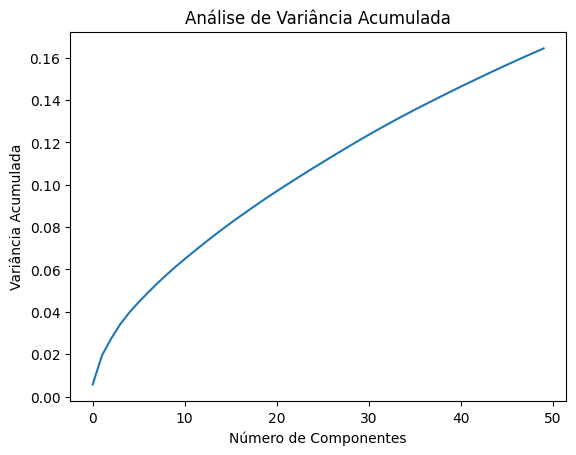

Linear Regression
Matriz de Confusão:
[[23278    38]
 [ 1642    42]]
precisão: 0.525
recall: 0.02494061757719715
Number of components: 50
Cross-validation score: [0.9326 0.9322 0.9334 0.9326 0.9327]
Test score: 0.9328
Erros: 1680
Distancia crp: 0.8741473833098877
Ponto ideal crp prec: 0.1455837132859718
Ponto ideal crp rec: 0.8153206650831354
Distancia roc: 0.37684912635759277
Ponto ideal roc fpr: 0.2825098644707497
Ponto ideal roc tpr: 0.7505938242280285
--------------------------------------------------




Estatísticas após o Truncated SVD Treino:
                 0             1             2             3             4   \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       0.237223     -0.001897     -0.010070     -0.005348     -0.003508   
std        0.073664      0.113286      0.086813      0.080701      0.072323   
min        0.000128     -0.285810     -0.295168     -0.324103     -0.309634   
25%        0.187313     -0.080953     -0.066712 

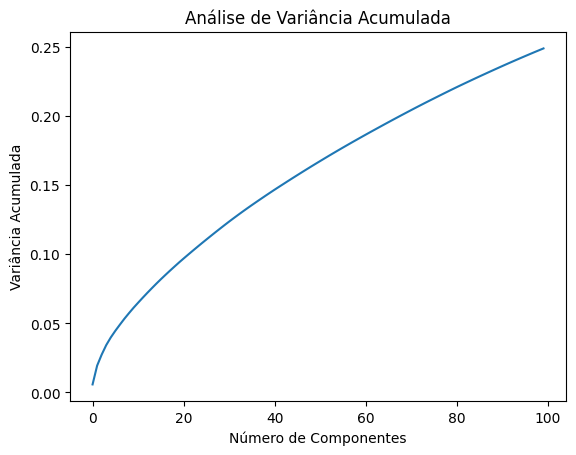

Linear Regression
Matriz de Confusão:
[[23264    52]
 [ 1626    58]]
precisão: 0.5272727272727272
recall: 0.0344418052256532
Number of components: 100
Cross-validation score: [0.9327 0.9322 0.9337 0.9335 0.9331]
Test score: 0.93288
Erros: 1678
Distancia crp: 0.8604197517700687
Ponto ideal crp prec: 0.17353020861555135
Ponto ideal crp rec: 0.7606888361045131
Distancia roc: 0.3545967127671829
Ponto ideal roc fpr: 0.26166580888660146
Ponto ideal roc tpr: 0.7606888361045131
--------------------------------------------------

Estatísticas após o Truncated SVD Treino:
                0             1             2             3             4    \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       0.237223     -0.001897     -0.010070     -0.005348     -0.003508   
std        0.073664      0.113286      0.086813      0.080701      0.072323   
min        0.000128     -0.285810     -0.295169     -0.324106     -0.309625   
25%        0.187313     -0.080953   

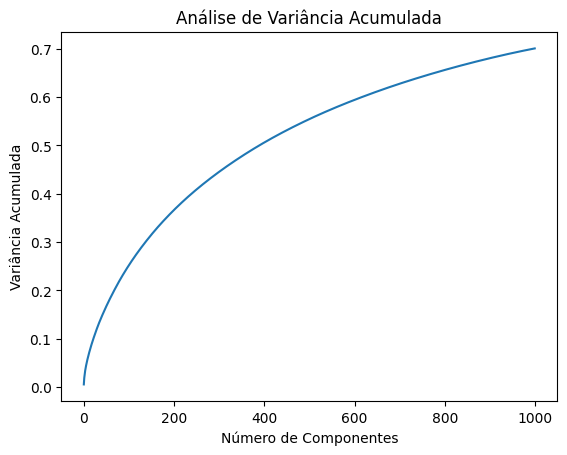

Linear Regression
Matriz de Confusão:
[[23194   122]
 [ 1498   186]]
precisão: 0.6038961038961039
recall: 0.11045130641330166
Number of components: 1000
Cross-validation score: [0.9368 0.934  0.9356 0.9339 0.9363]
Test score: 0.9352
Erros: 1620
Distancia crp: 0.8172586641056507
Ponto ideal crp prec: 0.2574878105409798
Ponto ideal crp rec: 0.6585510688836105
Distancia roc: 0.31350536047099803
Ponto ideal roc fpr: 0.23627551895693943
Ponto ideal roc tpr: 0.7939429928741093
--------------------------------------------------


In [85]:
def testar_pca():
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    docs = np.array(docs)
    y = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTrain])

    # Criar divisões de treinamento e teste
    X_train, X_test, y_train, y_test = train_test_split(docs, y, test_size=1/3, stratify=y)


    # Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)

    vocabulario = vectorizer.get_feature_names_out()
    
    # Aplicar TruncatedSVD
    pca_binario_teste(X_train_t, X_test_t, y_train, y_test, vocabulario)

testar_pca()


Fazendo uma tabela para analizar os resultados e decidir o numero de componetes a utilizar:

| n_components | Cross-validation score | Test score | Erros | Distancia crp | precisao | recall | Distancia roc |
|--------------|------------------------|------------|-------|---------------|----------|--------|---------------|
| 10           | 0.9319                 | 0.9322     | 1695  | 0.904870239   | 0.28     | 0.004  | 0.447873887   |
| 50           | 0.9327                 | 0.9328     | 1680  | 0.874147383   | 0.525    | 0.024  | 0.376849126   |
| 100          | 0.9330                 | 0.93288    | 1678  | 0.860419751   | 0.527    | 0.034  | 0.354596712   |
| 1000         | 0.9353                 | 0.9352     | 1620  | 0.817258664   | 0.603    | 0.110  | 0.313505360   |

10 componetes

| 23298 | 18 |
| 1677  | 7 |
|-------|---|

50 Componentes

| 23278 | 38 |
| 1642  | 42 |
|-------|---|

100 Componentes

| 23264 | 52 |
| 1626  | 58 |
|-------|---|

1000 Componentes

| 23194 | 122 |
| 1498  | 186 |
|-------|---|


Podemos verificar que o melhor resultado é com 1000 componentes, sendo que vai sempre melhorando com o aumento do numero de componentes. Contudo, quanto mais componentes, mais tempo demora.

In [86]:
def pca_final_binario(muito_bom):
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    X_train = np.array(docs)
    if muito_bom:
        y_train = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTrain])
    else:
        y_train = np.array([1 if int(beerDictTrain[idx]['overall'].split('/')[0]) <= 2 else -1 for idx in beerDictTrain])
    
    docs_teste = pickle.load(open("ficheirosPickel/documentos_teste_snowball.p", "rb"))
    X_test = np.array(docs_teste)
    if muito_bom:
        y_test = np.array([1 if int(beerDictTest[idx]['overall'].split('/')[0]) >= 9 else -1 for idx in beerDictTest])
    else:
        y_test = np.array([1 if int(beerDictTest[idx]['overall'].split('/')[0]) <= 2 else -1 for idx in beerDictTest])

   

    # Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)

    vocabulario = vectorizer.get_feature_names_out()
    
    X_train_svd, X_test_svd = truncatedSvd(1000,X_train_t, X_test_t, vocabulario)

    score_crossVal, erros, score_modelo, dist_crp, ponto_ideal_crp_prec, ponto_ideal_crp_rec, dist_roc, ponto_ideal_roc_fpr, ponto_ideal_roc_tpr = linearRegression_3(X_train_svd, X_test_svd, y_train, y_test, 1, 'l2')

    print(f"Number of components: {1000}")
    print(f"Cross-validation score: {score_crossVal}")
    print(f"Test score: {score_modelo}")
    print(f"Erros: {erros}")
    print(f"Distancia crp: {dist_crp}")
    print(f"Ponto ideal crp prec: {ponto_ideal_crp_prec}")
    print(f"Ponto ideal crp rec: {ponto_ideal_crp_rec}")
    print(f"Distancia roc: {dist_roc}")
    print(f"Ponto ideal roc fpr: {ponto_ideal_roc_fpr}")
    print(f"Ponto ideal roc tpr: {ponto_ideal_roc_tpr}")
    print("--------------------------------------------------")




Estatísticas após o Truncated SVD Treino:
                0             1             2             3             4    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean       0.235909     -0.001852     -0.009846     -0.005689     -0.003490   
std        0.073799      0.112519      0.086322      0.080368      0.072144   
min        0.000018     -0.287647     -0.298257     -0.315333     -0.311493   
25%        0.186071     -0.080291     -0.065866     -0.060582     -0.050550   
50%        0.234988     -0.030503     -0.019011     -0.007874     -0.008698   
75%        0.285100      0.058509      0.032418      0.047208      0.038831   
max        0.559744      0.549519      0.548695      0.393848      0.375728   

                5             6             7             8             9    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean      -0.001927      0.001164     -0.000134     -0.002311     -0.003278   
std     

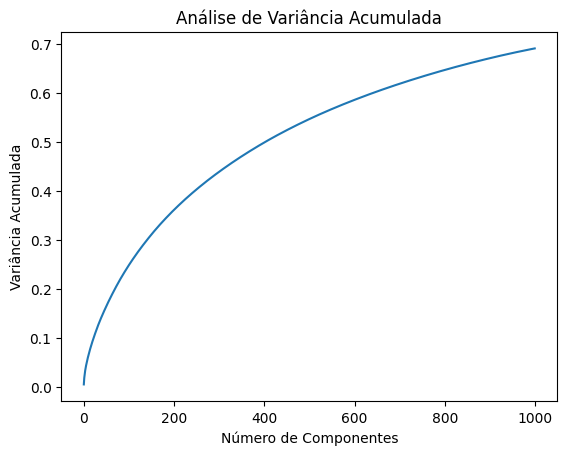

Linear Regression
Matriz de Confusão:
[[23791    98]
 [ 1021    90]]
precisão: 0.4787234042553192
recall: 0.081008100810081
Number of components: 1000
Cross-validation score: [0.9342     0.93586667 0.9348     0.93573333 0.93573333]
Test score: 0.95524
Erros: 1119
Distancia crp: 0.876145666725712
Ponto ideal crp prec: 0.19883527454242927
Ponto ideal crp rec: 0.6453645364536453
Distancia roc: 0.299637109356274
Ponto ideal roc fpr: 0.20670601532085897
Ponto ideal roc tpr: 0.783078307830783
--------------------------------------------------


In [87]:
pca_final_binario(True)


Estatísticas após o Truncated SVD Treino:
                0             1             2             3             4    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean       0.235909     -0.001852     -0.009846     -0.005689     -0.003490   
std        0.073799      0.112519      0.086322      0.080368      0.072144   
min        0.000018     -0.287647     -0.298257     -0.315333     -0.311493   
25%        0.186071     -0.080291     -0.065866     -0.060582     -0.050550   
50%        0.234988     -0.030503     -0.019011     -0.007874     -0.008698   
75%        0.285100      0.058509      0.032418      0.047208      0.038831   
max        0.559744      0.549519      0.548695      0.393848      0.375728   

                5             6             7             8             9    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean      -0.001927      0.001164     -0.000134     -0.002311     -0.003278   
std     

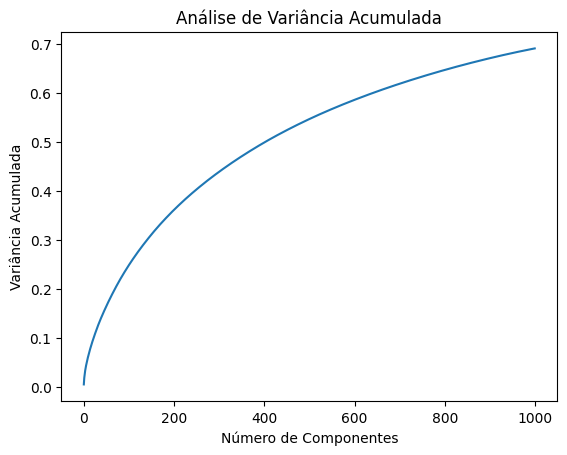

Linear Regression
Matriz de Confusão:
[[22432   139]
 [ 1999   430]]
precisão: 0.7557117750439367
recall: 0.17702758336764102
Number of components: 1000
Cross-validation score: [0.95966667 0.958      0.95893333 0.95733333 0.95933333]
Test score: 0.91448
Erros: 2138
Distancia crp: 0.6244958007211283
Ponto ideal crp prec: 0.5191897654584222
Ponto ideal crp rec: 0.601482091395636
Distancia roc: 0.25097093003310883
Ponto ideal roc fpr: 0.19458597315138895
Ponto ideal roc tpr: 0.8414985590778098
--------------------------------------------------


In [88]:
pca_final_binario(False)


Aqui recorda-se os valores obtidos anteriormente

| Metrica         | Classificar Muito Boas | Classificar Muito Más |
|-----------------|------------------------|-----------------------|
| Erros           | 1117                   | 2051                  |
| Score do Modelo | 0.95532                | 0.91796               |
| Score do Treino | 0.93999                | 0.96391               |
| Precisão        | 0.9996                 | 0.9943                |
| Recall          | 0.9657                 | 0.9211                |
| F1-score        | 0.9591                 | 0.9563                |
| TPositivos      | 23785                  | 22442                 |
| TNegativos      | 98                     | 507                   |
| FPositivos      | 1013                   | 1922                  |
| FNegativos      | 104                    | 129                   |

Aqui os resultados com o PCA


| Metrica         | Classificar Muito Boas | Classificar Muito Más |
|-----------------|------------------------|-----------------------|
| Erros           | 1119                   | 1000                  |
| Score do Modelo | 0.9352                 | 0.9586                |
| Score do Treino | 0.95524                | 0.91448               |
| Precisão        | 0.4787                 | 0.7557                |
| Recall          | 0.081                  | 0.1770                |
| TPositivos      | 23791                  | 22432                 |
| TNegativos      | 90                     | 430                   |
| FPositivos      | 1021                   | 1999                  |
| FNegativos      | 98                     | 139                   |

Os resultados apresentaram uma melhoria, sendo que já não parece estar em overfitting, contudo o recall está bastante baixo. Se se aumentar o numero de componentes, poderá haver ainda melhor resultados.


## PCA - Multiclasse

Utilizando o mesmo metodo, de procurar o melhor numero de componentes, mas agora para o classificador multi-class. Testando o numero de componentes com o "smell".

In [66]:
def pca_MC_teste(X_train, X_test, y_train, y_test, vocabulario):
    # Testar diferentes números de componentes principais
    for n_components in [10, 50, 100, 1000]:
        print("\n\n\n")
        X_train_svd, X_test_svd = truncatedSvd(n_components,X_train, X_test, vocabulario)
    
        lr = LogisticRegression(C=1, max_iter=5000, penalty='l1', solver='saga', tol=1e-2).fit(X_train_svd, y_train)
        y_pred = lr.predict(X_test_svd)
        
    
        erros = np.sum(y_test != y_pred)
        score_modelo = lr.score(X_test_svd, y_test)
        score_treino = lr.score(X_train_svd, y_train)
    
        matriz_confusao = confusion_matrix(y_test, y_pred)
    
        precisao = matriz_confusao[0][0] / (matriz_confusao[0][0] + matriz_confusao[0][1])
        recall = matriz_confusao[0][0] / (matriz_confusao[0][0] + matriz_confusao[1][0])
        f1_score = 2 * (precisao * recall) / (precisao + recall)
     
        print("Numero de componentes:", n_components)
        print("Erros:", erros)
        print("--------------------")
        print("Score do Modelo:", score_modelo)
        print("Score do Treino:", score_treino)
        print("--------------------")
        print("Matriz de Confusão:")
        print(matriz_confusao)
        print("--------------------")
        print("Precisão:", precisao)
        print("Recall:", recall)
        print("F1-score:", f1_score)
        print("--------------------")






Estatísticas após o Truncated SVD Treino:
                  0             1             2             3             4  \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       0.239652     -0.004046     -0.010919      0.002172     -0.003869   
std        0.075520      0.115628      0.089071      0.079526      0.075081   
min        0.000015     -0.272716     -0.317828     -0.352640     -0.345494   
25%        0.188500     -0.083826     -0.068717     -0.048972     -0.052543   
50%        0.238345     -0.035637     -0.019248     -0.000745     -0.008263   
75%        0.289874      0.052920      0.033384      0.051841      0.041140   
max        0.554161      0.558038      0.537981      0.358701      0.359805   

                  5             6             7             8             9  
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000  
mean      -0.001544      0.001986      0.001104     -0.002325      0.004123  
std     

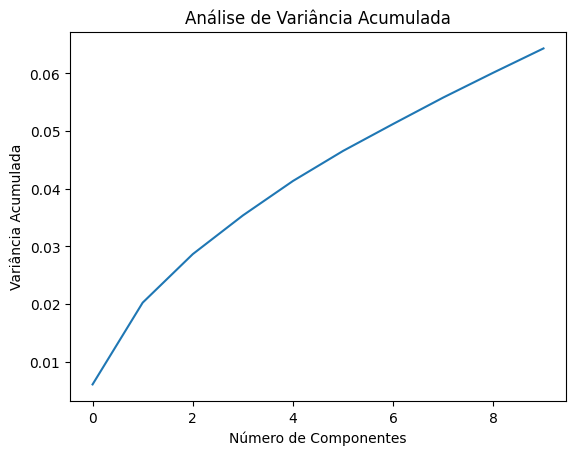

Numero de componentes: 10
Erros: 15066
--------------------
Score do Modelo: 0.39736
Score do Treino: 0.39614
--------------------
Matriz de Confusão:
[[ 750  248 1608  110    3]
 [ 472  412 3441  388    9]
 [ 375  340 6632 1547   21]
 [ 208   82 4245 2111   22]
 [  78   13 1042  814   29]]
--------------------
Precisão: 0.751503006012024
Recall: 0.613747954173486
F1-score: 0.6756756756756757
--------------------




Estatísticas após o Truncated SVD Treino:
                 0             1             2             3             4   \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       0.239652     -0.004046     -0.010914      0.002175     -0.003839   
std        0.075520      0.115628      0.089073      0.079527      0.075130   
min        0.000015     -0.272715     -0.318707     -0.352652     -0.351599   
25%        0.188500     -0.083822     -0.068742     -0.049010     -0.052497   
50%        0.238345     -0.035640     -0.019218     -0.000738  

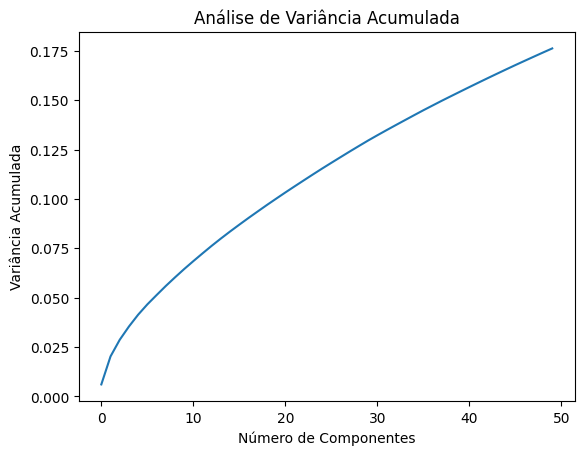

Numero de componentes: 50
Erros: 14307
--------------------
Score do Modelo: 0.42772
Score do Treino: 0.42654
--------------------
Matriz de Confusão:
[[1034  420 1099  161    5]
 [ 617  773 2876  449    7]
 [ 418  552 5991 1913   41]
 [ 187  128 3481 2790   82]
 [  69   16  667 1119  105]]
--------------------
Precisão: 0.7111416781292985
Recall: 0.6262870987280436
F1-score: 0.6660225442834138
--------------------




Estatísticas após o Truncated SVD Treino:
                 0             1             2             3             4   \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       0.239652     -0.004046     -0.010914      0.002174     -0.003839   
std        0.075520      0.115628      0.089073      0.079527      0.075130   
min        0.000015     -0.272715     -0.318690     -0.352689     -0.351658   
25%        0.188500     -0.083823     -0.068740     -0.049000     -0.052477   
50%        0.238345     -0.035640     -0.019213     -0.000730

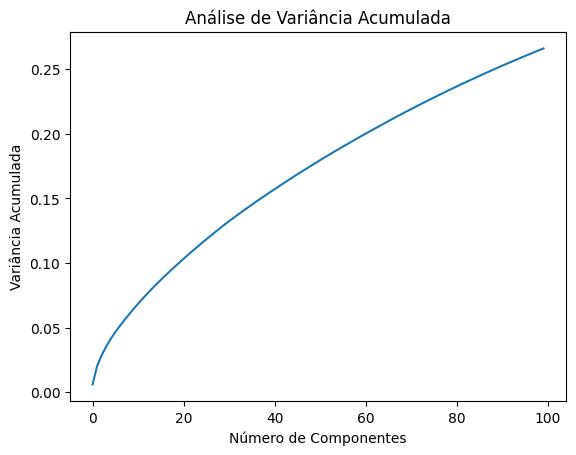

Numero de componentes: 100
Erros: 14040
--------------------
Score do Modelo: 0.4384
Score do Treino: 0.4389
--------------------
Matriz de Confusão:
[[1115  418 1039  141    6]
 [ 619  808 2847  436   12]
 [ 378  530 6100 1863   44]
 [ 159  122 3483 2807   97]
 [  62   14  651 1119  130]]
--------------------
Precisão: 0.7273320287018917
Recall: 0.6430219146482122
F1-score: 0.6825834098561372
--------------------




Estatísticas após o Truncated SVD Treino:
                0             1             2             3             4    \
count  50000.000000  50000.000000  50000.000000  50000.000000  50000.000000   
mean       0.239652     -0.004046     -0.010914      0.002174     -0.003839   
std        0.075520      0.115628      0.089073      0.079527      0.075130   
min        0.000015     -0.272715     -0.318689     -0.352692     -0.351657   
25%        0.188500     -0.083823     -0.068740     -0.048997     -0.052477   
50%        0.238345     -0.035640     -0.019214     -0.000734 

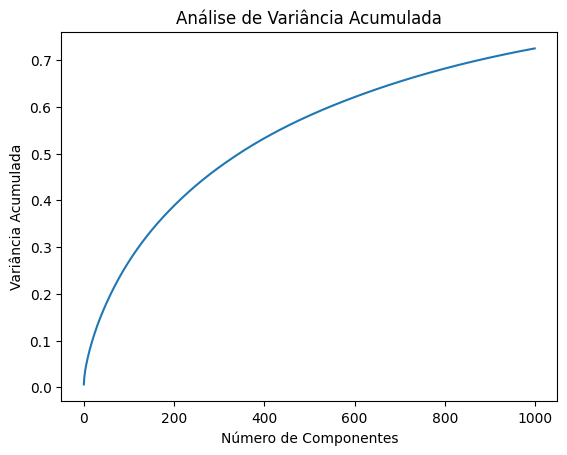

Numero de componentes: 1000
Erros: 13633
--------------------
Score do Modelo: 0.45468
Score do Treino: 0.48968
--------------------
Matriz de Confusão:
[[1189  622  786  113    9]
 [ 585 1102 2619  400   16]
 [ 309  805 5853 1875   73]
 [ 120  180 3241 2873  254]
 [  32   28  514 1052  350]]
--------------------
Precisão: 0.6565433462175594
Recall: 0.6702367531003383
F1-score: 0.6633193863319387
--------------------


In [67]:
def testar_pca_MC():
    
    #Passo 1: Carregar os dados de teste, estes já esão limpos
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    docs = np.array(docs)
    
    y = np.array([int(beerDictTrain[idx]['smell'].split('/')[0]) for idx in beerDictTrain])

    # Criar divisões de treinamento e teste
    X_train, X_test, y_train, y_test = train_test_split(docs, y, test_size=1/3, stratify=y)


    # Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=5, stop_words='english', token_pattern=r'\b\w\w\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)

    vocabulario = vectorizer.get_feature_names_out()
    
    # Aplicar TruncatedSVD
    pca_MC_teste(X_train_t, X_test_t, y_train, y_test, vocabulario)

testar_pca_MC()


Vendo os resultados numa tabela

| n_components | Erros | Score do Modelo | Score do Treino | Precisão | Recall | F1-score |
|--------------|-------|-----------------|-----------------|----------|--------|----------|
| 10           | 15066 | 0.39736         | 0.39614         | 0.7515   | 0.6137 | 0.6757   |
| 50           | 14307 | 0.42772         | 0.42654         | 0.7111   | 0.6262 | 0.6660   |
| 100          | 14040 | 0.4384          | 0.4389          | 0.7273   | 0.6430 | 0.6825   |
| 1000         | 13633 | 0.45468         | 0.48968         | 0.6565   | 0.6702 | 0.6633   |

Pode-se utilizar o 1000 sendo que é o que tem menos erros e o melhor score. 

In [89]:
def pca_final_MC(componente):
    
    print(componente)
    print("----------")
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    X_train = np.array(docs)

    y_train = np.array([int(beerDictTrain[idx][componente].split('/')[0]) for idx in beerDictTrain])

    X_test_limpos_lancaster = pickle.load(open("ficheirosPickel/Multiclasse/Multi_classe_documentos_teste_snowball_v2.p", "rb"))
    X_test = np.array(X_test_limpos_lancaster)
    y_test = np.array([int(beerDictTest[idx][componente].split('/')[0]) for idx in beerDictTest])

    
    # Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=5, stop_words='english', token_pattern=r'\b\w\w\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)

    vocabulario = vectorizer.get_feature_names_out()
    
    X_train_svd, X_test_svd = truncatedSvd(1000,X_train_t, X_test_t, vocabulario)

    lr = LogisticRegression(C=1, max_iter=5000, penalty='l1', solver='saga', tol=1e-2).fit(X_train_svd, y_train)
    y_pred = lr.predict(X_test_svd)
    

    erros = np.sum(y_test != y_pred)
    score_modelo = lr.score(X_test_svd, y_test)
    score_treino = lr.score(X_train_svd, y_train)

    matriz_confusao = confusion_matrix(y_test, y_pred)

    

    
    acuracy = accuracy_score(y_test, y_pred)


    #perc
    #Passo 11: Fazer print dos resultados
    

    print("Resultados para classificar criticas:")

    print("Erros:", erros)
    print("--------------------")
    print("Score do Modelo:", score_modelo)
    print("Score do Treino:", score_treino)
    print("--------------------")
    print("Matriz de Confusão:")
    print(matriz_confusao)
    print("--------------------")
    print("Acuracy:", acuracy)


    print("--------------------")


smell
----------

Estatísticas após o Truncated SVD Treino:
                0             1             2             3             4    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean       0.238020     -0.003950     -0.010945      0.002186     -0.003847   
std        0.075639      0.114745      0.088688      0.078992      0.074621   
min        0.000000     -0.272490     -0.318123     -0.353057     -0.355496   
25%        0.186605     -0.083156     -0.067883     -0.048436     -0.052065   
50%        0.236528     -0.035038     -0.019628     -0.000305     -0.008267   
75%        0.288303      0.053344      0.033140      0.051921      0.040600   
max        0.554216      0.555411      0.538703      0.389170      0.356818   

                5             6             7             8             9    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean      -0.001597      0.001331      0.001836     -0.002045     -0.0

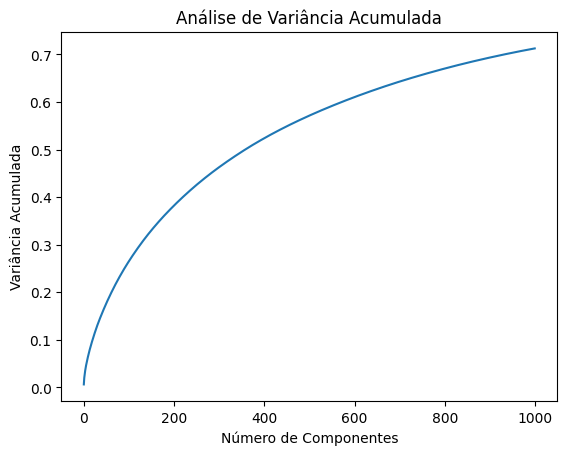

Resultados para classificar criticas:
Erros: 13437
--------------------
Score do Modelo: 0.46252
Score do Treino: 0.48673333333333335
--------------------
Matriz de Confusão:
[[2567 1071 1166   85    9]
 [ 928 1574 3030  386   20]
 [ 403  957 5230 1470   63]
 [ 131  178 2310 2020  190]
 [  48   24  339  629  172]]
--------------------
Acuracy: 0.46252
--------------------


In [90]:
pca_final_MC("smell")

taste
----------

Estatísticas após o Truncated SVD Treino:
                0             1             2             3             4    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean       0.238020     -0.003950     -0.010945      0.002186     -0.003847   
std        0.075639      0.114745      0.088688      0.078992      0.074621   
min        0.000000     -0.272490     -0.318123     -0.353057     -0.355496   
25%        0.186605     -0.083156     -0.067883     -0.048436     -0.052065   
50%        0.236528     -0.035038     -0.019628     -0.000305     -0.008267   
75%        0.288303      0.053344      0.033140      0.051921      0.040600   
max        0.554216      0.555411      0.538703      0.389170      0.356818   

                5             6             7             8             9    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean      -0.001597      0.001331      0.001836     -0.002045     -0.0

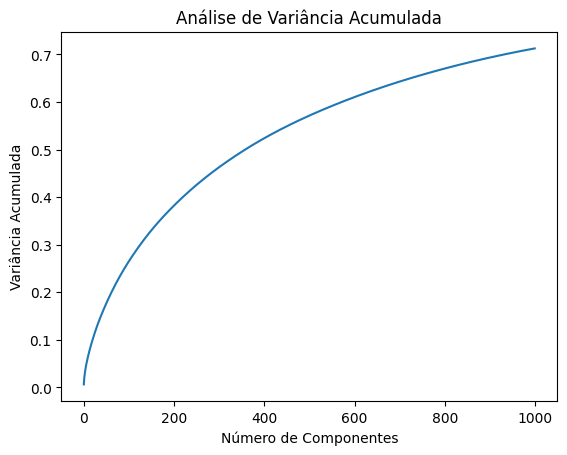

Resultados para classificar criticas:
Erros: 13257
--------------------
Score do Modelo: 0.46972
Score do Treino: 0.49938666666666665
--------------------
Matriz de Confusão:
[[2474 1073 1143  124    6]
 [ 863 1293 2849  369   22]
 [ 396  771 5313 1652   48]
 [ 106  149 2342 2453  221]
 [  43   31  326  723  210]]
--------------------
Acuracy: 0.46972
--------------------


In [91]:
pca_final_MC("taste")

overall
----------

Estatísticas após o Truncated SVD Treino:
                0             1             2             3             4    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean       0.238020     -0.003950     -0.010945      0.002186     -0.003847   
std        0.075639      0.114745      0.088688      0.078992      0.074621   
min        0.000000     -0.272490     -0.318123     -0.353057     -0.355496   
25%        0.186605     -0.083156     -0.067883     -0.048436     -0.052065   
50%        0.236528     -0.035038     -0.019628     -0.000305     -0.008267   
75%        0.288303      0.053344      0.033140      0.051921      0.040600   
max        0.554216      0.555411      0.538703      0.389170      0.356818   

                5             6             7             8             9    \
count  75000.000000  75000.000000  75000.000000  75000.000000  75000.000000   
mean      -0.001597      0.001331      0.001836     -0.002045     -0

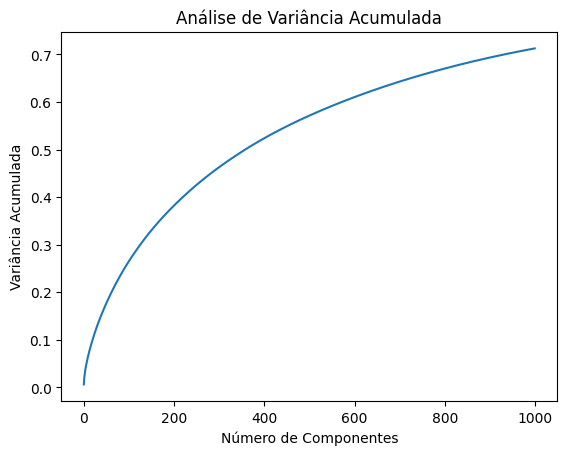

Resultados para classificar criticas:
Erros: 17443
--------------------
Score do Modelo: 0.30228
Score do Treino: 0.3432133333333333
--------------------
Matriz de Confusão:
[[ 303   95  271  413   14   39   12    4    2    1]
 [ 102   66  326  678   35   50   12    4    1    1]
 [  79   53  387 1772  121  197   66   17    4    3]
 [  77   41  297 3328  570 1055  267   55    9    3]
 [  18    7   62 1582  526 1218  436  105   19    4]
 [  14    7   39  953  420 1564  726  241   38    8]
 [  11    2   20  540  219 1044  889  394   70   10]
 [  10    3   11  204   78  489  579  387   94   18]
 [   4    0    6   99   28  168  222  234   90   15]
 [   5    0    4   20    2   32   57   71   37   17]]
--------------------
Acuracy: 0.30228
--------------------


In [92]:
pca_final_MC("overall")

Recordando os resultados obtidos anteriormente sem PCA

| Componente | Erros | Score Modelo | Score Treino | Acuracy | 
|------------|-------|--------------|--------------|---------|
| smell      | 13567 | 0.45732      | 0.51645      | 0.4574  |
| taste      | 13253 | 0.46988      | 0.53029      | 0.4692  |
| overall    | 17435 | 0.3026       | 0.3804       | 0.30296 |
 
Adicionando agora os valores obtidos com o PCA

| Componente | Erros | Score Modelo | Score Treino | Acuracy |
|------------|-------|--------------|--------------|----------|
| smell      | 13364 | 0.46544      | 0.48581      | 0.46252  |
| taste      | 13289 | 0.46844      | 0.49845      | 0.46972  |
| overall    | 17478 | 0.30088      | 0.34234      | 0.30228  |

Verificamos que os resultados dsão parecidos, melhorando a classificação do smell, porem os outros componentes ficaram parecidos, sendo que se se explorasse outra quantidade de componentes se poderia obter melhores resultados.

Usar o PCA faz o processo demorar mais, onde os resultados são parecidos pelo que, se tempo for uma questão importante para o porblema, não se deve utilizar o PCA.



## Classificação Binaria 2ª Abordagem

Nesta segunda abordagem a classificação binária, ignorou-se as criticas intermédias, sendo que se classificou como -1 as criticas muito más, e 1 as criticas muito boas, utilizou-se as mesmas funções, e as mesmas etapas.

In [ ]:
def executar_teste_de_stemmers_e_vetorizacao():
   
    
    #documentoa limpoa sem stemming
    docs = pickle.load(open("ficheirosPickel/documentos_limpos.p", "rb"))
    docs = np.array(docs)
    
    overall = np.array([int(beerDictTrain[idx]['overall'].split('/')[0]) for idx in beerDictTrain])
    docs_muitoboms_muitomaus = []
    indx_criticas = [] 
    y = []
    for idx in range(len(docs)):
        if overall[idx] >= 9:
            docs_muitoboms_muitomaus.append(docs[idx])
            indx_criticas.append(idx)
            y.append(1)

        elif overall[idx] <= 2:
            docs_muitoboms_muitomaus.append(docs[idx])
            indx_criticas.append(idx)
            y.append(-1)

    
    
    docs_muitoboms_muitomaus = np.array(docs_muitoboms_muitomaus)
    y = np.array(y)
    print(docs_muitoboms_muitomaus.shape)
    print(y.shape)
    
    
    dicionario_limpos = teste_logistic_Regression("Limpos", docs_muitoboms_muitomaus, y)
    pickle.dump(dicionario_limpos, open("ficheirosPickel/dicionario_limpos_dl_v2.p", "wb"))

    
    #documentos porter
    docs = pickle.load(open("ficheirosPickel/documentos_porter.p", "rb"))
    docs = np.array(docs)
    overall = np.array([int(beerDictTrain[idx]['overall'].split('/')[0]) for idx in beerDictTrain])

    docs_muitoboms_muitomaus = []
    y = []
    for idx in range(len(docs)):
        if overall[idx] >= 9:
            docs_muitoboms_muitomaus.append(docs[idx])
            y.append(1)
        elif overall[idx] <= 2:
            docs_muitoboms_muitomaus.append(docs[idx])
            y.append(-1)
    
    
    docs_muitoboms_muitomaus = np.array(docs_muitoboms_muitomaus)
    y = np.array(y)
    print(docs_muitoboms_muitomaus.shape)
    print(y.shape)

    
    dicionario_porter = teste_logistic_Regression("Porter", docs_muitoboms_muitomaus, y)
    
    pickle.dump(dicionario_porter, open("ficheirosPickel/dicionario_porter_dl_v2.p", "wb"))

    
    #documentos snowball
    docs = pickle.load(open("ficheirosPickel/documentos_snowball.p", "rb"))
    docs = np.array(docs)
    overall = np.array([int(beerDictTrain[idx]['overall'].split('/')[0]) for idx in beerDictTrain])

    docs_muitoboms_muitomaus = []
    y = []
    for idx in range(len(docs)):
        if overall[idx] >= 9:
            docs_muitoboms_muitomaus.append(docs[idx])
            y.append(1)
        elif overall[idx] <= 2:
            docs_muitoboms_muitomaus.append(docs[idx])
            y.append(-1)
    
    
    docs_muitoboms_muitomaus = np.array(docs_muitoboms_muitomaus)
    y = np.array(y)
    print(docs_muitoboms_muitomaus.shape)
    print(y.shape)
    
    
    dicionario_snowball = teste_logistic_Regression("Snowball", docs_muitoboms_muitomaus, y)
    pickle.dump(dicionario_snowball, open("ficheirosPickel/dicionario_snowball_dl_v2.p", "wb"))

    #documentos lancaster
    docs = pickle.load(open("ficheirosPickel/documentos_lancaster.p", "rb"))
    docs = np.array(docs)
    overall = np.array([int(beerDictTrain[idx]['overall'].split('/')[0]) for idx in beerDictTrain])
    docs_muitoboms_muitomaus = []
    y = []
    for idx in range(len(docs)):
        if overall[idx] >= 9:
            docs_muitoboms_muitomaus.append(docs[idx])
            y.append(1)
        elif overall[idx] <= 2:
            docs_muitoboms_muitomaus.append(docs[idx])
            y.append(-1)
    
    
    docs_muitoboms_muitomaus = np.array(docs_muitoboms_muitomaus)
    y = np.array(y)
    print(docs_muitoboms_muitomaus.shape)
    print(y.shape)
    

    dicionario_lancaster = teste_logistic_Regression("Lancaster", docs_muitoboms_muitomaus, y)
    pickle.dump(dicionario_lancaster, open("ficheirosPickel/dicionario_lancaster_dl_v2.p", "wb"))


Tabela de Métricas - Limpos
+-----------------------------+------------+----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |   Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+----------+------------+-------------------+----------------------|
| min_df=2, pattern=2, (1, 1) |   0.921053 | 0.961879 |   0.941023 |          0.965434 |             0.927117 |
| min_df=2, pattern=2, (1, 2) |   0.893704 | 0.968972 |   0.929817 |          0.971865 |             0.911576 |
| min_df=2, pattern=2, (1, 3) |   0.889521 | 0.970745 |   0.928359 |          0.971329 |             0.909432 |
| min_df=2, pattern=3, (1, 1) |   0.921053 | 0.961879 |   0.941023 |          0.965702 |             0.927117 |
| min_df=2, pattern=3, (1, 2) |   0.893704 | 0.968972 |   0.929817 |          0.972401 |             0.911576 |
| min_df=2, pattern=3, (1, 3) |   0.887267 | 0.969858 |   0.926726 |        

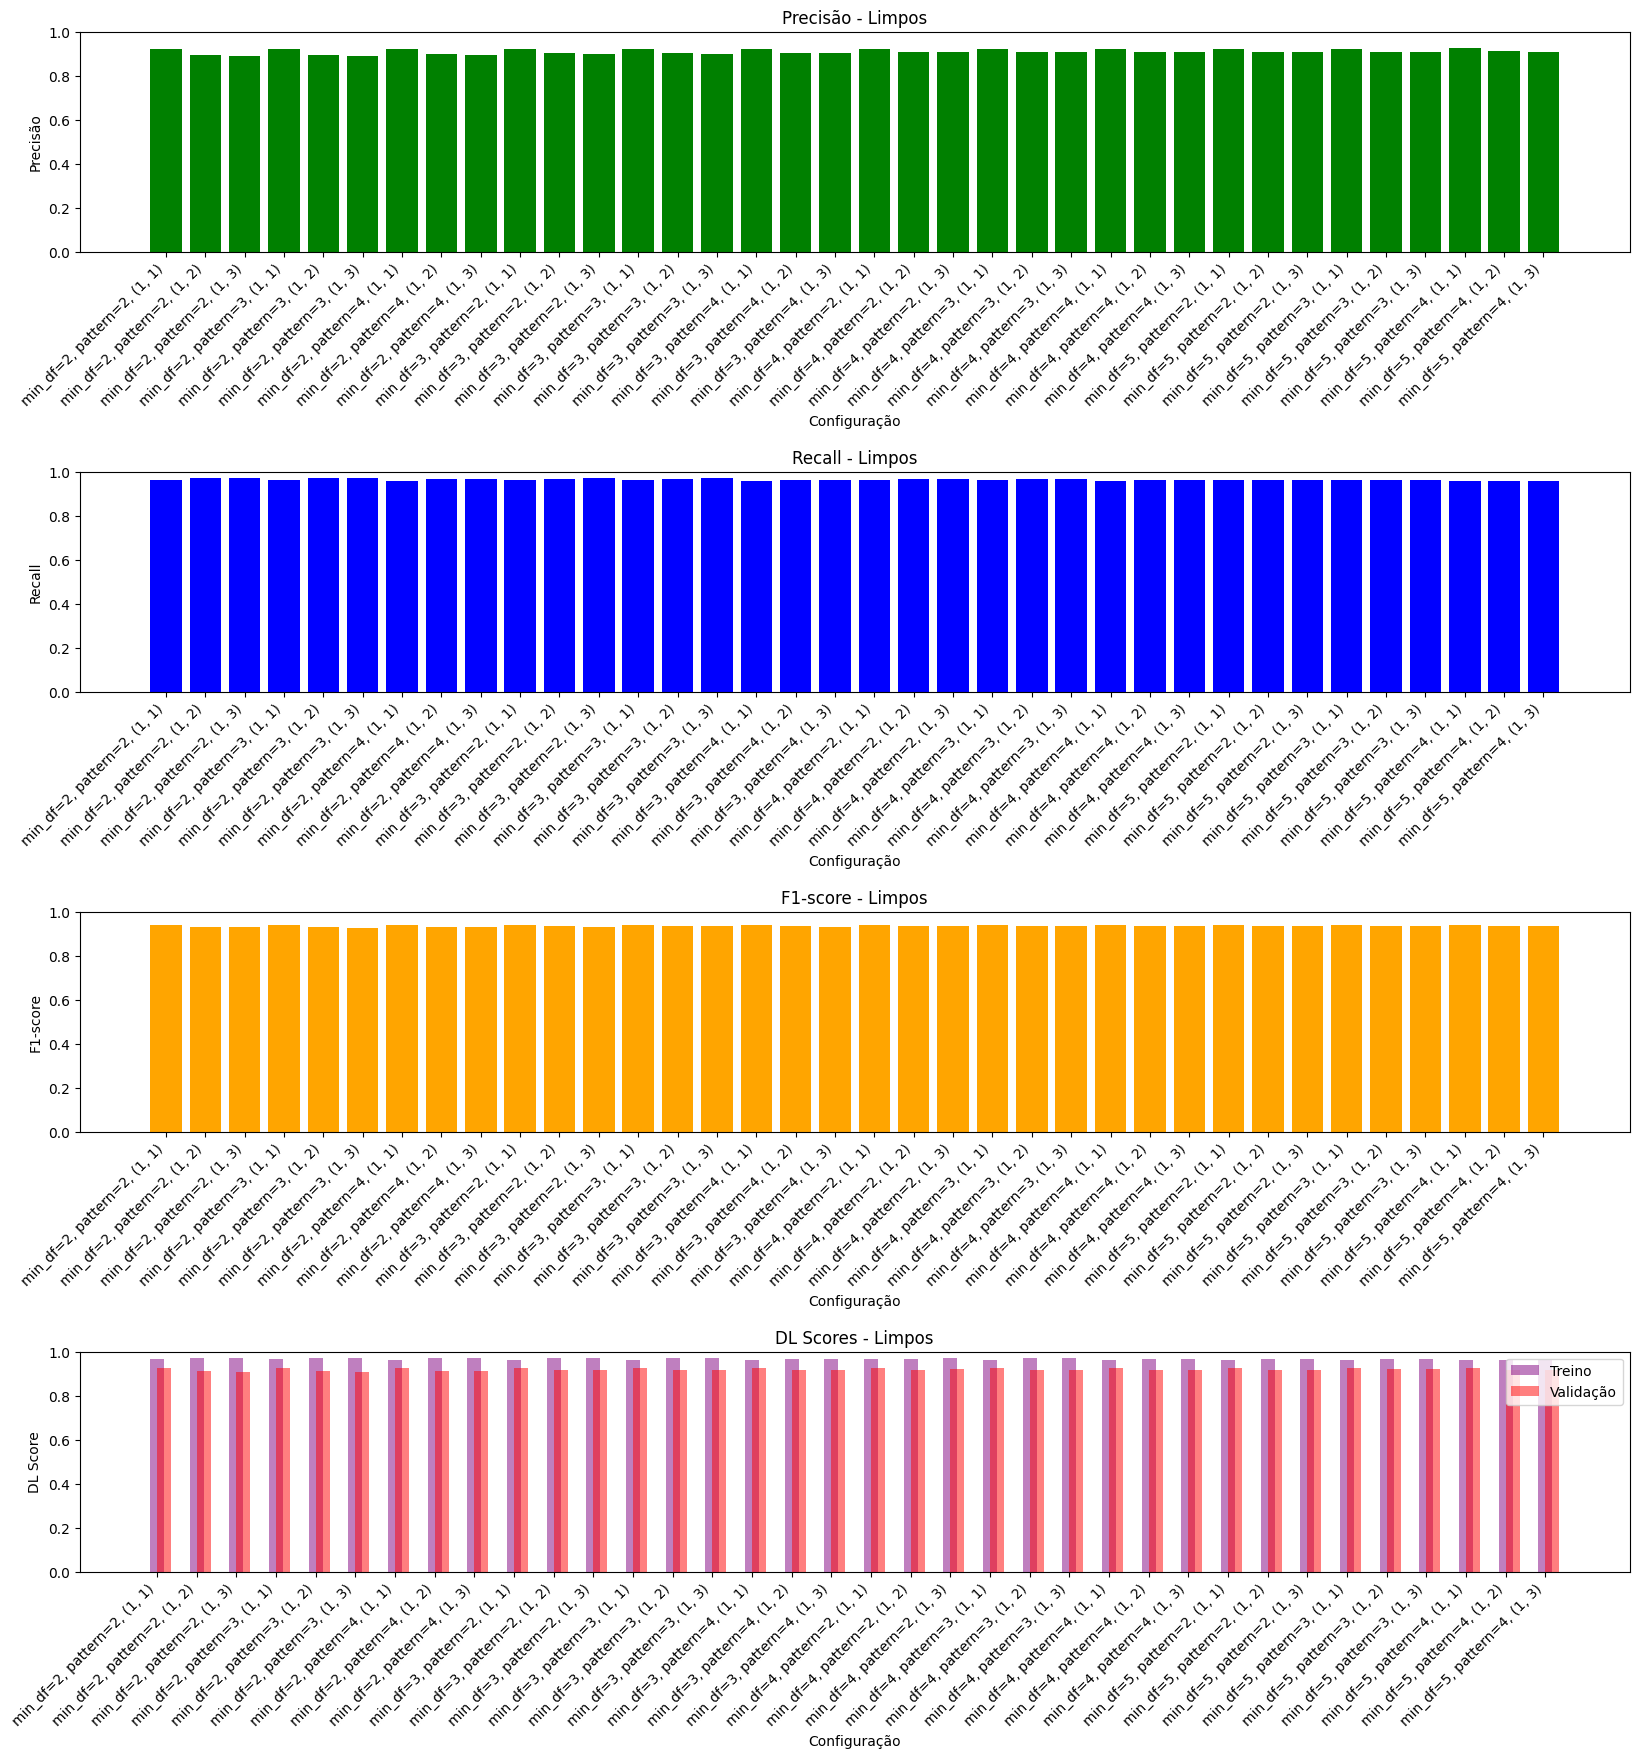

Tabela de Métricas - Porter
+-----------------------------+------------+----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |   Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+----------+------------+-------------------+----------------------|
| min_df=2, pattern=2, (1, 1) |   0.92637  | 0.95922  |   0.942509 |          0.964898 |             0.92926  |
| min_df=2, pattern=2, (1, 2) |   0.90256  | 0.968972 |   0.934587 |          0.974009 |             0.918006 |
| min_df=2, pattern=2, (1, 3) |   0.897792 | 0.973404 |   0.934071 |          0.975616 |             0.916935 |
| min_df=2, pattern=3, (1, 1) |   0.921569 | 0.958333 |   0.939591 |          0.965166 |             0.925509 |
| min_df=2, pattern=3, (1, 2) |   0.906302 | 0.968972 |   0.93659  |          0.974812 |             0.920686 |
| min_df=2, pattern=3, (1, 3) |   0.897709 | 0.972518 |   0.933617 |        

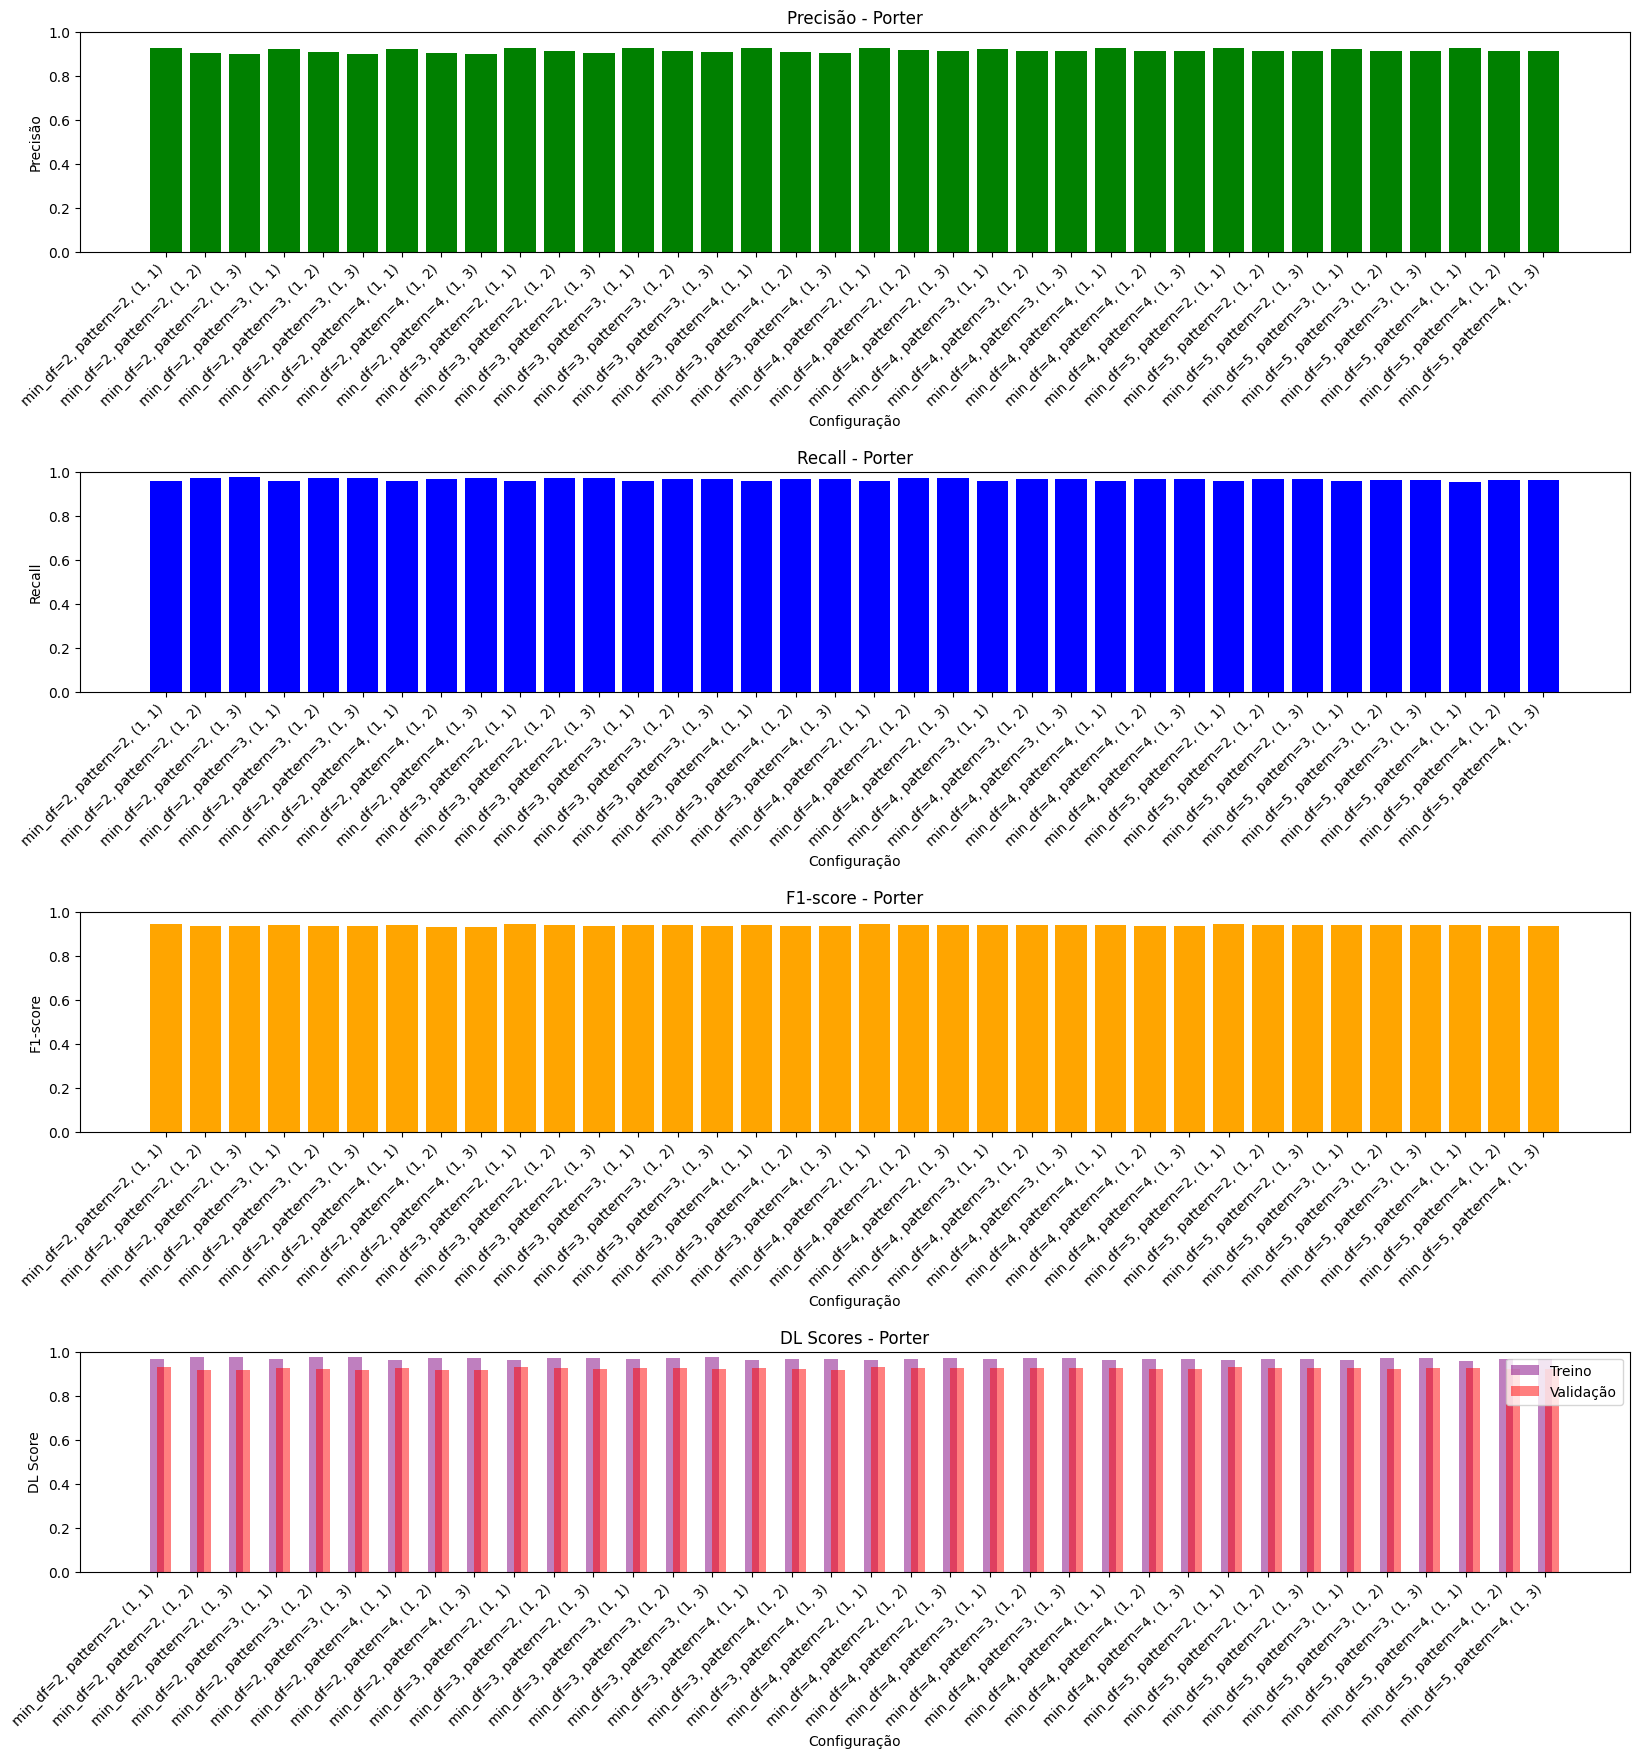

Tabela de Métricas - Snowball
+-----------------------------+------------+----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |   Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+----------+------------+-------------------+----------------------|
| min_df=2, pattern=2, (1, 1) |   0.925577 | 0.95922  |   0.942098 |          0.964898 |             0.928725 |
| min_df=2, pattern=2, (1, 2) |   0.908562 | 0.968972 |   0.937795 |          0.975348 |             0.922294 |
| min_df=2, pattern=2, (1, 3) |   0.902721 | 0.970745 |   0.935498 |          0.976956 |             0.919078 |
| min_df=2, pattern=3, (1, 1) |   0.924851 | 0.960106 |   0.942149 |          0.965166 |             0.928725 |
| min_df=2, pattern=3, (1, 2) |   0.907054 | 0.968972 |   0.936991 |          0.975616 |             0.921222 |
| min_df=2, pattern=3, (1, 3) |   0.901153 | 0.969858 |   0.934244 |      

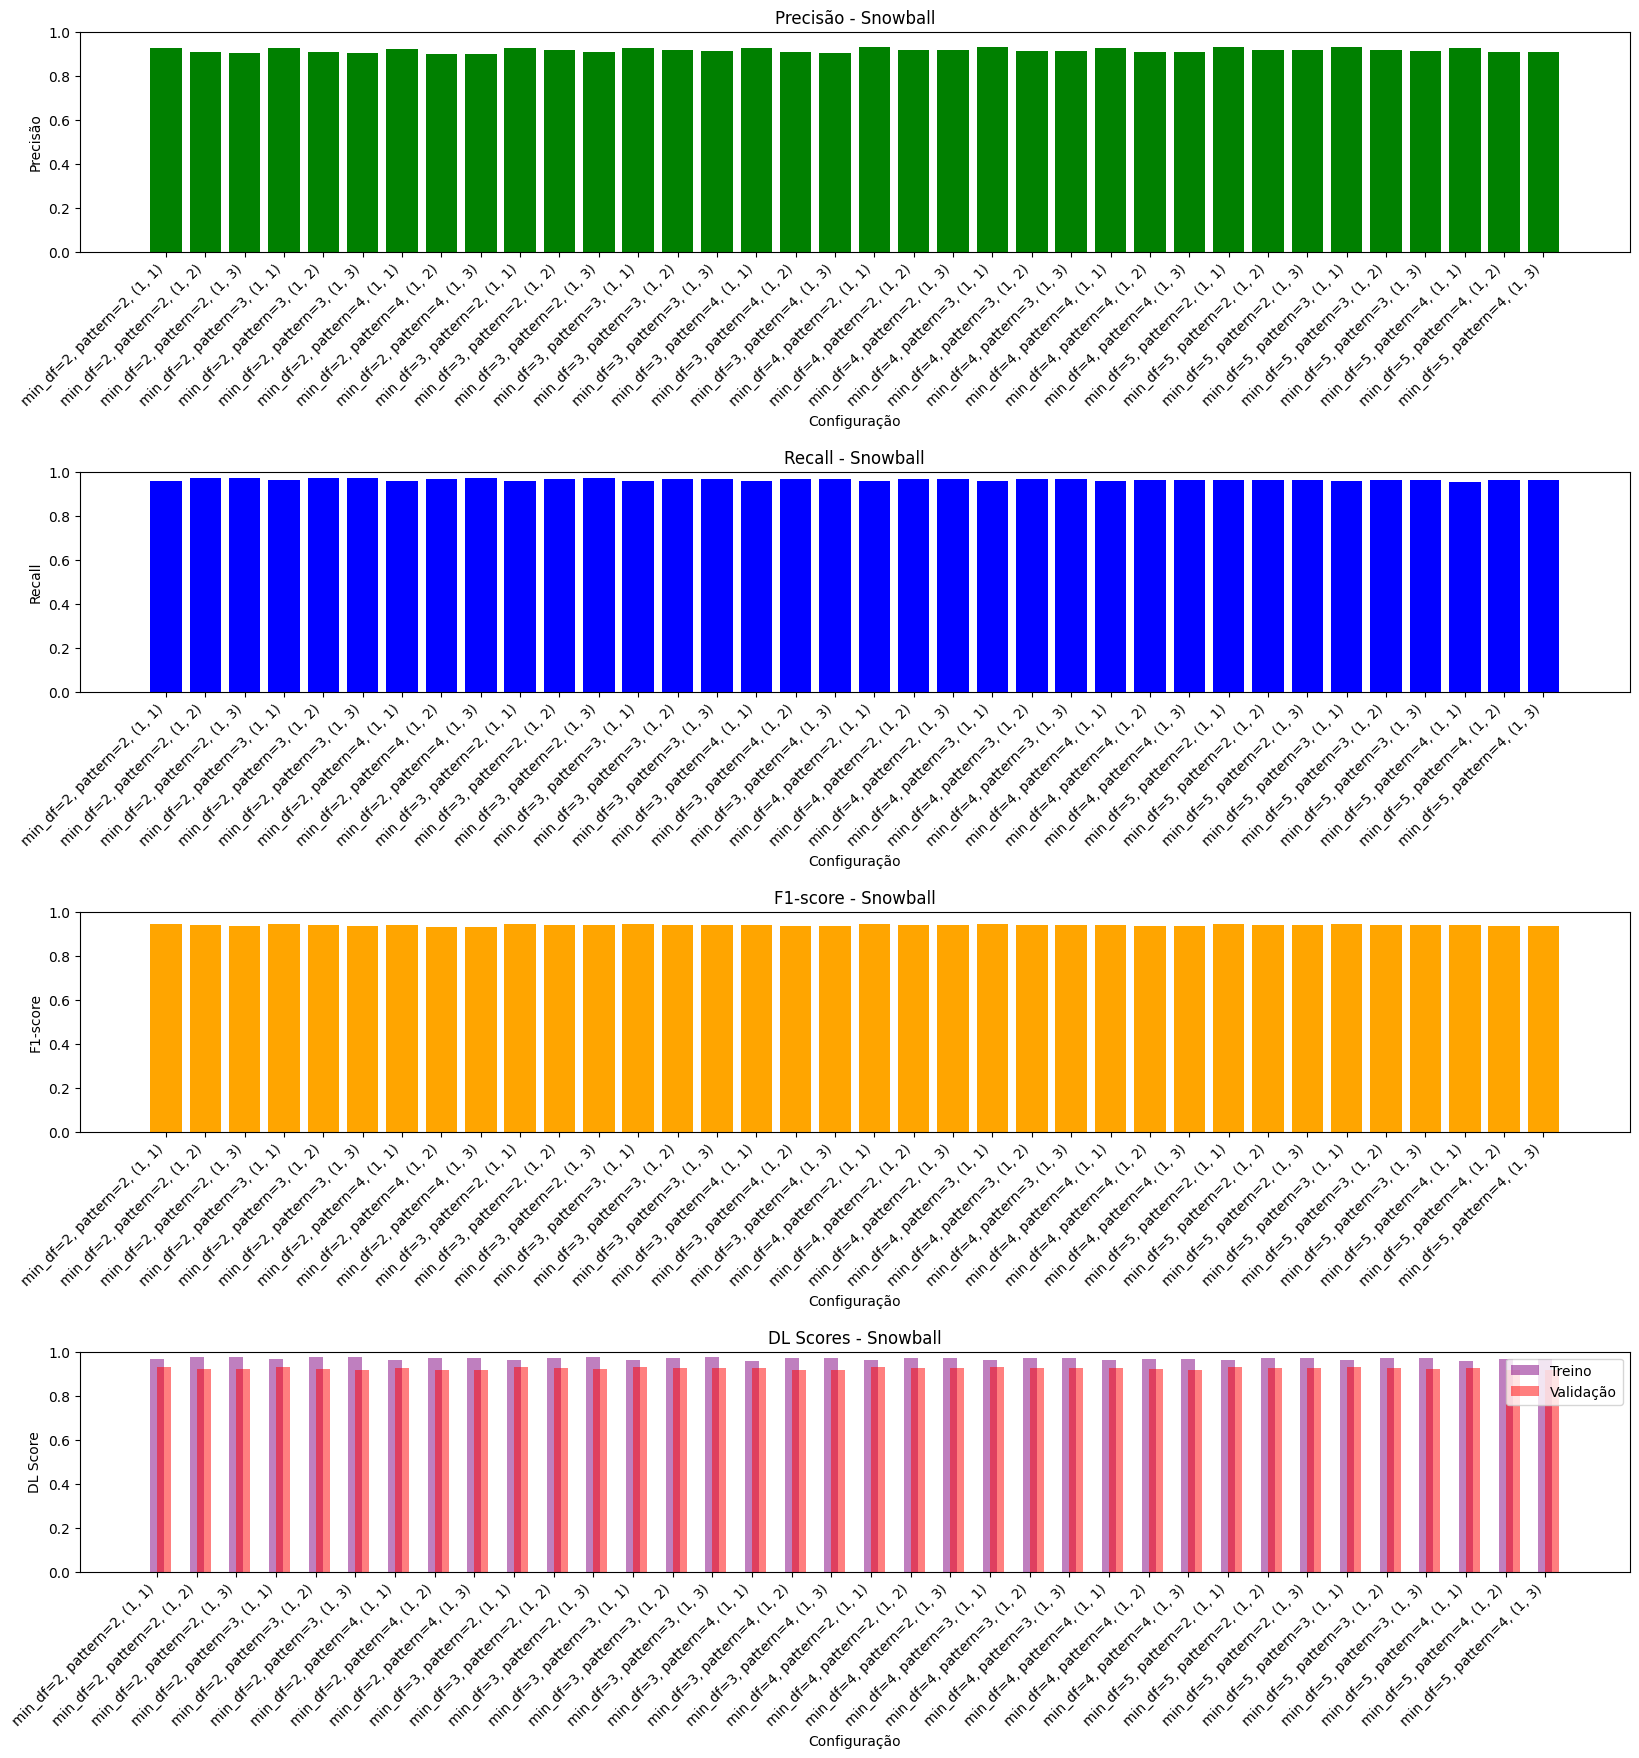

Tabela de Métricas - Lancaster
+-----------------------------+------------+----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |   Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+----------+------------+-------------------+----------------------|
| min_df=2, pattern=2, (1, 1) |   0.92906  | 0.963652 |   0.94604  |          0.965166 |             0.933548 |
| min_df=2, pattern=2, (1, 2) |   0.911056 | 0.971631 |   0.940369 |          0.975616 |             0.925509 |
| min_df=2, pattern=2, (1, 3) |   0.905272 | 0.974291 |   0.938514 |          0.976688 |             0.92283  |
| min_df=2, pattern=3, (1, 1) |   0.928266 | 0.963652 |   0.945629 |          0.96597  |             0.933012 |
| min_df=2, pattern=3, (1, 2) |   0.90429  | 0.971631 |   0.936752 |          0.973205 |             0.920686 |
| min_df=2, pattern=3, (1, 3) |   0.899098 | 0.971631 |   0.933958 |     

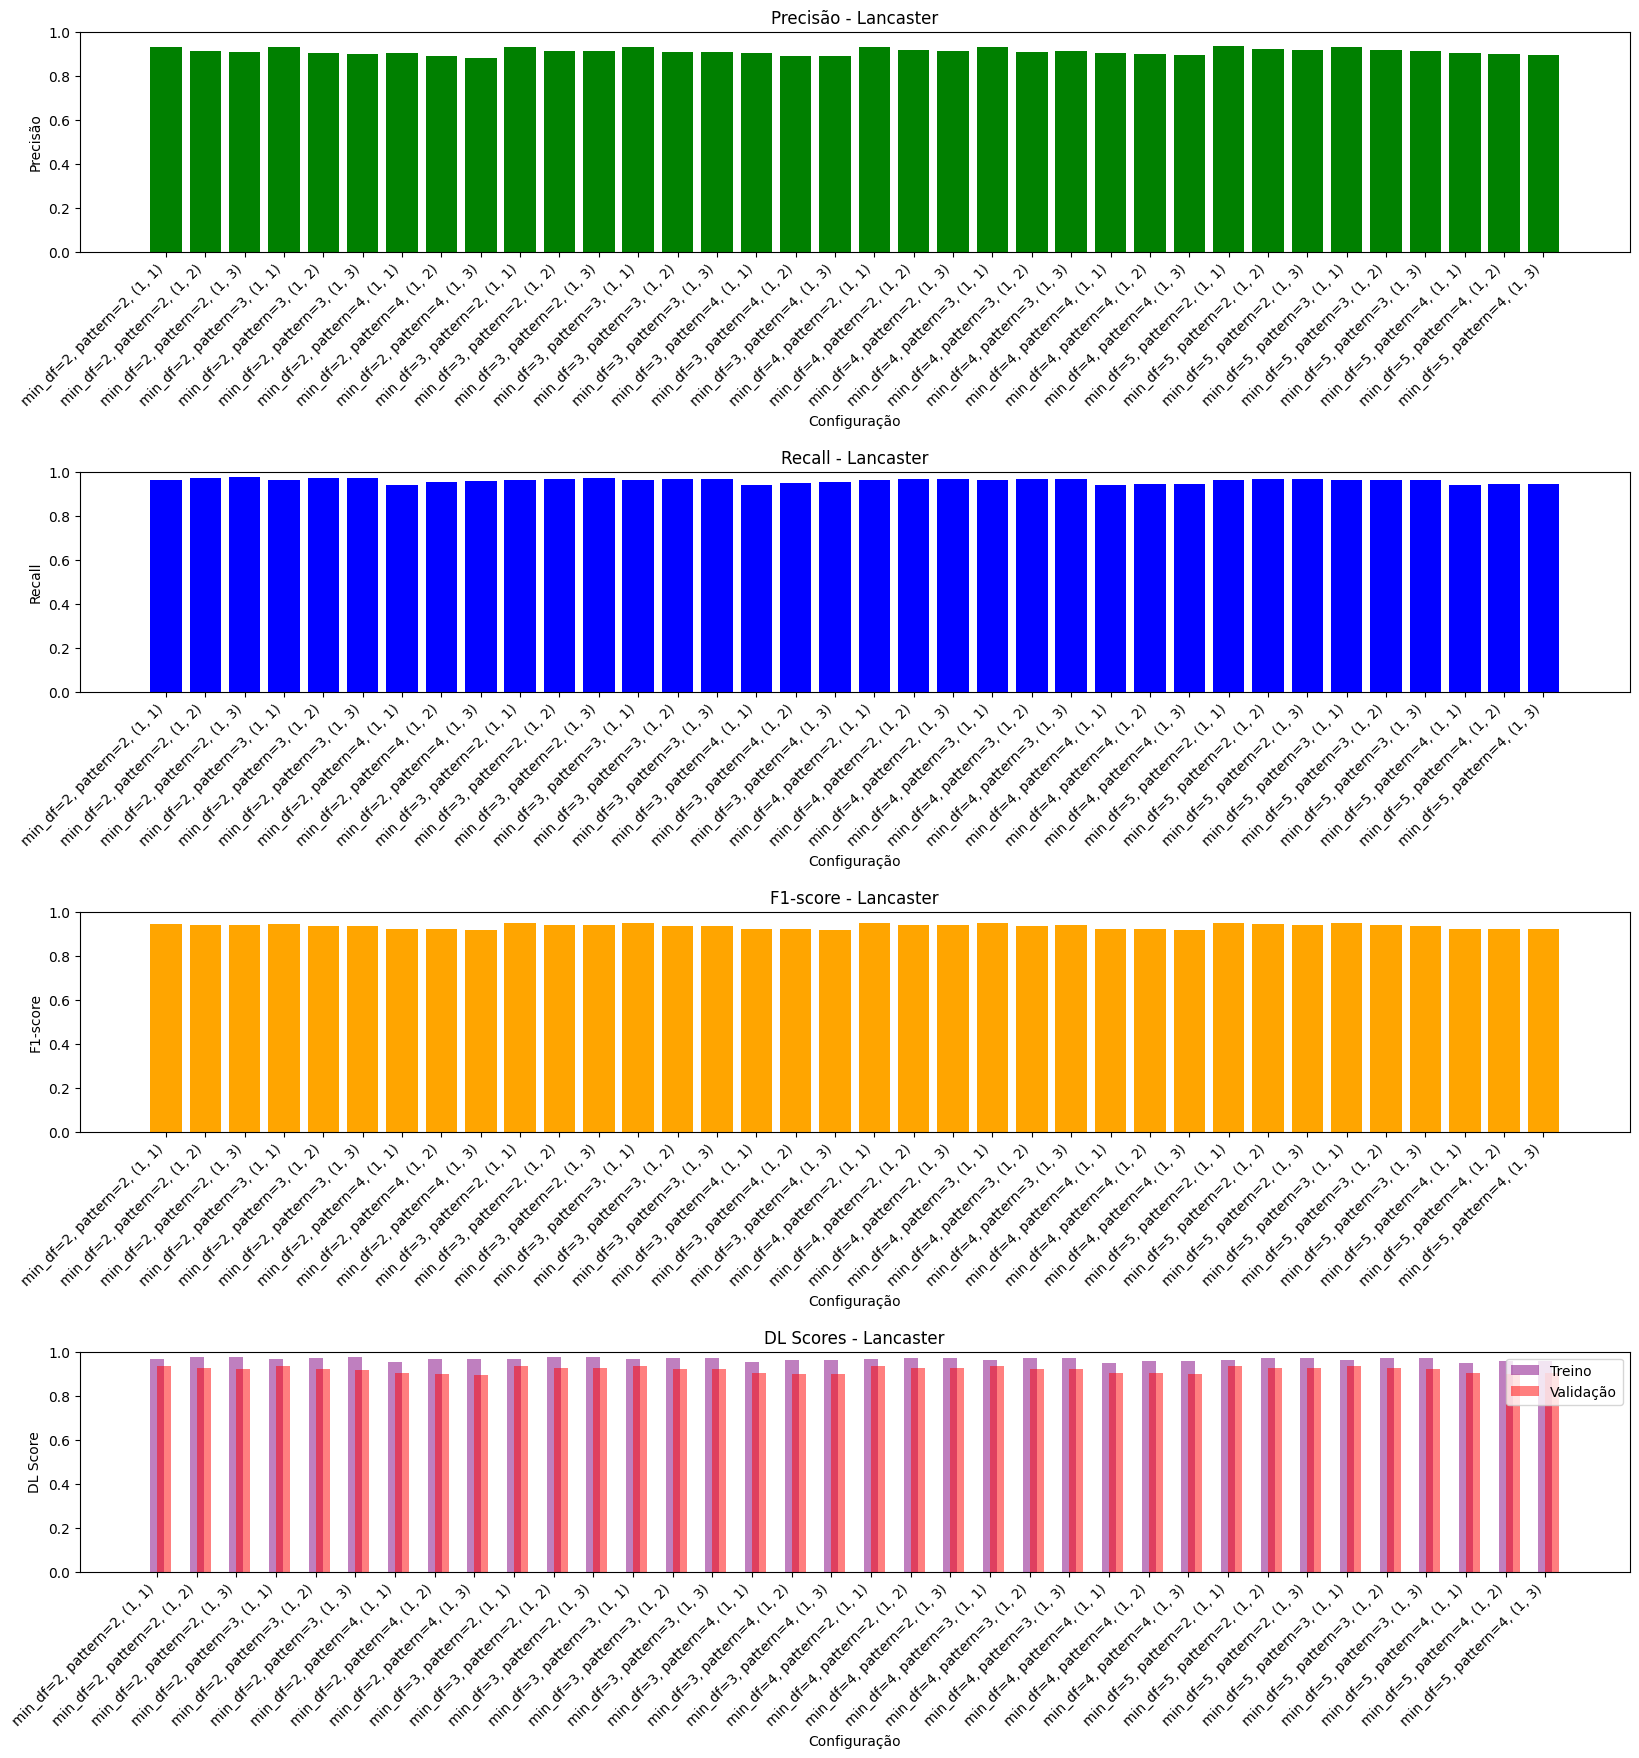

In [89]:
# Carregar os dicionários
dicionario_limpos = pickle.load(open("ficheirosPickel/dicionario_limpos_dl_v2.p", "rb"))
dicionario_porter = pickle.load(open("ficheirosPickel/dicionario_porter_dl_v2.p", "rb"))
dicionario_snowball = pickle.load(open("ficheirosPickel/dicionario_snowball_dl_v2.p", "rb"))
dicionario_lancaster = pickle.load(open("ficheirosPickel/dicionario_lancaster_dl_v2.p", "rb"))

#Criar tabela e gráfico para cada stemmer
criar_tabela_metricas(dicionario_limpos, "Limpos")
criar_tabela_metricas(dicionario_porter, "Porter")
criar_tabela_metricas(dicionario_snowball, "Snowball")
criar_tabela_metricas(dicionario_lancaster, "Lancaster")

Tabela de Métricas - Limpos
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.695238 | 0.102241  |  0.178266  |           0.96037 |             0.959621 |
| min_df=2, pattern=1, (1, 2) |   0.837838 | 0.0434174 |  0.0825566 |           0.95662 |             0.958661 |
| min_df=2, pattern=1, (1, 3) |   0.8      | 0.0336134 |  0.0645161 |           0.95584 |             0.958241 |
| min_df=2, pattern=2, (1, 1) |   0.706422 | 0.107843  |  0.18712   |           0.96037 |             0.959861 |
| min_df=2, pattern=2, (1, 2) |   0.842105 | 0.0448179 |  0.0851064 |           0.95659 |             0.958721 |
| min_df=2, pattern=2, (1, 3) |   0.8125   | 0.0364146 |  0.0697051 

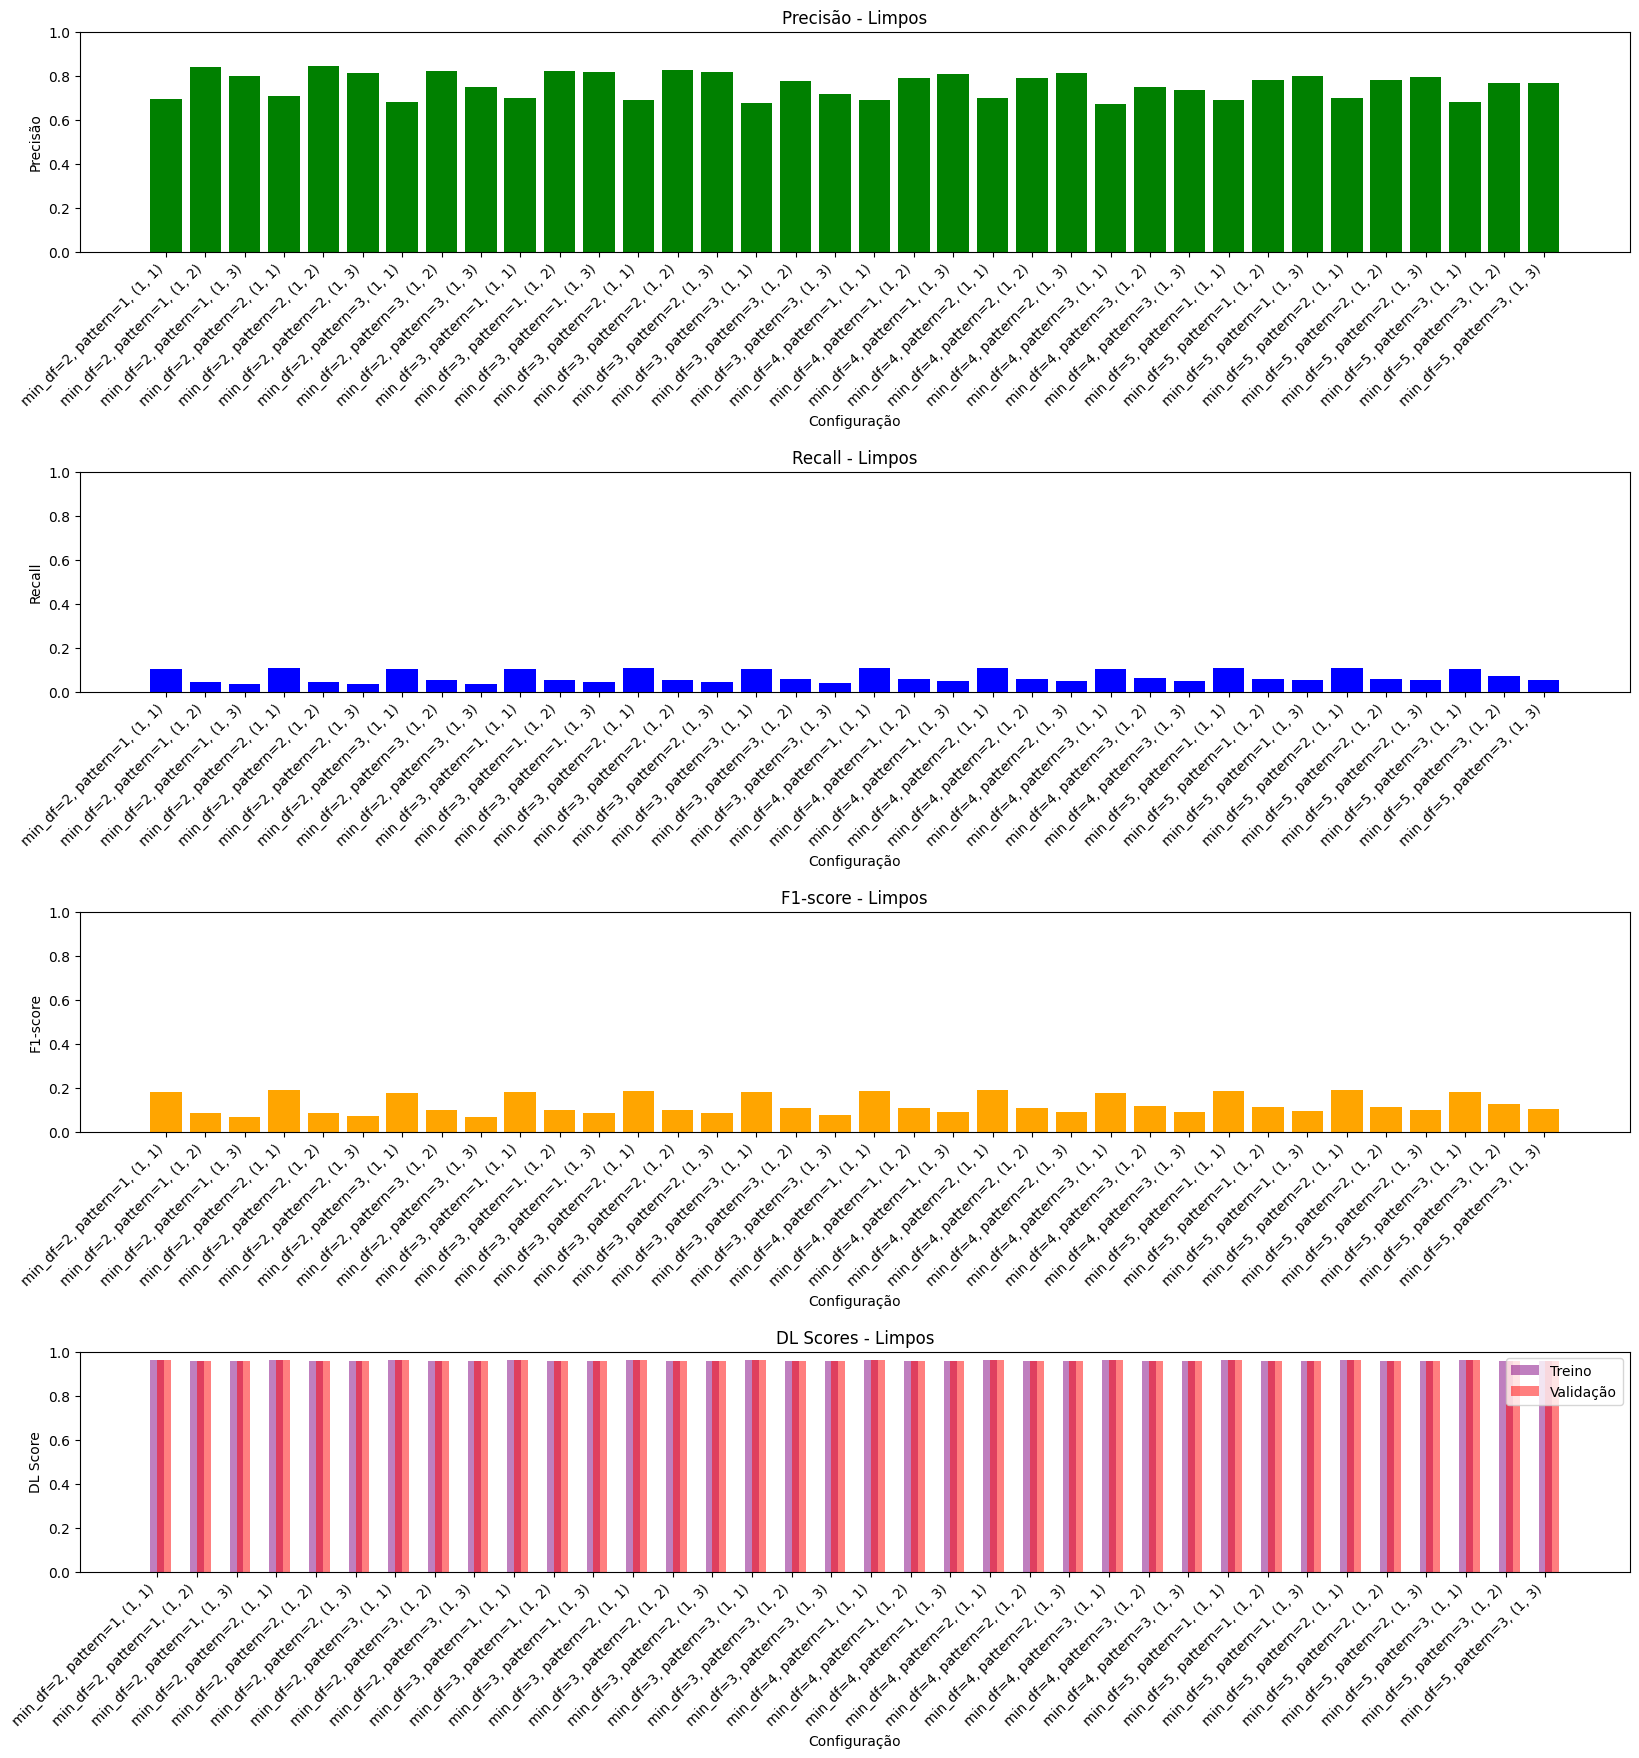

Tabela de Métricas - Porter
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.709677 | 0.123249  |  0.210024  |           0.96097 |             0.960281 |
| min_df=2, pattern=1, (1, 2) |   0.837209 | 0.0504202 |  0.0951123 |           0.95746 |             0.958901 |
| min_df=2, pattern=1, (1, 3) |   0.8      | 0.0336134 |  0.0645161 |           0.95587 |             0.958241 |
| min_df=2, pattern=2, (1, 1) |   0.717742 | 0.12465   |  0.212411  |           0.961   |             0.960401 |
| min_df=2, pattern=2, (1, 2) |   0.8125   | 0.0546218 |  0.102362  |           0.95755 |             0.958961 |
| min_df=2, pattern=2, (1, 3) |   0.764706 | 0.0364146 |  0.0695187 

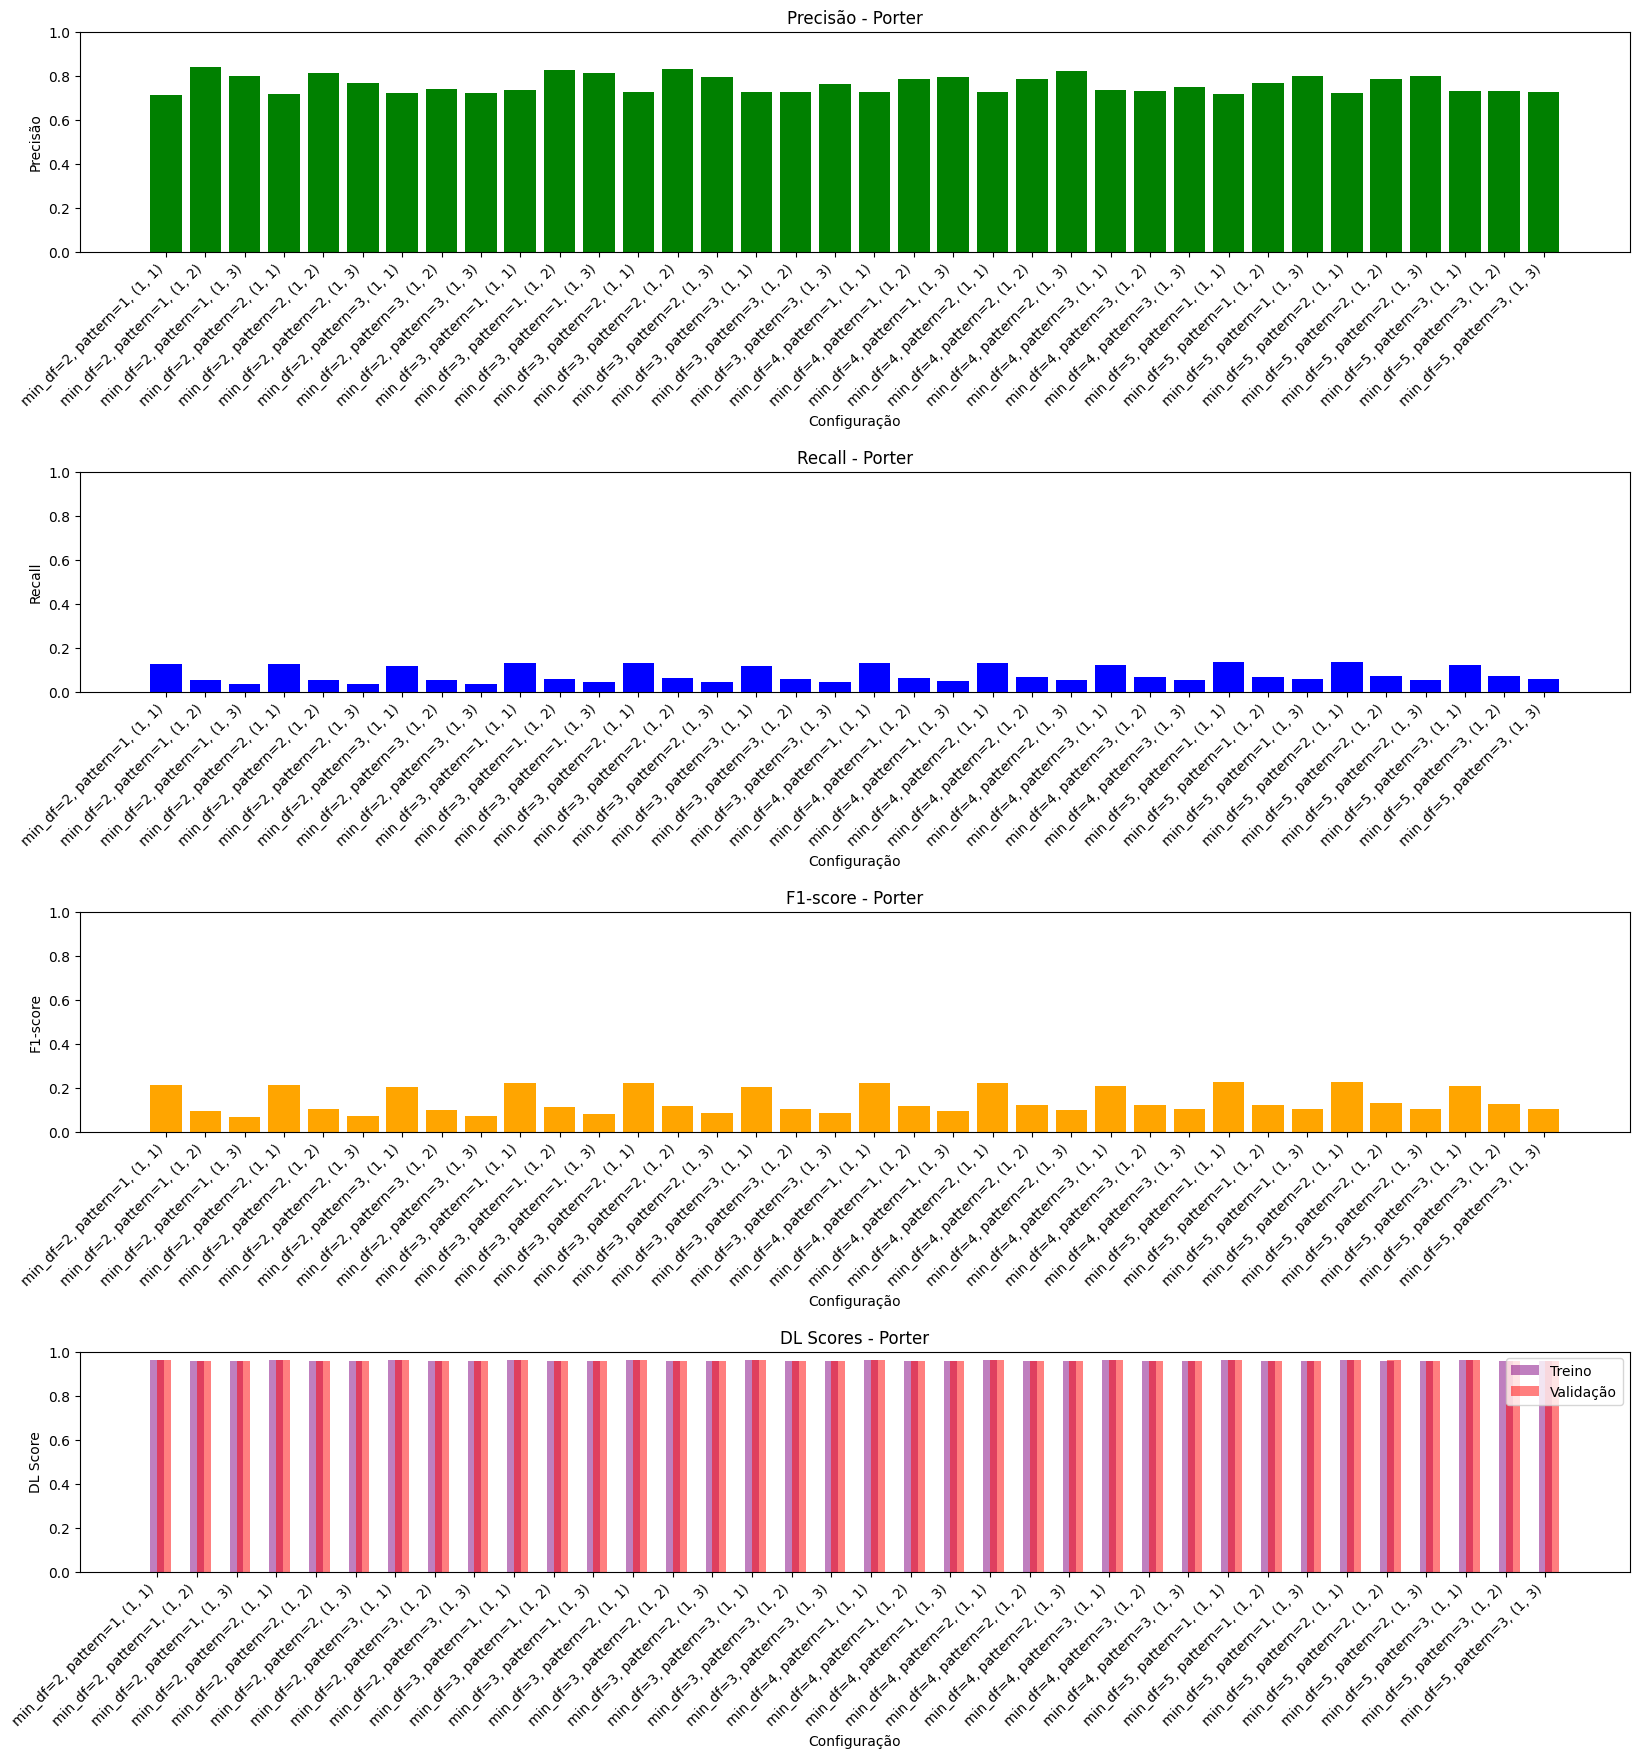

Tabela de Métricas - Snowball
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.72     | 0.12605   |  0.214541  |           0.96103 |             0.960461 |
| min_df=2, pattern=1, (1, 2) |   0.8      | 0.0504202 |  0.0948617 |           0.95746 |             0.958781 |
| min_df=2, pattern=1, (1, 3) |   0.777778 | 0.0392157 |  0.0746667 |           0.95635 |             0.958361 |
| min_df=2, pattern=2, (1, 1) |   0.722222 | 0.127451  |  0.216667  |           0.96091 |             0.960521 |
| min_df=2, pattern=2, (1, 2) |   0.826087 | 0.0532213 |  0.1       |           0.9574  |             0.958961 |
| min_df=2, pattern=2, (1, 3) |   0.771429 | 0.0378151 |  0.072096

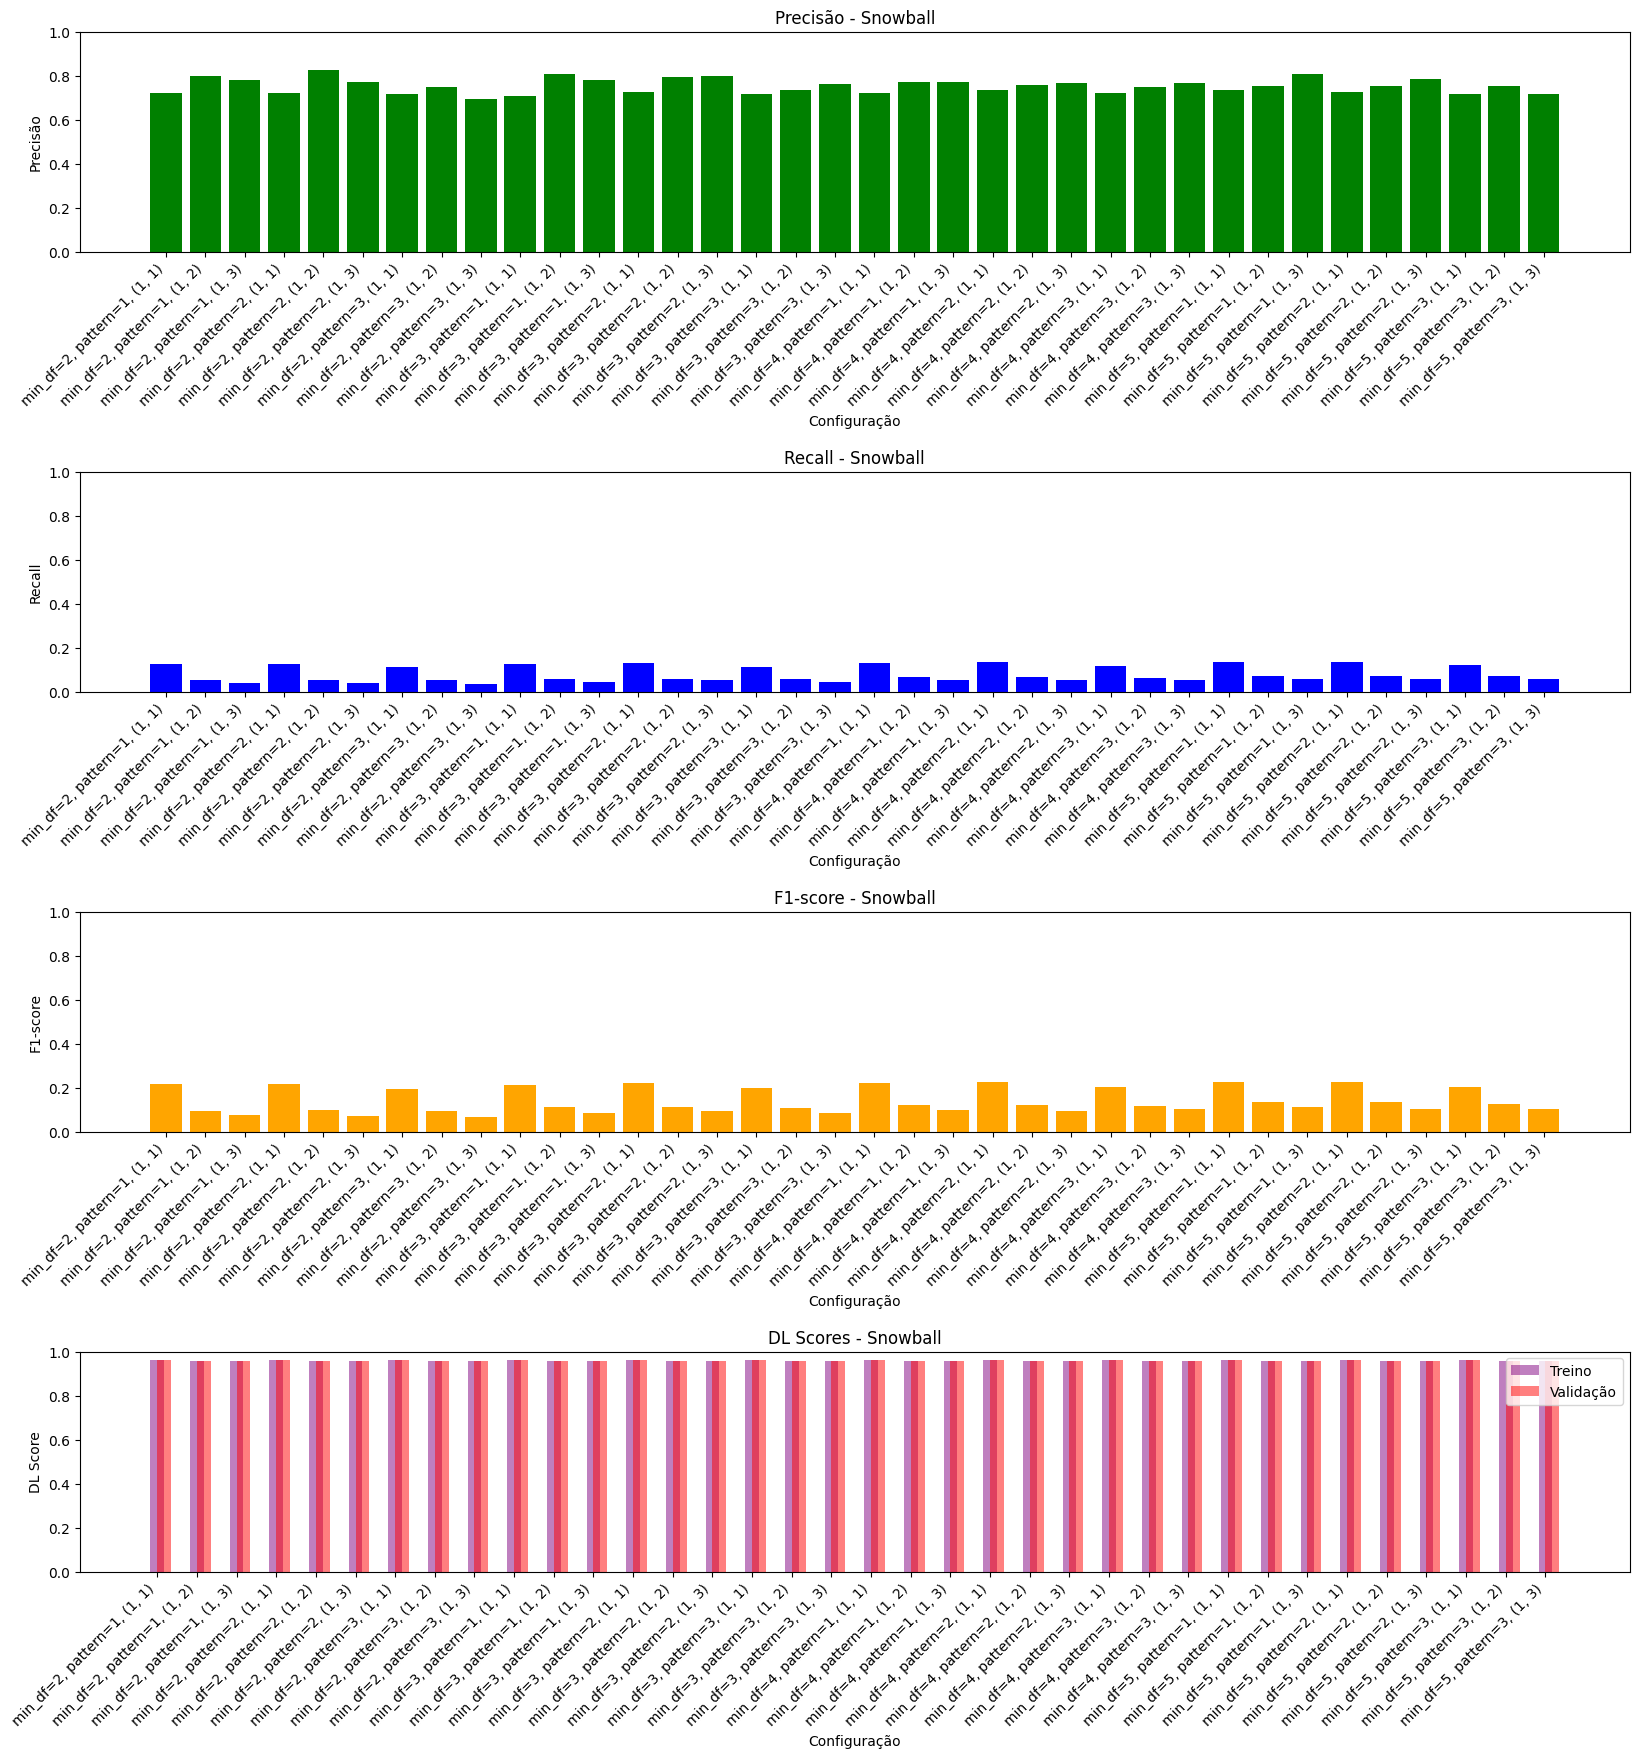

Tabela de Métricas - Lancaster
+-----------------------------+------------+-----------+------------+-------------------+----------------------+
| Configuração                |   Precisão |    Recall |   F1-score |   DL Score Treino |   DL Score Validação |
|-----------------------------+------------+-----------+------------+-------------------+----------------------|
| min_df=2, pattern=1, (1, 1) |   0.697674 | 0.12605   |  0.213523  |           0.96124 |             0.960221 |
| min_df=2, pattern=1, (1, 2) |   0.805556 | 0.0406162 |  0.0773333 |           0.95701 |             0.958481 |
| min_df=2, pattern=1, (1, 3) |   0.851852 | 0.0322129 |  0.0620783 |           0.95578 |             0.958301 |
| min_df=2, pattern=2, (1, 1) |   0.691176 | 0.131653  |  0.221176  |           0.96121 |             0.960281 |
| min_df=2, pattern=2, (1, 2) |   0.820513 | 0.0448179 |  0.0849934 |           0.95704 |             0.958661 |
| min_df=2, pattern=2, (1, 3) |   0.814815 | 0.0308123 |  0.05937

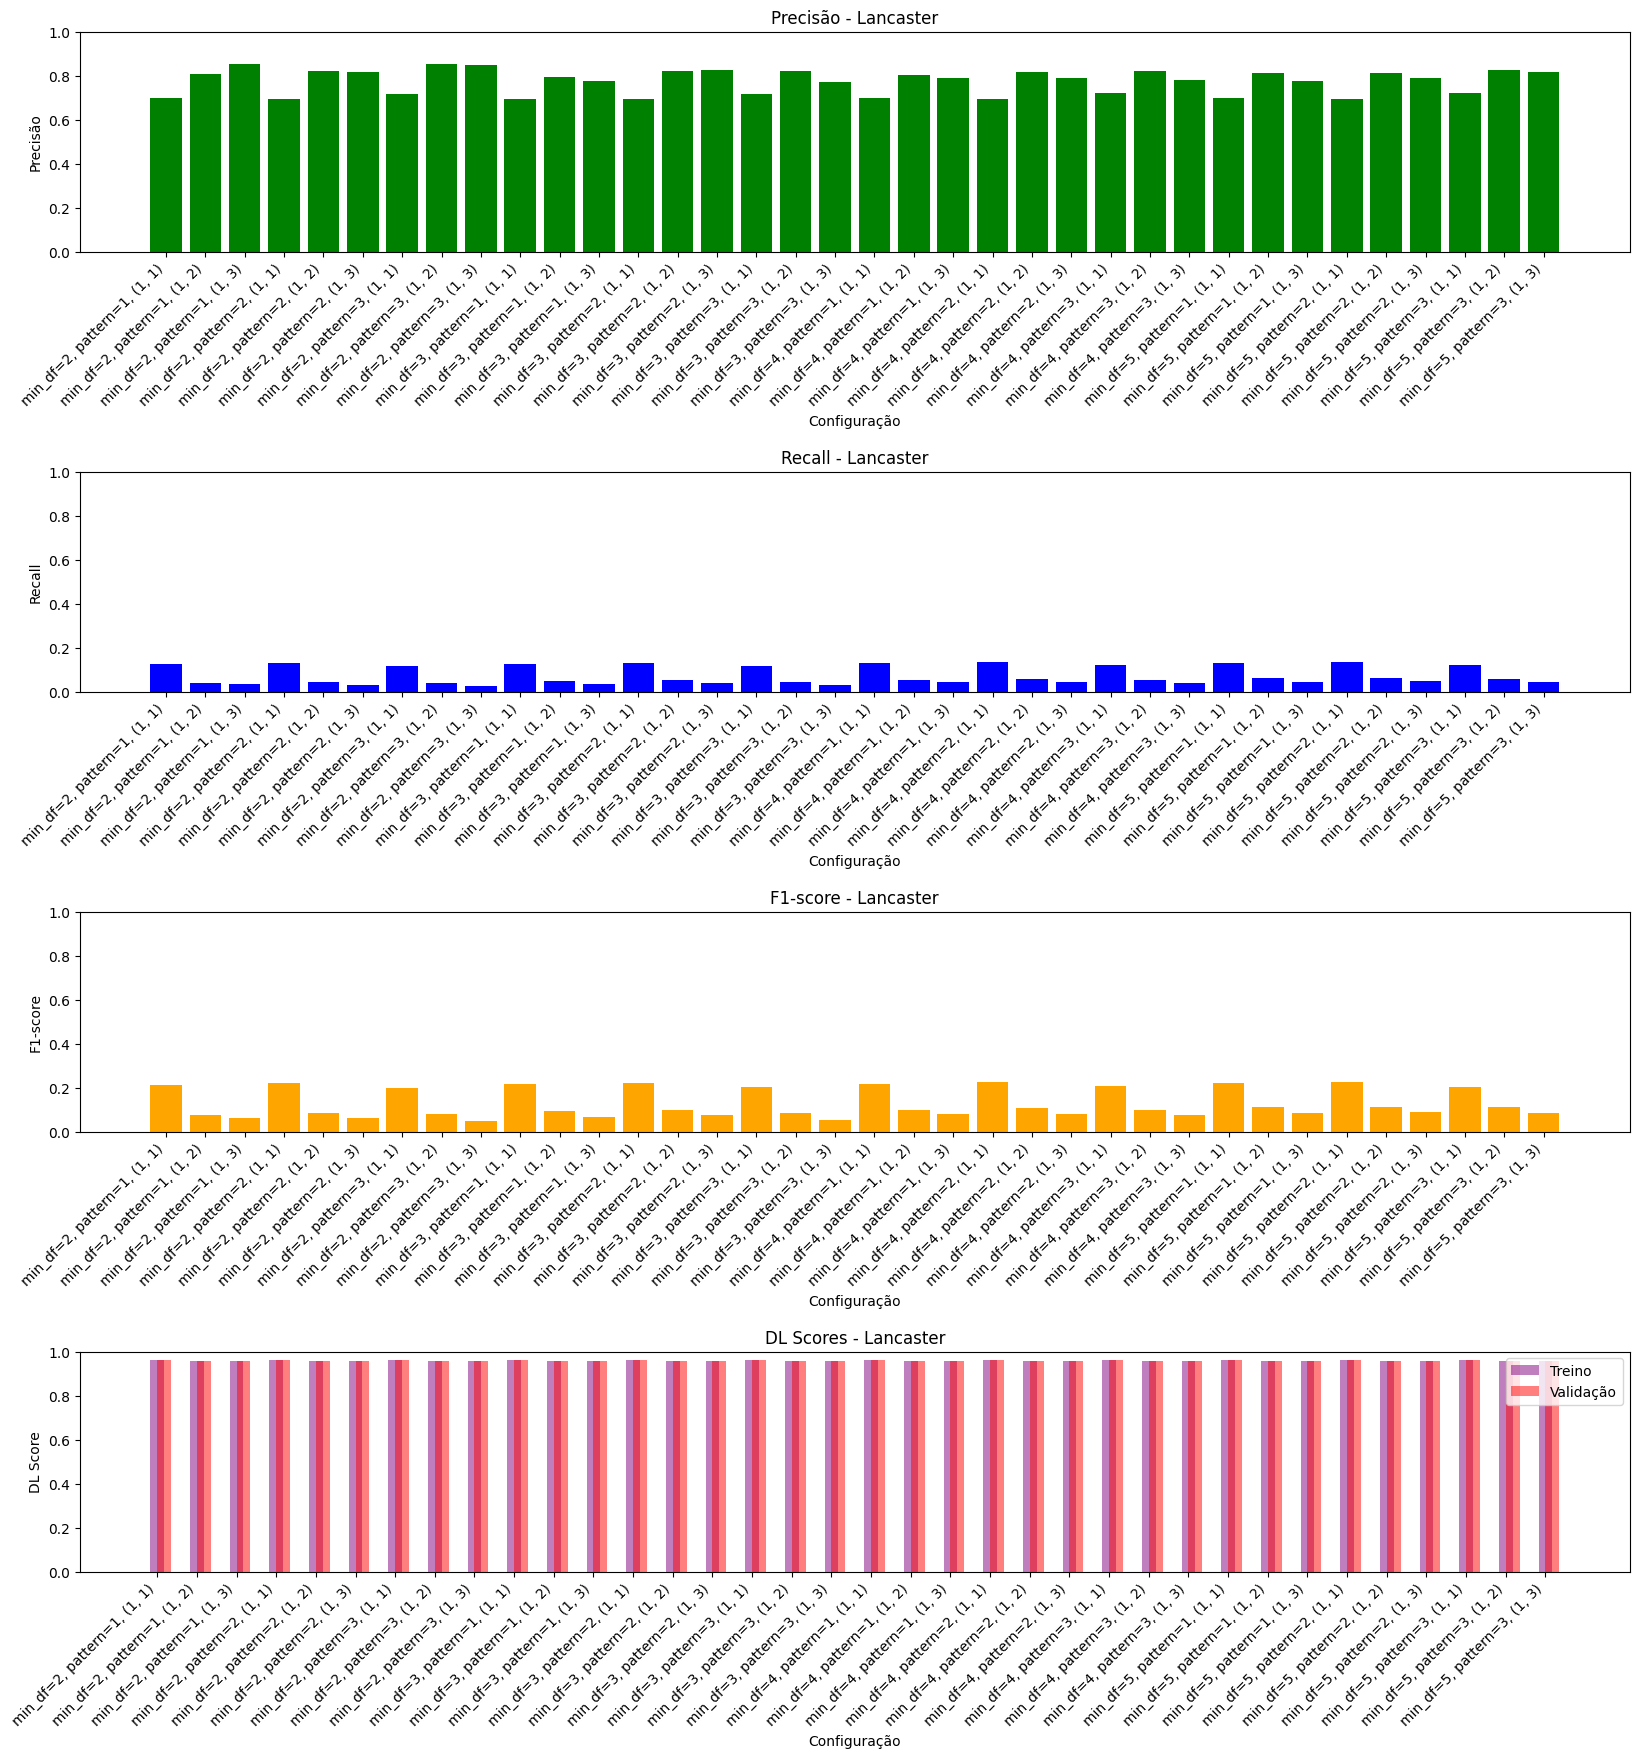

In [90]:
dicionario_limpos_n = pickle.load(open("ficheirosPickel/dicionario_limpos_neg_dl.p", "rb"))
dicionario_porter_n = pickle.load(open("ficheirosPickel/dicionario_porter_neg_dl.p", "rb"))
dicionario_snowball_n = pickle.load(open("ficheirosPickel/dicionario_snowball_neg_dl.p", "rb"))
dicionario_lancaster_n = pickle.load(open("ficheirosPickel/dicionario_lancaster_neg_dl.p", "rb"))

# Criar tabela e gráfico para cada stemmer
criar_tabela_metricas(dicionario_limpos_n, "Limpos")
criar_tabela_metricas(dicionario_porter_n, "Porter")
criar_tabela_metricas(dicionario_snowball_n, "Snowball")
criar_tabela_metricas(dicionario_lancaster_n, "Lancaster")

Através da mesma análise, chegou-se a estas 4 configurações:


|-----------|-----------------------------|--------------|--------------|----------|-------------------|----------|------------|
| Limpos    | min_df=5, pattern=3, (1, 1) | 0.921769     | 0.960993     | 0.940972 |          0.963558 |             0.927117 | 0.692388
| Porter    | min_df=2, pattern=2, (1, 1) | 0.92637      | 0.95922      | 0.942509 |          0.964898 |             0.92926  | 0.871972
| Snowball  | min_df=5, pattern=2, (1, 1) | 0.929614     | 0.960106     | 0.944614 |          0.962487 |             0.93194  | 0.869293
| Lancaster | min_df=4, pattern=2, (1, 1) | 0.932247     | 0.963652     | 0.94769  |          0.964362 |             0.935691 | 0.028671

Utilizando um stemmer de Lancaster consegue-se um score de validação melhor, assim como nos restantes parametros. Adicionalmente a diferença entre os score de treino e de validação são os menores, sendo o que tem a menor probabilidade de estar em sobreaprendizagem.

Assim sendo, vai se utilizar os seguintes parametros:

Steammer: Lancaster
Configuração do TfidfVectorizer: min_df=4, pattern=2, n-gramas (1, 1) Stop_Words='English'

Procurar os melhores parametros para o classificador, usando as funções criadas anteriormente.

In [ ]:


def vetorizar_criar_voc_com_parametros():
    #documentos porter
    docs = pickle.load(open("ficheirosPickel/documentos_lancaster.p", "rb"))
    docs = np.array(docs)
    
    overall = np.array([int(beerDictTrain[idx]['overall'].split('/')[0]) for idx in beerDictTrain])
    docs_muitoboms_muitomaus = []
    y = []
    for idx in range(len(docs)):
        if overall[idx] >= 9:
            docs_muitoboms_muitomaus.append(docs[idx])
            y.append(1)
        elif overall[idx] <= 2:
            docs_muitoboms_muitomaus.append(docs[idx])
            y.append(-1)
    
    
    docs_muitoboms_muitomaus = np.array(docs_muitoboms_muitomaus)
    y = np.array(y)
    print(docs_muitoboms_muitomaus.shape)
    print(y.shape)
    # Criar divisões de treinamento e teste
    X_train, X_test, y_train, y_test = train_test_split(docs_muitoboms_muitomaus, y, test_size=1/3, stratify=y)


    # Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)

    vocabulario = vectorizer.get_feature_names_out()
    
    vect = {'vocabulario': vocabulario, 'X_train_t': X_train_t, 'X_test_t': X_test_t, 'y_train': y_train, 'y_test': y_test}
    pickle.dump(vect, open("ficheirosPickel/vocabulario_X_train_t_X_test_t_v2.p", "wb"))


In [ ]:
#vetorizar_criar_voc_com_parametros()

In [ ]:
vect = pickle.load(open("ficheirosPickel/vocabulario_X_train_t_X_test_t_v2.p", "rb"))
vocabulario = vect['vocabulario']                            
X_train_t = vect['X_train_t']
X_test_t = vect['X_test_t']
y_train = vect['y_train']
y_test = vect['y_test']
#teste_hiper_linearRegression(X_train_t, X_test_t, y_train, y_test)

Apos testar os hiperparametros com varias métricas, temos que os melhores parametros focando em cada métrica são:

 Metrica                | Valor  | C  | Penalty
------------------------|--------|----| -------
 Score Cross-Validation | 0.9373 | 10 | l2
 Erros                  | 174    | 1  | l2
 Score do Modelo        | 0.9379 | 1  | l2
 Distância Prec/Rec     | 0.0693 | 1  | l2 | Prec: 0.9507 | Rec: 0.9513
 Distância ROC          | 0.3068 | 1 | l2 | FPR:  0.0618 | TPR: 0.9412 
 
Verificamos que a maioria das mertricas tem melhores resultados com o C = 1 e o penalty = l2 ou seja a regularização de Ridge.
Pode-se fazer mais um teste para coparar melhor os resultados quando C = 1 e penalty = l2, e quando C = 10 e penalty = l2. 

Comparando os resultados para duas configurações diferentes:

Configuração | C  | Penalty | Score Cross-Validation | Erros | Score do Modelo | Distância Precisão/Recall | Precisão | Recall | Distância ROC | FPR    | TPR 
-------------|----|---------|------------------------|-------|-----------------|---------------------------|----------|--------|---------------|--------|---- 
A            | 1  | l2      | 0.9339                 | 174   | 0.9379          | 0.0693                    | 0.95074  | 0.9513 | 0.0853        | 0.0618 | 0.9412
B            | 10 | l2      | 0.9373                 | 175   | 0.9375          | 0.0723                      | 0.95     | 0.9477 | 0.089         | 0.0663 | 0.9406

Os resultados não diferem muito, contudo vai se utilizar os parametros de C= 1 e penalty =l2.

In [ ]:
def limpar_teste_b1():
    Docs_teste = [beerDictTest[idx]['review'] for idx in beerDictTest]
    Docs_teste_limpos = limpar_caracteres_tags(Docs_teste)
    porter = LancasterStemmer()
    X_test_limpos_lancaster = stemming(Docs_teste_limpos, porter)
    pickle.dump(X_test_limpos_lancaster, open("ficheirosPickel/documentos_teste_lancaster_v2.p", "wb"))


In [ ]:
#limpar_teste_b1()

In [ ]:
def classificacao_Binaria_1_Discriminante_Logistico():
    
    #Passo 1: Carregar os dados de teste, estes já esão limpos com o porter
    X_train_limpos_lancaster = pickle.load(open("ficheirosPickel/documentos_lancaster.p", "rb"))
    X_train_l = np.array(X_train_limpos_lancaster)
    overall = np.array([int(beerDictTrain[idx]['overall'].split('/')[0]) for idx in beerDictTrain])

    X_train = []
    y_train = []
    for idx in range(len(X_train_l)):
        if overall[idx] >= 9:
            X_train.append(X_train_l[idx])
            y_train.append(1)
        elif overall[idx] <= 2:
            X_train.append(X_train_l[idx])
            y_train.append(-1)
    
    
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    print(X_train.shape)
    print(y_train.shape)
    
    
    #Passo 2: Carregar os dados de teste
    X_test_limpos_lancaster = pickle.load(open("ficheirosPickel/documentos_teste_lancaster_v2.p", "rb"))
    X_test_l = np.array(X_test_limpos_lancaster)
    overall = np.array([int(beerDictTest[idx]['overall'].split('/')[0]) for idx in beerDictTest])

    X_test = []
    y_test = []
    criticas_teste = []
    
    dictKeys = list(beerDictTest.keys())
    
    
    for idx in range(len(X_test_l)):
        if overall[idx] >= 9:
            X_test.append(X_test_l[idx])
            y_test.append(1)
            criticas_teste.append((beerDictTest[dictKeys[idx]]['review'], beerDictTest[dictKeys[idx]]['overall']))
        elif overall[idx] <= 2:
            X_test.append(X_test_l[idx])
            y_test.append(-1)
            criticas_teste.append((beerDictTest[dictKeys[idx]]['review'], beerDictTest[dictKeys[idx]]['overall']))
    
    
    X_test = np.array(X_test)
    y_test = np.array(y_test)
    print(X_test.shape)
    print(y_test.shape)
    #Passo 3: Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)
    
    #armazenar o vocabulario e o vetorizador e os dados de treino e teste
    vect = {'vocabulario': vectorizer.get_feature_names_out(), 'X_train_t': X_train_t, 'X_test_t': X_test_t, 'y_train': y_train, 'y_test': y_test, 'criticas_teste': criticas_teste}
    pickle.dump(vect, open("ficheirosPickel/vetorizacaoConcluida_v2.p", "wb"))

    #ver o tamanho do vocabulario
    vocabulario = vectorizer.get_feature_names_out()
    print("Tamanho do vocabulario:", len(vocabulario))
    
    #Passo 4: Treinar o modelo
    lr = LogisticRegression(C=1, max_iter=5000, penalty='l2', solver='liblinear', tol=1e-2).fit(X_train_t, y_train)
    
    #Passo 5: Testar o modelo
    y_pred = lr.predict(X_test_t)
    
    #Passo 6: Ver os erros
    erros = np.sum(y_test != y_pred)
    
    #Passo 7: Ver o score do modelo
    score_modelo = lr.score(X_test_t, y_test)
    
    #ver o score do treino
    score_treino = lr.score(X_train_t, y_train)
    
    #Passo 8: Matriz de confusão
    matriz_confusao = confusion_matrix(y_test, y_pred)
    

    
    #Passo 9: calcular a precisão, recall e f1-score atraves da matriz de confusão
    precisao = matriz_confusao[0][0] / (matriz_confusao[0][0] + matriz_confusao[0][1])
    recall = matriz_confusao[0][0] / (matriz_confusao[0][0] + matriz_confusao[1][0])
    f1_score = 2 * (precisao * recall) / (precisao + recall)

    dcf = lr.decision_function(X_test_t)

    #Passo 10: Ver a curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, dcf) 
    plt.plot(fpr,tpr, color='skyblue', label='Curva ROC')
    
    p1 = matriz_confusao[0,1]/(matriz_confusao[0,1] + matriz_confusao[0,0])
    p2 = matriz_confusao[1,1]/(matriz_confusao[1,1] + matriz_confusao[1,0])

    plt.plot(p1, p2, 'o', color='cadetblue', label='Ponto Operacional')
    
    plt.title('Curva ROC e Ponto Operacional')
    plt.ylabel('Taxa de True Positive')
    plt.xlabel('Taxa de False Positive')
    plt.legend()
    plt.text(p1+0.06, p2-0.02, '(' + str(np.round(p1,3)) + ', ' + str(np.round(p2,3)) + ')' )
    plt.axis('scaled')
    plt.show()
    
    #Passo 11: Fazer print dos resultados
    

    print("Resultados para classificar criticas:")

        
    print("Erros:", erros)
    print("--------------------")
    print("Score do Modelo:", score_modelo)
    print("Score do Treino:", score_treino)
    print("--------------------")
    print("Matriz de Confusão:")
    print(matriz_confusao)
    print("--------------------")
    print("Precisão:", precisao)
    print("Recall:", recall)
    print("F1-score:", f1_score)
    print("--------------------")

    
    #ver os pesos do modelo com os vocabularios associados
    w= lr.coef_.ravel()
    idxv=np.argsort(w)
           
    print("Palavras com menor peso:")
    for i in idxv[:30]:
        print('(%.2f) %s'%(w[i],vocabulario[i]))
    print("--------------------")
    
    print("Palavras com maior peso:")
    for i in idxv[-30:]:
        print('(%.2f) %s'%(w[i],vocabulario[i]))
    print("--------------------")  
    

    print("5 criticas bem classificadas:")
    #ver criticas classificadas na classe 1 e que são da classe 1
    idxs = np.where((y_test == 1) & (y_pred == 1))[0]

    for i in range(5):
        idx = idxs[i]
    
        item = criticas_teste[idx]
        print("Critica:", item[0])
        print("Classificação:", item[1])
        print("Classificação do Modelo:", y_pred[idx])
        print("----------")
    
    print("+++++++++++++++++++++")
    #ver 5 criticas mal classificadas
    print("5 criticas mal classificadas:")
    idxs = np.where(y_test != y_pred)[0]
    for i in range(5):
        idx = idxs[i]
    
        item = criticas_teste[idx]
        print("Critica:", item[0])
        print("Classificação:", item[1])
        print("Classificação do Modelo:", y_pred[idx])
        print("----------")
        
    



Metrica         | Classificar 
----------------|-----------------------
Erros           | 215                  
Score do Modelo | 0.9393             
Score do Treino | 0.9623              
Precisão        | 0.9473              
Recall          | 0.9635                
F1-score        | 0.9553 
TPositivos      | 2301                   
TNegativos      | 1024                   
FPositivos      | 87                     
FNegativos      | 128                    

Tem-se então aqui um classificador binario que se ajusta bem aos dados, com valores de precisão e de recall equilibrados e altos, nota-se que house 215 erros, em 3540 criticas, vendo a percentagem de erro de 6%, o que é um valor aceitavel. Sendo que criticas que são classificadas de forma incorreta, não contém palavras sugestivas para ser uma má cervejaou uma boa cerveja.

## SVM - 2ª Abordagem

Começar por procurar os melhores parametros, escolher o kernel, o C e o gamma, utilizando o cross validation para encontrar o melhor score.

In [91]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
    

def svm_escolher_melhor_par(X_train_t, X_test_t, y_train, y_test):
    #carregar os dados já limpos e transformados

    X_tt, X_val, y_tt, y_val = train_test_split(X_train_t, y_train, test_size=1/3, stratify=y_train)

    topScore=0
    gList=[.01,.1,1]
    cList=[0.1, 1, 10]
    kernel = ['linear','rbf']

    for c in cList:
        for g in gList:
            for k in kernel:
                #avaliar no conjunto de validação
                if(k=='linear'):
                    svm=SVC(kernel=k, C=c, class_weight='balanced')
                else:
                    svm=SVC(kernel=k, gamma=g, C=c, class_weight='balanced')
                svm.fit(X_tt, y_tt)
                score_treino=svm.score(X_tt, y_tt)
                score = svm.score(X_val, y_val)
                print('score:', score, 'kernel:', k, 'gamma:', g, 'C:', c)
                print("score de treino:", score_treino)
                cm = confusion_matrix(y_val, svm.predict(X_val))
                print(cm)
                print("--------------------")
                print("precisão:", cm[0][0]/(cm[0][0]+cm[0][1]))
                print("recall:", cm[0][0]/(cm[0][0]+cm[1][0]))

                if score>=topScore:
                    topScore=score
                    par=(k, g, c)

    
    
    #voltar a treinar o modelo com os melhores parametros

    svm=SVC(kernel=par[0], gamma=par[1], C=par[2])
    #guardar o modelo em pickel

    pickle.dump(svm, open("ficheirosPickel/svm.p", "wb"))

    svm.fit(X_train_t, y_train)
    y_pred=svm.predict(X_test_t)
    score_modelo, erros, score_treino, precisao, recall, f1_score, p1, p2 = calcular_metricas_svm(svm, topScore, par, y_test, X_test_t, X_train_t, y_train, y_pred)

    return par

In [92]:
def procurar_parametros_svm():

    X_train_limpos_lancaster = pickle.load(open("ficheirosPickel/documentos_lancaster.p", "rb"))
    X_train_l = np.array(X_train_limpos_lancaster)
    overall = np.array([int(beerDictTrain[idx]['overall'].split('/')[0]) for idx in beerDictTrain])

    X_train = []
    y_train = []
    for idx in range(len(X_train_l)):
        if overall[idx] >= 9:
            X_train.append(X_train_l[idx])
            y_train.append(1)
        elif overall[idx] <= 2:
            X_train.append(X_train_l[idx])
            y_train.append(-1)
    
    
    X_train = np.array(X_train)
    y_train = np.array(y_train)
    print(X_train.shape)
    print(y_train.shape)
    
    X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=1/3, stratify=y_train)
    
    # Vetorizar os documentos usando TF-IDF
    vectorizer = TfidfVectorizer(min_df=4, stop_words='english', token_pattern=r'\b\w\w+\b', ngram_range=(1,1)).fit(X_train)
    X_train_t = vectorizer.transform(X_train)
    X_test_t = vectorizer.transform(X_test)
    

    print(np.sum(y_train==1))
    print(np.sum(y_train==-1))
    par = svm_escolher_melhor_par(X_train_t, X_test_t, y_train, y_test)
    return par
    

Após testar os hiperparametros, com os parametros: 

kernel['linear', 'rbf']
gamma[0.01, 0.1, 1]
C[0.1, 1, 10]


onde a metrica de decisão de melhor configuração foi o score do modelo, temos que os melhores parametros são:
kernel = rbf, gamma = 1 e C = 10

Ao calcular as metricas tem se os seguintes valores:

erros: 165
precisão: 0.9158
recall: 0.9350
f1-score: 0.9253
Acertos na validação: 0.9394
Score de treino: 0.9998
Score de teste: 0.9411

Matriz de confusão:

 | 1024 | 94|
 | 71 | 1613 |
 |-----|----|
 
Curva de ROC: ponto operacional: (0.084, 0.958) 

Os resultados parecem ser bons, contudo, nota-se que o score de treino é bastante alto o que pode indicar um overfitting.

Analisando outras opções onde :

kernel | gamma | C   | score_val | score de treino | precisão | recall | TPositivos | TNegativos | FNegativos |  FPositivos | 
-------|-------|-----|-----------|-----------------|----------|--------|------------|------------|------------|-------------
linear | 0.1   | 0.1 | 0.9277    | 0.9375          | 0.9286   | 0.8937 | 690        | 1041       | 53         | 82          
linear | 1     | 0.1 | 0.9277    | 0.9375          | 0.9286   | 0.8937 | 690        | 1041       | 53         | 82
linear | 0.01  | 1   | 0.9416    | 0.9774          | 0.9367   | 0.9182 | 696        | 1061       | 62         | 47
linear | 0.1   | 1   | 0.9416    | 0.9774          | 0.9367   | 0.9182 | 696        | 1061       | 62         | 47
rbf    | 0.1   | 1   | 0.9330    | 0.9496          | 0.9327   | 0.9023 | 693        | 1048       | 75         | 50
linear | 1     | 1   | 0.9415    | 0.9774          | 0.9367   | 0.9182 | 696        | 1061       | 62         | 47
rbf    | 0.01  | 10  | 0.9351    | 0.9506          | 0.9367   | 0.9038 | 696        | 1049       | 74         | 47

Já se consegue encontrar valores mais aceitaveis com menos risco de overfitting, sendo que aplicando o kernel rbf, os scores de treino e validação são mais proximos. Contudo, aplicando o kernel linear, consegue-se obeter mais verdadeiros negativos. Desta forma, vai ser testado os seguintes parametros:

kernel = linear, gamma = 1 e C = 1
kernel = rbf, gamma = 0.01 e C = 10




In [ ]:
parA = ('linear', 1, 1)
parB = ('rbf', 0.01, 10)

In [ ]:
#classificacao_Binaria_2_SVM(parA)
#classificacao_Binaria_2_SVM(parB)

Comparando os resultados para duas configurações diferentes:

 Kernel | Gamma | C   | Score | Score Treino | Erros | Precisão | Recall | F1-score | TPositivos | TNegativos | FNegativos | FPositivos | Ponto Operacional
--------|-------|-----|----------|--------------|-------|----------|--------|----------|------------|------------|------------|------------|-------------------
 linear | 1     | 1   | 0.9379   | 0.9756       | 220   | 0.9494   | 0.9596 | 0.9545   | 2306       | 1014       | 123        | 97         | (0.051, 0.913)
 rbf    | 0.01  | 10  | 0.9421   | 0.9571       | 205   | 0.9510   | 0.9641 | 0.9575   | 2310       | 1025       | 86         | 119        | (0.049, 0.923)

Ao aplicar a com o kernel rbf, tem se um score melhor, e mais proximo do score de treino, sendo bom para evitar o overfitting, tem também menos erros, e em relação aos restantes metricas, tem melhores resultados. Tem menos falsos negativos mas mais falsos positivos, sendo que na minha perpetivam é melhor uma cerveja ser considerada boa e ser má do que não dar valor a uma cerveja muito boa, classificando como muito má. Sendo assim, vai se escolher a configuração B,
 
kernel rbf, gamma = 0.01 e C = 10.


## Comparar os dois classificadores binarios

Comparando os dois classificadores binarios, temos que:


Classificador           | Erros | Score   | Score Treino | Precisão | Recall | F1-score | TPositivos | TNegativos | FNegativos | FPositivos | Ponto Operacional
------------------------|-------|---------|--------------|----------|--------|----------|------------|------------|------------|------------|-------------------
Discriminante Logistico | 215   | 0.9393  | 0.9623       | 0.9473   | 0.9635 | 0.9553   | 2301       | 1024       | 87         | 128        | (0.084, 0.958)
SVM                     | 205   | 0.9421  | 0.9571       | 0.9510   | 0.9641 | 0.9575   | 2310       | 1025       | 86         | 119        | (0.049, 0.923)

Os resultados são bastante semelhantes, contudo, o classificador SVM comete menos erros, os scores são mais próximos, e os restantes metricas são melhores, sendo que o SVM é o melhor classificador binario para este problema.